# Forecasting Kebutuhan Uang Tunai ATM: End-to-End

**Kasus bisnis:** setiap hari bank harus memutuskan **berapa uang yang diisi ke setiap ATM**.
- Isi terlalu sedikit → ATM **kehabisan uang** (*cash-out*): nasabah kecewa, kehilangan fee, risiko reputasi.
- Isi terlalu banyak → uang **menganggur** di mesin, padahal menanggung biaya dana (*cost of fund*), biaya asuransi, dan risiko keamanan.

Model meramal **penarikan harian per ATM untuk 14 hari ke depan** (satu siklus perencanaan pengisian), lengkap dengan **interval prediksi**, lalu menerjemahkannya menjadi **rekomendasi jumlah pengisian**.

| Tahap | Isi |
|---|---|
| Data & EDA | 20 ATM, 6 tipe lokasi, harian Jan 2022 – Des 2025; pola mingguan, gajian, Lebaran, libur, tren |
| Uji statistik time series | ADF & KPSS (stasioneritas), uji tren, Kruskal-Wallis/Mann-Whitney untuk efek kalender, ACF/PACF |
| Feature engineering | lag & rolling (log), **binning** tanggal → jendela gajian & fase Lebaran, **one-hot** hari/bulan/bin/tipe lokasi |
| 2 model + patokan | **Holt-Winters (ETS)** per ATM vs **Gradient Boosting global** (rekursif); seasonal naive sebagai patokan |
| Cross-validation | **rolling-origin**: tuning di 2023, pemilihan model di 2024 (26 origin) |
| Backtesting | **2025 dikunci** (26 origin × 14 hari × 20 ATM), termasuk Lebaran 2025 |
| Evaluasi statistik | WAPE, bias, MASE, **cluster bootstrap CI**, **Diebold-Mariano (Newey-West + HLN)**, Wilcoxon, Ljung-Box, cakupan interval |
| Bisnis | simulasi pengisian kas: tingkat cash-out vs biaya uang menganggur → kuantil pengisian optimal |
| Produksi | model JSON → FastAPI `/forecast` → Docker |

> Setiap cell kode didahului kotak **🔄 Alur data** (Input → Proses → Output → Berikutnya).

<!-- penjelasan-sederhana -->
## 🎯 Business Case: Peramalan Kebutuhan Uang Tunai ATM

### 1. Konteks
Bank mengoperasikan jaringan ATM yang harus diisi uang secara rutin oleh mitra pengangkut uang (*cash-in-transit*). Setiap siklus perencanaan (±2 minggu), tim *cash management* menentukan **berapa uang yang diisi ke setiap ATM**. Data yang dipakai berisi **penarikan harian 20 ATM** di **6 tipe lokasi** (perkantoran, kampus, mal, simpul transportasi, perumahan, pasar) selama **2022–2025**.

### 2. Masalah bisnis
| Masalah | Dampak |
|---|---|
| **ATM kehabisan uang** (*cash-out*) | Nasabah kecewa, hilangnya pendapatan biaya transaksi, reputasi turun, keluhan meningkat |
| **Uang menganggur di ATM** | Biaya dana (*cost of fund*), asuransi, dan risiko keamanan atas uang yang tidak terpakai |
| **Perencanaan manual** (misalnya "seperti minggu lalu + buffer") | Tidak memperhitungkan gajian, libur, dan Lebaran; buffer sama untuk semua ATM |
| **Lebaran sulit diantisipasi** | Tanggalnya maju ±11 hari setiap tahun; lonjakan dan penurunan sangat tajam |
| **Tren penarikan menurun** | Pergeseran ke pembayaran digital membuat patokan lama cepat usang |

### 3. Pihak yang berkepentingan
| Pihak | Kebutuhan |
|---|---|
| **Cash Management / Treasury** | Ramalan kebutuhan kas per ATM dan rekomendasi jumlah pengisian |
| **Operasional ATM / Network** | Ketersediaan ATM yang tinggi (minim *cash-out*) |
| **Finance** | Biaya dana dan biaya operasional kas yang efisien |
| **Mitra pengangkut uang (CIT)** | Jadwal dan jumlah pengisian yang terencana |
| **IT** | Layanan ramalan yang mudah diintegrasikan (API) |

### 4. Tujuan proyek
1. Meramal **penarikan harian setiap ATM untuk 14 hari ke depan**.
2. Menangkap pola **kalender Indonesia**: hari, gajian, libur nasional, dan Lebaran.
3. Memberi **rentang ramalan** (interval prediksi) untuk mengelola ketidakpastian.
4. Menerjemahkan ramalan menjadi **rekomendasi jumlah pengisian** yang meminimalkan total biaya.
5. Membuktikan model **lebih baik dari metode saat ini** dan **andal untuk periode baru**.
6. Menyajikan model sebagai **API**.

### 5. Ukuran keberhasilan
| Aspek | Target |
|---|---|
| Akurasi | **WAPE** serendah mungkin; **MASE < 1** (lebih baik dari "sama seperti minggu lalu") |
| Signifikansi | Lebih akurat secara signifikan dari metode klasik (Holt-Winters) dan patokan sederhana |
| Bias | Mendekati 0%, tanpa bias material di hari/lokasi tertentu |
| Rentang ramalan | Cakupan aktual sesuai target (80% dan 90%) |
| Nilai bisnis | Total biaya kas (biaya simpan + penalti *cash-out*) lebih rendah dari kebijakan manual |

### 6. Ruang lingkup & asumsi
- **Data sintetis** dengan pola penarikan ATM yang realistis untuk Indonesia.
- Biaya simpan diasumsikan **8% per tahun** dan penalti *cash-out* **Rp 2 jt per hari**. Kedua angka ini perlu diganti dengan angka internal bank.
- Simulasi menyederhanakan pengisian sebagai harian. Di praktik, frekuensi kunjungan CIT dan kapasitas kaset menjadi batasan.
- Kalender (Lebaran, libur, cuti bersama) harus diperbarui setiap tahun.

<!-- penjelasan-sederhana -->
## ❓ Pertanyaan Bisnis yang Ingin Dijawab

| # | Pertanyaan | Dijawab di | Jawaban singkat |
|---|---|---|---|
| 1 | **Pola apa yang memengaruhi penarikan uang di ATM?** | Bagian 3, 4, 7.1 | **Hari** (perkantoran −70% di hari Minggu, mal +64%), **gajian** (perkantoran +51%), **Lebaran** (pasar +87% seminggu sebelumnya; perkantoran −69% saat Lebaran), dan **tren turun** ±3–5% per tahun |
| 2 | **Apakah setiap tipe lokasi perlu diperlakukan berbeda?** | Bagian 3, 7.1 | Ya. Efek kalender bisa berlawanan arah antar lokasi, misalnya saat Lebaran perkantoran −69% sedangkan simpul transportasi **+14%** |
| 3 | **Seberapa akurat ramalan 14 hari ke depan?** | Bagian 11 | **WAPE 11,6%**, **MASE 0,53**, bias −0,15% |
| 4 | **Apakah lebih baik dari metode saat ini?** | Bagian 9, 11 | Ya, signifikan: kesalahan **48%** lebih kecil dari "sama seperti minggu lalu" dan **42%** lebih kecil dari Holt-Winters |
| 5 | **Bagaimana kinerja saat Lebaran?** | Bagian 11 | WAPE **12–22%** vs Holt-Winters **29–52%** |
| 6 | **Seberapa yakin ramalannya?** | Bagian 10, 11 | Rentang 80% dan 90% tepat pada **82%** dan **92%** hari (sedikit konservatif, aman untuk kas) |
| 7 | **Berapa jumlah uang yang sebaiknya diisi?** | Bagian 13 | Isi pada **kuantil tinggi ramalan** (optimal ±P99,5, dibatasi kapasitas kaset). *Cash-out* turun dari **19%** menjadi **0,6%** hari |
| 8 | **Berapa penghematan biayanya?** | Bagian 13 | **−86%** pada asumsi dasar (Rp 3.062 jt → Rp 425 jt), dan **64–92%** di semua skenario penalti |
| 9 | **Informasi apa yang paling penting untuk meramal?** | Bagian 14 | **Penarikan hari-hari sebelumnya**, lalu periode gajian, hari, dan fase Lebaran |
| 10 | **Bagaimana model dipakai sehari-hari?** | Bagian 16–18 | Model **JSON** + **API** `/forecast` yang mengembalikan ramalan, rentang, dan **rekomendasi pengisian** per ATM |

<!-- penjelasan-sederhana -->
## 💡 Gambaran Proyek dalam Bahasa Sederhana

### Latar belakang

Setiap hari bank harus memutuskan **berapa banyak uang yang diisi ke setiap ATM**.
- **Terlalu sedikit** → ATM kehabisan uang. Nasabah kecewa, bank kehilangan pendapatan biaya transaksi, dan reputasi terganggu.
- **Terlalu banyak** → uang "menganggur" di dalam mesin. Padahal uang tersebut menanggung biaya dana, asuransi, dan keamanan.

### Apa yang dibuat

Sebuah **model peramalan** yang memperkirakan **jumlah penarikan uang di setiap ATM, setiap hari, untuk 14 hari ke depan**, lalu menerjemahkannya menjadi **rekomendasi jumlah pengisian**. Prinsipnya mirip prakiraan cuaca, tetapi untuk penarikan uang tunai.

Model belajar dari **data penarikan harian 20 ATM selama 4 tahun** (2022–2025) dan mengenali pola-pola berikut:
- **Hari gajian** (tanggal 25 sampai awal bulan) → penarikan melonjak.
- **Akhir pekan** → ATM di perkantoran sepi, ATM di mal justru ramai.
- **Menjelang Lebaran** → penarikan melonjak (THR, mudik, belanja). **Saat Lebaran**, ATM perkantoran dan kampus sangat sepi.
- **Penarikan kemarin** → petunjuk kuat untuk penarikan hari ini.
- **Tren menurun** ±3–5% per tahun, karena masyarakat beralih ke pembayaran digital (QRIS, transfer).

### Hasilnya
- Rata-rata ramalan meleset sekitar **12%**. Kesalahannya **hampir separuh** dibanding cara sederhana "sama seperti minggu lalu".
- Saat **Lebaran**, periode yang paling sulit diramal, kesalahannya jauh lebih kecil daripada metode klasik (12–22% vs 29–52%).
- Ramalan **tidak condong** terlalu tinggi atau terlalu rendah.
- Dalam simulasi 2025, pengisian berdasarkan ramalan **menghemat 64–92% biaya** dibanding cara manual, dan ATM **jauh lebih jarang kosong**.

<!-- penjelasan-sederhana -->
## 💡 Kamus Singkat: Istilah → Arti Sederhana

| Istilah | Arti sederhana |
|---|---|
| **Forecasting** | Memperkirakan nilai di masa depan dari pola masa lalu |
| **Time series** | Data yang tercatat berurutan menurut waktu, misalnya harian |
| **Horizon** | Seberapa jauh ke depan yang diramal (di sini 1–14 hari) |
| **Origin** | Tanggal saat ramalan dibuat |
| **Tren / musiman** | Arah jangka panjang / pola yang berulang (mingguan, gajian, Lebaran) |
| **Cash-out** | ATM kehabisan uang |
| **Kapasitas kaset** | Jumlah uang maksimum yang dapat diisi ke ATM |
| **Lag** | Nilai pada hari-hari sebelumnya; `lag_1` = kemarin, `lag_7` = seminggu lalu |
| **Rolling** | Rata-rata beberapa hari terakhir |
| **Binning kalender** | Mengelompokkan tanggal menjadi periode bermakna (masa gajian, menjelang Lebaran, dll.) |
| **One-hot** | Mengubah kategori (hari, tipe lokasi) menjadi kolom 0/1 |
| **WAPE** | Rata-rata persentase kesalahan ramalan |
| **MASE** | Kesalahan model dibanding cara "sama seperti minggu lalu"; 0,5 = setengahnya |
| **Bias** | Kecenderungan meramal terlalu tinggi atau terlalu rendah |
| **Interval / P90** | Rentang ramalan; P90 = jumlah yang hanya terlampaui pada ±1 dari 10 hari |
| **p-value** | Seberapa mungkin sebuah pola hanya kebetulan; < 0,05 = nyata |
| **Intercept / koefisien** | Penarikan di hari acuan / pengaruh kalender dalam persen |
| **VIF** | Penanda informasi yang tumpang tindih |
| **Rolling-origin** | Pengujian yang meniru pemakaian nyata: berdiri di satu tanggal, meramal ke depan, mengecek hasilnya, lalu maju |
| **Backtesting** | Memutar ulang tahun 2025 seolah-olah belum tahu kejadiannya |
| **JSON / API** | File berisi resep model / layanan yang menerima permintaan dan mengembalikan ramalan |

<!-- penjelasan-sederhana -->
## 📘 Penjelasan Lebih Lengkap

### Ringkasan untuk semua orang (tanpa istilah teknis)

**Masalahnya.** Setiap hari bank harus memutuskan **berapa banyak uang yang dimasukkan ke setiap ATM**.
- **Terlalu sedikit** → ATM kosong. Nasabah kecewa, bank kehilangan pendapatan biaya transaksi, dan nama baik bank tercoreng.
- **Terlalu banyak** → uang "menganggur" di dalam mesin. Uang itu sebenarnya bisa dipinjamkan atau diinvestasikan, dan menyimpannya juga butuh biaya asuransi dan keamanan.

**Apa yang kita buat.** Sebuah **"ramalan cuaca" untuk penarikan uang ATM**. Model meramal **berapa uang yang akan ditarik di setiap ATM, setiap hari, untuk 14 hari ke depan**, lalu mengubahnya menjadi **rekomendasi jumlah uang yang perlu diisi**.

**Bagaimana model belajar.** Komputer mempelajari **catatan penarikan harian 20 ATM selama 4 tahun** (2022–2025). Ia menemukan pola-pola yang sebenarnya sudah kita kenal sehari-hari:
- **Hari gajian** (tanggal 25 sampai awal bulan): penarikan melonjak.
- **Akhir pekan:** ATM di kantor sepi, ATM di mall justru ramai.
- **Menjelang Lebaran:** penarikan melonjak (THR, mudik, belanja). **Saat Lebaran**, ATM kantor dan kampus hampir kosong pengunjung.
- **Kemarin ramai → hari ini cenderung ramai juga.**
- **Tren turun pelan-pelan** (±3–5% per tahun), karena orang makin sering membayar dengan QRIS dan transfer.

**Hasil utamanya (dalam bahasa sehari-hari)**
- Secara rata-rata, ramalan meleset sekitar **12%** dari penarikan sebenarnya. Kesalahannya **hampir separuh** dibanding cara sederhana "sama seperti minggu lalu".
- Saat **Lebaran**, momen tersulit dalam setahun, kesalahan model jauh lebih kecil daripada metode klasik (12–22% vs 29–52%).
- Ramalan **tidak condong** terlalu tinggi atau terlalu rendah.
- Dalam simulasi pengisian uang selama 2025, mengisi ATM berdasarkan ramalan **menghemat 64–92% biaya** dibanding cara manual ("isi seperti minggu lalu + 30%"), sekaligus membuat ATM **jauh lebih jarang kosong**.

<!-- penjelasan-sederhana -->
## 📘 Penjelasan Lebih Lengkap

### Cara membaca notebook ini

| Kotak | Isinya | Perlu dibaca oleh non-teknis? |
|---|---|---|
| **💡 Penjelasan sederhana** dan **📘 Penjelasan lebih lengkap** | Apa yang dikerjakan, kenapa perlu, dan cara membaca hasilnya | **Ya, ini untuk Anda** |
| **🔄 Alur data** | Data apa yang masuk, diapakan, dan apa yang keluar | Opsional |
| Kode dan hasilnya | Perintah komputer, tabel, dan grafik | Cukup lihat tabel/grafiknya |

**Jalur cepat:** baca kotak 💡 (dan 📘 bila perlu) di setiap bagian, lalu fokus ke **Bagian 3** (pola penarikan), **Bagian 11** (seberapa akurat di 2025), **Bagian 13** (berapa uang yang harus diisi), dan **Bagian 15** (kesimpulan).

Simbol: ✅ = lolos, ⚠️ = perlu diperhatikan, ❌ = gagal. "jt" = juta rupiah. "H-7" = 7 hari sebelum Lebaran, "H+3" = 3 hari sesudahnya.

<!-- penjelasan-sederhana -->
## 📘 Penjelasan Lebih Lengkap

### Kamus Istilah (bahasa sehari-hari)

**Istilah umum**

| Istilah | Arti sederhana | Perumpamaan |
|---|---|---|
| **Forecasting (peramalan)** | Memperkirakan angka di masa depan berdasarkan pola masa lalu | Ramalan cuaca |
| **Time series (deret waktu)** | Data yang dicatat berurutan menurut waktu, misalnya penarikan harian | Catatan harian |
| **Horizon** | Seberapa jauh ke depan yang diramal. Di sini 1–14 hari | Ramalan cuaca "3 hari ke depan" |
| **Origin** | Tanggal "hari ini" saat ramalan dibuat | — |
| **Tren** | Arah jangka panjang: naik atau turun pelan-pelan | — |
| **Musiman (seasonality)** | Pola yang berulang: mingguan (akhir pekan), bulanan (gajian), tahunan (Lebaran) | — |
| **Cash-out** | ATM kehabisan uang | — |
| **Kapasitas kaset** | Batas jumlah uang yang bisa dimasukkan ke ATM | Ukuran tangki bensin |

**Pengolahan data**

| Istilah | Arti sederhana |
|---|---|
| **Lag** | Nilai di hari-hari sebelumnya. `lag_1` = penarikan kemarin, `lag_7` = penarikan seminggu lalu |
| **Rolling** | Rata-rata beberapa hari terakhir, misalnya rata-rata 7 hari terakhir |
| **Binning kalender** | Mengelompokkan tanggal menjadi periode yang bermakna: "masa gajian (tgl 25–31)", "tengah bulan", "H-7 s.d. H-1 Lebaran", "H0 s.d. H+3 Lebaran", dst. |
| **One-hot** | Mengubah kategori (hari Senin–Minggu, tipe lokasi) menjadi kolom 0/1 |
| **Log** | "Memampatkan" angka agar kesalahan diukur dalam persen, sehingga ATM besar dan ATM kecil dinilai adil |

**Model yang dibandingkan**

| Model | Cara kerja sederhana |
|---|---|
| **Seasonal naive** (patokan) | "Ramalan hari Senin depan = penarikan Senin lalu." Cara paling sederhana, dipakai sebagai patokan minimum |
| **Holt-Winters (ETS)** | Metode klasik: mengikuti level, tren, dan pola mingguan, dengan bobot lebih besar untuk data terbaru. **Tidak tahu** soal gajian atau Lebaran |
| **Gradient Boosting** | Ratusan "pohon keputusan" yang belajar dari lag dan kalender, untuk **semua 20 ATM sekaligus**. Bisa belajar "ATM pasar melonjak menjelang Lebaran" |

**Ukuran akurasi**

| Istilah | Arti sederhana | Patokan |
|---|---|---|
| **WAPE** | Total kesalahan dibagi total penarikan. WAPE 12% = rata-rata meleset 12% | Makin kecil makin baik |
| **MASE** | Kesalahan model dibanding cara "sama seperti minggu lalu". MASE 0,5 = kesalahannya setengah dari cara sederhana | **< 1 = lebih baik dari cara sederhana** |
| **Bias** | Apakah ramalan condong terlalu tinggi (+) atau terlalu rendah (−) | Mendekati 0 |
| **Interval prediksi** | Rentang yang berisi penarikan sebenarnya dengan peluang tertentu. Interval 80% = benar ±80 dari 100 hari | Cakupan ≈ target |
| **P10, P50, P90** | P90 = jumlah yang **hanya 10% kemungkinan terlampaui**. P50 = ramalan tengah | — |
| **Kuantil pengisian** | Mengisi ATM sejumlah P95 berarti peluang uang habis sekitar 5% | — |

**Istilah statistik & validasi**

| Istilah | Arti sederhana |
|---|---|
| **p-value** | Seberapa mungkin pola yang terlihat hanya **kebetulan**. **p < 0,05** = nyata |
| **Stasioner** | Deret yang "tenang" di sekitar tren/polanya, tidak melayang tanpa arah. Deret stasioner lebih mudah diramal |
| **ADF / KPSS** | Dua uji untuk memeriksa apakah deret stasioner |
| **ACF / autokorelasi** | Seberapa mirip hari ini dengan kemarin, atau dengan seminggu lalu |
| **Koefisien / intercept / VIF** | Lihat Bagian 7.1. Intercept = penarikan "hari acuan"; koefisien = efek kalender dalam persen; VIF = apakah ada fitur kembar |
| **Rolling-origin** | Cara menguji yang meniru pemakaian nyata: berdiri di tanggal X, ramal 14 hari, cek hasilnya, lalu maju 14 hari dan ulangi. Ini "cross-validation" untuk deret waktu |
| **Backtesting** | Memutar ulang 2025 seolah-olah kita belum tahu apa yang terjadi |
| **Diebold-Mariano** | Uji apakah satu model **benar-benar** lebih akurat daripada model lain, bukan kebetulan |
| **Bootstrap / CI 95%** | Rentang wajar sebuah angka, dihitung dengan mengulang perhitungan ratusan kali |
| **Ljung-Box** | Uji apakah kesalahan ramalan masih punya pola. Kalau masih berpola, model belum memakai semua informasi |
| **JSON / API** | JSON = file teks berisi "resep" model. API = "loket" agar sistem lain bisa meminta ramalan |

## 0. Peta Alur Data

```
 data/atm_withdrawals.csv (20 ATM × 1.461 hari)  +  data/atm_master.csv (tipe lokasi, kapasitas)
          │  pivot → wide: index tanggal × kolom ATM, nilai log1p(penarikan)
          ▼
 W (1.461 × 20) ──────────► EDA (3) & uji statistik time series (4): hanya dibaca
          │
          ▼  desain validasi WAKTU (Bagian 5) — tidak ada split acak
 ┌───────────────┬────────────────────────┬───────────────────────────────┐
 │ 2022          │ 2023: TUNING           │ 2024: PEMILIHAN MODEL          │ 2025: UJI AKHIR (dikunci)
 │ riwayat awal  │ 8 origin rolling       │ 26 origin rolling (14 hari)    │ 26 origin rolling (14 hari)
 └───────────────┴────────────────────────┴───────────────────────────────┘
          │  setiap origin: latih dengan data ≤ origin → ramal 14 hari → bandingkan dengan aktual
          ▼
 Fitur (Bagian 6): lag 1–28 & rolling (log) + kalender (binning gajian & Lebaran → one-hot) → 51 kolom
          │
 Model (7): seasonal naive | Holt-Winters per ATM | Gradient Boosting global (rekursif)
          │
 Model statistik (7.1): regresi kalender per tipe lokasi (SE Driscoll-Kraay) + SARIMAX → efek %, p-value, GVIF
          │
 Tuning 2023 (8) → seleksi 2024 (9) → interval dari residual 2024 (10) → uji akhir 2025 (11)
          │
 Diagnostik residual (12) → simulasi pengisian kas (13) → interpretasi (14) → ringkasan (15)
          │
          ▼
 Refit 2022–2025 → model.json + ramalan Jan 2026 (16) → validasi JSON (17) → API /forecast (18)
```

### Siklus hidup variabel utama

| Variabel | Bentuk | Dibuat | Dipakai | Isi |
|---|---|---|---|---|
| `tx`, `master` | 29.220 × 3, 20 × 4 | Bagian 2 | 2–3 | Data mentah & profil ATM |
| `W` | 1.461 × 20 | Bagian 2 | semua | log1p(penarikan), wide |
| `TUNE_ORIGINS`, `SELECT_ORIGINS`, `TEST_ORIGINS` | 8 / 26 / 26 tanggal | Bagian 5 | 8, 9, 11 | Titik mulai ramalan |
| `tuning` | tabel | Bagian 8 | 8 | WAPE tiap konfigurasi di 2023 |
| `bt_2024` | ±21.800 baris | Bagian 9 | 9–10 | Ramalan vs aktual 2024, 3 metode |
| `INTERVALS` | 14 × 5 | Bagian 10 | 11–17, API | Kuantil residual log per horizon |
| `bt_2025` | ±21.800 baris | Bagian 11 | 11–15 | Ramalan vs aktual 2025 (uji akhir) |
| `sim` | tabel | Bagian 13 | 13, 16 | Biaya & cash-out per kebijakan pengisian |
| `final_model` | forecaster | Bagian 16 | 16–17 | Model produksi (data s.d. 31 Des 2025) |
| `model.json` | file | Bagian 16 | 17, API | Model + riwayat 35 hari + interval + metadata |

**Aturan yang dijaga:**
1. Tidak pernah ada informasi masa depan: fitur hari t hanya memakai data ≤ t−1, dan model di setiap origin hanya melihat data ≤ origin.
2. Tahun 2025 tidak dipakai untuk tuning, memilih model, maupun membuat interval. Tahun ini **hanya** untuk uji akhir.
3. Konfigurasi dipilih dengan aturan yang ditulis sebelum melihat hasil: WAPE terendah.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Alur kerja proyek:**
1. **Membaca data** penarikan harian 20 ATM selama 4 tahun.
2. **Mengenali pola**: hari, gajian, Lebaran, dan tren.
3. **Merancang pengujian yang jujur**: 2023 untuk tuning, 2024 untuk memilih model, 2025 disimpan untuk ujian akhir.
4. **Menyiapkan fitur**: penarikan hari-hari sebelumnya dan informasi kalender.
5. **Membandingkan 3 metode** peramalan.
6. **Membuat rentang ramalan** dan menguji ketepatannya.
7. **Simulasi bisnis**: berapa jumlah pengisian yang optimal.
8. **Menyimpan model** dan menyajikannya lewat API.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Peta perjalanan data:
1. **Baca** catatan penarikan harian 20 ATM (2022–2025).
2. **Kenali pola** (EDA dan uji statistik): hari, gajian, Lebaran, tren.
3. **Rancang ujian yang jujur:** 2023 untuk menyetel model, 2024 untuk memilih model, dan **2025 disegel** untuk ujian akhir.
4. **Buat fitur:** penarikan hari-hari sebelumnya dan informasi kalender.
5. **Adu 3 metode**, lalu pilih yang terbaik.
6. **Buat rentang ramalan** dan uji apakah rentangnya bisa dipercaya.
7. **Simulasi bisnis:** berapa uang yang sebaiknya diisi.
8. **Simpan** model dan pasang di aplikasi (API).

## 1. Import & Konfigurasi

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Langkah persiapan: memuat library yang dibutuhkan dan **mengunci pengacakan** (*random seed*), agar hasil selalu sama setiap kali notebook dijalankan.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Bagian teknis: menyiapkan "peralatan" komputer dan mengunci angka acak agar hasilnya **selalu sama** setiap kali dijalankan, sehingga bisa diperiksa ulang.

> **🔄 Alur data: Import & Konfigurasi**
>
> - **Input:** Belum ada data.
> - **Proses:**
>   1. Import library: pandas/numpy, matplotlib/seaborn, scipy & statsmodels (ADF, KPSS, STL, ACF, OLS-HAC), scikit-learn (Gradient Boosting).
>   2. Import modul proyek: `calendar_id` (libur & Lebaran), `features` (lag + kalender), `models` (naive, ETS, GBR), `backtest` (rolling-origin), `evaluation` (WAPE, MASE, DM, bootstrap, Ljung-Box), `json_model`.
>   3. Konstanta: horizon 14 hari, jarak antar origin 14 hari, asumsi biaya simpan uang 8%/tahun dan penalti cash-out Rp 2 jt per hari.
> - **Output:** Fungsi & konstanta siap.
> - **Berikutnya:** Baca data.

In [1]:
import json
import platform
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels.api as sm
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from src.backtest import naive_scale, rolling_origin  # noqa: E402
from src.calendar_id import CALENDAR_VALID_UNTIL, DOM_BINS, LEBARAN, LEBARAN_BINS, calendar_frame  # noqa: E402
from src.evaluation import (  # noqa: E402
    cluster_bootstrap_ci,
    coverage_test,
    diebold_mariano,
    forecast_metrics,
    gvif,
    holm_correction,
    interval_quantiles,
    ljung_box,
    metrics_by,
    reference_coding,
    resolve_perfect_collinearity,
    segment_bias,
)
from src.features import FEATURE_COLUMNS, LAG_COLS, build_features, to_wide, training_frame  # noqa: E402
from src.json_model import JsonForecaster, export_model, save_json  # noqa: E402
from src.models import ETSForecaster, GBRForecaster, SeasonalNaive  # noqa: E402

RANDOM_STATE = 42
HORIZON = 14                       # siklus perencanaan pengisian kas
STEP = 14                          # jarak antar origin → jendela ramalan tidak tumpang tindih
CARRY_COST = 0.08                  # biaya menyimpan uang di ATM: dana 6% + asuransi & keamanan 2% per tahun (asumsi)
CASHOUT_PENALTY = 2.0              # kerugian per hari ATM kosong, juta Rp (asumsi: fee transaksi hilang + reputasi)
MODEL_LABELS = {"seasonal_naive": "Seasonal naive", "ets": "Holt-Winters (ETS)", "gbr": "Gradient Boosting"}

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 250)
print(f"Python {platform.python_version()} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

Python 3.14.6 | scikit-learn 1.9.1 | pandas 3.0.6


## 2. Load Data

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Data berisi **penarikan uang harian** dari **20 ATM**, Januari 2022 sampai Desember 2025. Setiap baris mewakili satu ATM pada satu hari.

ATM tersebar di **6 tipe lokasi**: perkantoran, kampus, mal, simpul transportasi (stasiun/terminal), perumahan, dan pasar.

Data dilengkapi **kalender Indonesia**: hari libur nasional, tanggal Lebaran, dan cuti bersama.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Kita membaca catatan **penarikan uang harian** dari **20 ATM** di **6 tipe lokasi** (kantor, kampus, mall, transport hub, perumahan, pasar), dari Januari 2022 sampai Desember 2025.

Satu baris = satu ATM pada satu hari. Kolom utamanya adalah tanggal, ID ATM, tipe lokasi, kapasitas kaset, dan **jumlah uang yang ditarik**. Selain itu ada kalender Indonesia: libur nasional, tanggal Lebaran, dan cuti bersama.

> Data **sintetis** (simulasi), dengan pola yang dibuat mengikuti perilaku penarikan ATM yang realistis di Indonesia.

> **🔄 Alur data: Load Data & Validasi**
>
> - **Input:** `data/atm_withdrawals.csv`, `data/atm_master.csv`.
> - **Proses:**
>   1. Cek: tidak ada duplikat (tanggal, ATM), penarikan > 0, setiap ATM punya jumlah hari yang sama.
>   2. `to_wide`: pivot → index tanggal harian lengkap × kolom ATM, nilai **log1p(penarikan)**.
>   3. `ATM_TYPES` (ATM → tipe lokasi) dan `CAPACITY` (kapasitas kaset).
> - **Output:** `tx` 29.220 baris (20 ATM × 1.461 hari), `master` 20 ATM: mall 4, kantor 4, perumahan 5, transport hub 3, kampus 2, pasar 2; kapasitas kaset Rp 200–750 jt. `W` **1.461 × 20**, lengkap tanpa nilai kosong.
> - **Berikutnya:** Eksplorasi pola.

In [2]:
tx = pd.read_csv(DATA_DIR / "atm_withdrawals.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "atm_master.csv")
ATM_TYPES = dict(zip(master["atm_id"], master["location_type"]))
CAPACITY = dict(zip(master["atm_id"], master["cassette_capacity"]))

assert tx.duplicated(["date", "atm_id"]).sum() == 0
assert (tx["withdrawal"] > 0).all()
completeness = tx.groupby("atm_id")["date"].agg(["min", "max", "count"])
assert (completeness["count"] == completeness["count"].max()).all(), "ada ATM dengan hari yang hilang"

W = to_wide(tx)
assert W.notna().all().all()
print(f"tx: {tx.shape} | master: {master.shape} | W (wide log1p): {W.shape} | {W.index.min().date()} – {W.index.max().date()}")
display(master)

tx: (29220, 3) | master: (20, 4) | W (wide log1p): (1461, 20) | 2022-01-01 – 2025-12-31


,atm_id,location_type,city,cassette_capacity
0,ATM01,mall,surabaya,500.0
1,ATM02,mall,makassar,550.0
2,ATM03,mall,medan,500.0
3,ATM04,mall,semarang,600.0
4,ATM05,office,makassar,350.0
5,ATM06,office,semarang,300.0
6,ATM07,office,medan,450.0
7,ATM08,office,bandung,250.0
8,ATM09,residential,semarang,350.0
9,ATM10,residential,jakarta,250.0


### Kamus Data

| Kolom | File | Keterangan |
|---|---|---|
| `date` | withdrawals | tanggal (harian, lengkap tanpa lubang) |
| `atm_id` | keduanya | ID ATM (20 unit) |
| `withdrawal` | withdrawals | **target**: total penarikan tunai hari itu (juta Rp) |
| `location_type` | master | mall / office / residential / transport_hub / university / market |
| `city` | master | kota (informasi) |
| `cassette_capacity` | master | kapasitas maksimum kaset uang (juta Rp), dipakai di simulasi pengisian |

Target dimodelkan sebagai **log1p(penarikan)**, dengan tiga alasan: (1) pola musiman bersifat **multiplikatif** (gajian = ×1,4, bukan +Rp 40 jt), sehingga di skala log menjadi aditif; (2) ATM besar dan kecil bisa dilatih dalam satu model global; (3) varians lebih stabil.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Tabel berikut menjelaskan setiap kolom. Yang paling penting:
- **`withdrawal`**: total uang yang ditarik pada hari itu (juta Rp). Inilah yang diramal.
- **`cassette_capacity`**: kapasitas maksimum uang di ATM. Jumlah pengisian tidak boleh melebihi angka ini.
- **`location_type`**: tipe lokasi ATM.

## 3. Exploratory Data Analysis

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Pemeriksaan awal data (**EDA**) untuk menemukan pola penarikan.

**Cara membaca grafik:**
- **Grafik garis**: penarikan dari hari ke hari. Lonjakan tertinggi biasanya terjadi menjelang Lebaran.
- **Heatmap hari dalam seminggu**: angka **1,00** berarti hari biasa. Warna **merah** menunjukkan penarikan lebih tinggi dari biasanya (misalnya 1,35 = 35% lebih tinggi), dan **biru** lebih rendah (misalnya 0,40 = hanya 40% dari biasanya). Bandingkan antar tipe lokasi.
- **STL**: memecah data menjadi tiga komponen, yaitu **tren** (arah jangka panjang), **pola mingguan**, dan **sisa** (kejadian tak terduga).

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**EDA = mengenali pola.** Temuan utama:
- **Tren turun:** total penarikan turun ±3–5% per tahun karena orang beralih ke pembayaran digital.
- **Setiap lokasi punya "kepribadian" sendiri:**
  - ATM **kantor**: ramai di hari kerja, sangat sepi di akhir pekan.
  - ATM **mall**: justru paling ramai di akhir pekan.
  - ATM **kampus**: sepi saat akhir pekan dan libur semester.
  - ATM **perumahan & pasar**: relatif datar sepanjang minggu.
- **Gajian** (tanggal 25 sampai awal bulan): penarikan melonjak, terutama di kantor dan perumahan.
- **Lebaran adalah "badai" terbesar:** penarikan naik bertahap 3 minggu sebelumnya, memuncak seminggu sebelum Lebaran (ATM pasar bisa **2 kali lipat**), lalu **anjlok** saat Lebaran. Tanggal Lebaran **maju ±11 hari setiap tahun**, sehingga pola "tahunan" biasa tidak bisa menangkapnya.

**Cara membaca heatmap:** warna pekat = penarikan tinggi. Bandingkan baris (tipe lokasi) dan kolom (hari) untuk melihat perbedaan "kepribadian" setiap lokasi.

> **🔄 Alur data: Deret Total & Tren**
>
> - **Input:** `W`.
> - **Proses:**
>   1. Total harian 20 ATM + rata-rata bergerak 28 hari, dengan garis Lebaran.
>   2. Indeks mingguan per tipe lokasi, dan total per tahun + perubahannya.
> - **Output:** Grafik. Total per tahun Rp 1.151 M → 1.100 M → 1.064 M → 1.011 M (−4,4%, −3,3%, −5,0%). Lonjakan besar setiap menjelang Lebaran.
> - **Berikutnya:** Bedah pola musiman.

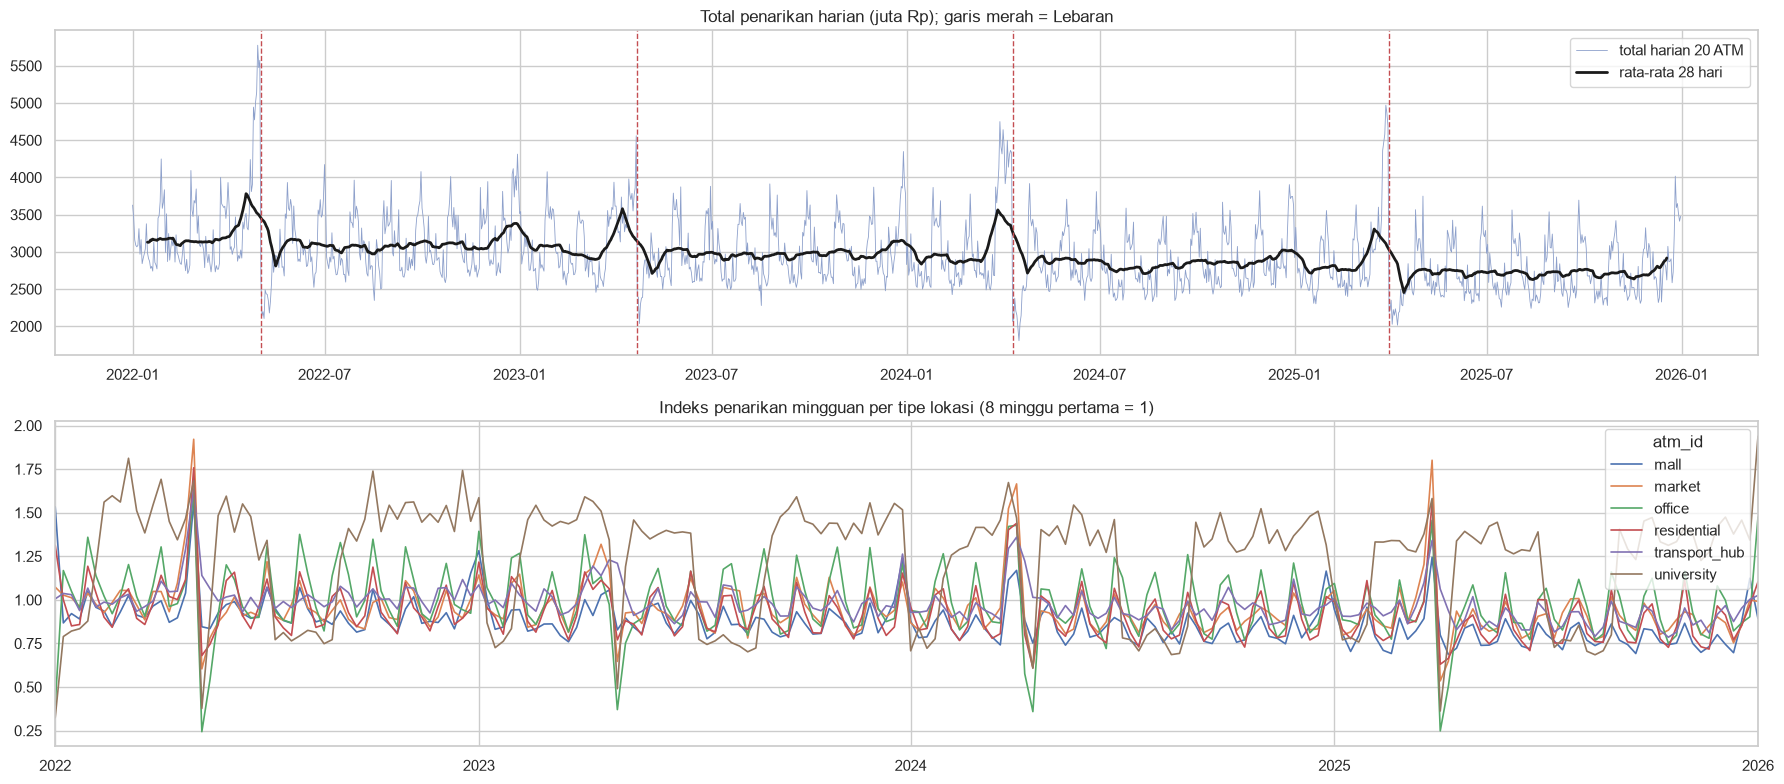

Total per tahun (juta Rp): {2022: 1151387.0, 2023: 1100298.0, 2024: 1063528.0, 2025: 1010835.0} | perubahan: {2023: -4.4, 2024: -3.3, 2025: -5.0}


In [3]:
total = np.expm1(W).sum(axis=1)
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
axes[0].plot(total.index, total, lw=0.6, color="#8DA0CB", label="total harian 20 ATM")
axes[0].plot(total.index, total.rolling(28, center=True).mean(), color="k", lw=2, label="rata-rata 28 hari")
for d in LEBARAN[LEBARAN <= total.index.max()]:
    axes[0].axvline(d, color="#C44E52", ls="--", lw=1)
axes[0].set_title("Total penarikan harian (juta Rp); garis merah = Lebaran")
axes[0].legend()
by_type = np.expm1(W).T.groupby(ATM_TYPES).sum().T.resample("W").mean()
(by_type / by_type.iloc[:8].mean()).plot(ax=axes[1], lw=1.2)
axes[1].set_title("Indeks penarikan mingguan per tipe lokasi (8 minggu pertama = 1)")
plt.tight_layout()
plt.show()

yearly = np.expm1(W).groupby(W.index.year).sum().sum(axis=1)
print("Total per tahun (juta Rp):", yearly.round(0).to_dict(), "| perubahan:", (yearly.pct_change() * 100).round(1).dropna().to_dict())

> **🔄 Alur data: Pola Mingguan, Gajian & Lebaran**
>
> - **Input:** `tx`, `master`, kalender.
> - **Proses:**
>   1. `long` = data panjang + kalender + `rel` (penarikan ÷ median bulanan ATM itu, sehingga ATM besar & kecil sebanding).
>   2. Heatmap median `rel` per tipe × hari, profil per tanggal (hari normal saja), dan *event study* −30…+21 hari terhadap Lebaran.
> - **Output:** 3 grafik. Kantor: akhir pekan ±0,4×; mall: Sabtu–Minggu ±1,35×. Lonjakan gajian tgl 25–2. Event study: naik bertahap 3 minggu sebelum Lebaran, lalu anjlok di H0.
> - **Berikutnya:** Dekomposisi satu ATM.

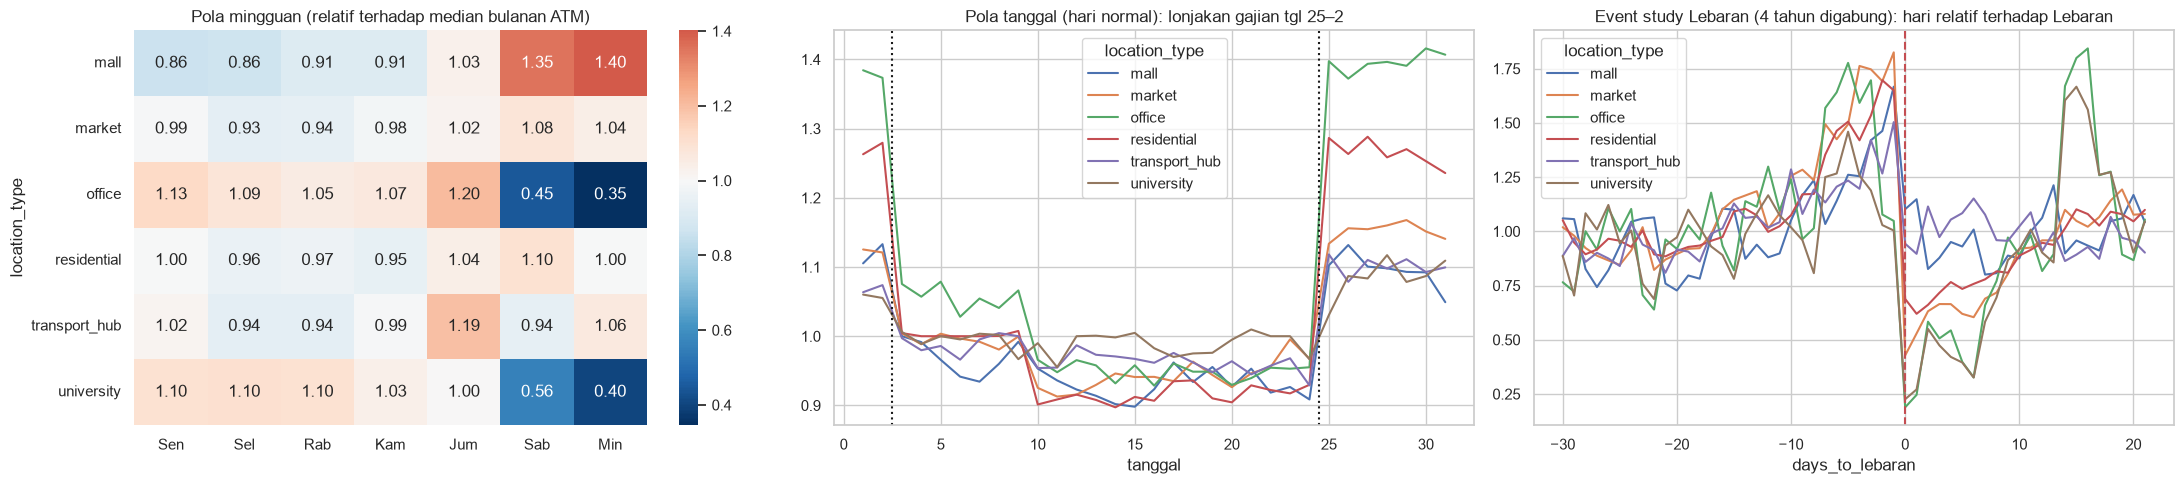

In [4]:
long = tx.merge(master[["atm_id", "location_type"]], on="atm_id").merge(calendar_frame(W.index), on="date")
long["log_y"] = np.log(long["withdrawal"])
long["rel"] = long["withdrawal"] / long.groupby(["atm_id", long["date"].dt.to_period("M")])["withdrawal"].transform("median")

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
dow_names = ["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"]
dow_prof = long.pivot_table(index="location_type", columns="dow", values="rel", aggfunc="median")
dow_prof.columns = dow_names
sns.heatmap(dow_prof, annot=True, fmt=".2f", cmap="RdBu_r", center=1, ax=axes[0])
axes[0].set_title("Pola mingguan (relatif terhadap median bulanan ATM)")
dom_prof = long[(long["lebaran_bin"] == "normal") & (long["is_holiday"] == 0)].pivot_table(index="dom", columns="location_type", values="rel", aggfunc="median")
dom_prof.plot(ax=axes[1], lw=1.5)
for x in (2.5, 24.5):
    axes[1].axvline(x, color="k", ls=":")
axes[1].set_title("Pola tanggal (hari normal): lonjakan gajian tgl 25–2")
axes[1].set_xlabel("tanggal")
ev = long[long["days_to_lebaran"].between(-30, 21)].pivot_table(index="days_to_lebaran", columns="location_type", values="rel", aggfunc="median")
ev.plot(ax=axes[2], lw=1.5)
axes[2].axvline(0, color="#C44E52", ls="--")
axes[2].set_title("Event study Lebaran (4 tahun digabung): hari relatif terhadap Lebaran")
plt.tight_layout()
plt.show()

> **🔄 Alur data: Dekomposisi STL**
>
> - **Input:** `W[example_atm]` (ATM residential pertama).
> - **Proses:**
>   1. STL (periode 7, robust) → tren + musiman + residual.
>   2. Kekuatan musiman & tren = 1 − var(residual) / var(komponen + residual).
> - **Output:** Grafik STL. Kekuatan musiman mingguan **0,28**, tren **0,66**. Residual terbesar 0,85 (log) di sekitar Lebaran 2022 (29 Apr 2022).
> - **Berikutnya:** Uji statistik time series.

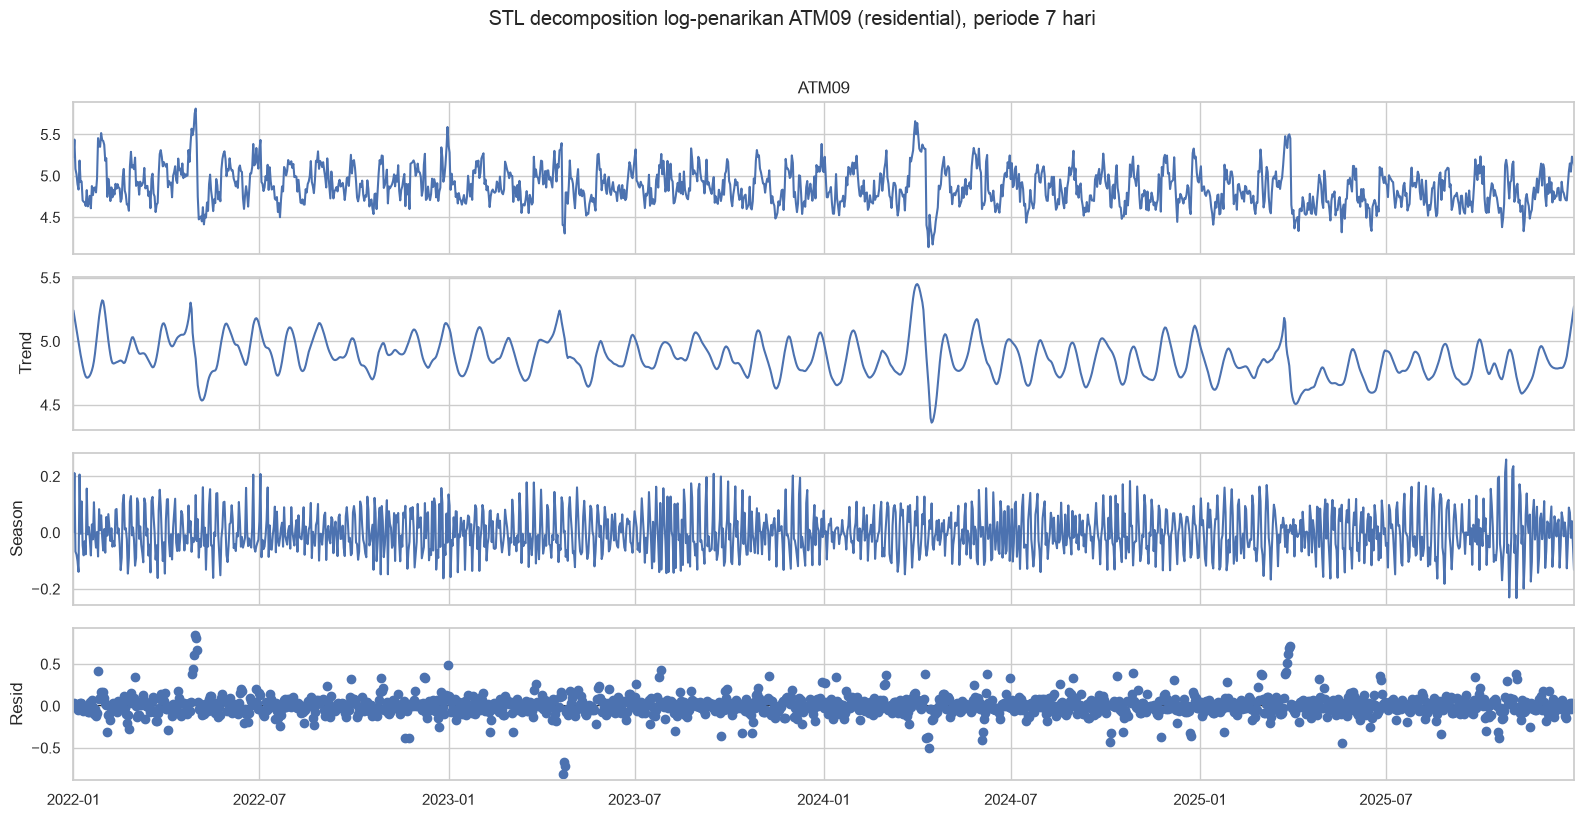

Kekuatan musiman mingguan = 0.28 | kekuatan tren = 0.66 (0 = tidak ada, 1 = sangat kuat)
Residual STL masih memuat lonjakan besar di sekitar Lebaran: maks |resid| = 0.85 pada 2022-04-29


In [5]:
example_atm = master.loc[master["location_type"] == "residential", "atm_id"].iloc[0]
stl = STL(W[example_atm], period=7, robust=True).fit()
strength_seasonal = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
strength_trend = max(0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
fig = stl.plot()
fig.set_size_inches(16, 8)
fig.suptitle(f"STL decomposition log-penarikan {example_atm} (residential), periode 7 hari", y=1.02)
plt.tight_layout()
plt.show()
print(f"Kekuatan musiman mingguan = {strength_seasonal:.2f} | kekuatan tren = {strength_trend:.2f} (0 = tidak ada, 1 = sangat kuat)")
print(f"Residual STL masih memuat lonjakan besar di sekitar Lebaran: maks |resid| = {stl.resid.abs().max():.2f} pada {stl.resid.abs().idxmax().date()}")

### Insight EDA

- **Tren turun**: total penarikan 20 ATM turun dari Rp 1,15 T (2022) ke Rp 1,01 T (2025), sekitar −3% s.d. −5% per tahun, karena pembayaran beralih ke digital (QRIS, transfer). Model harus bisa mengikuti level yang terus turun.
- **Pola mingguan sangat berbeda per lokasi**: ATM kantor hanya ±0,4× di akhir pekan, mall naik ke ±1,35× di Sabtu–Minggu, kampus sepi di akhir pekan, sedangkan perumahan & pasar relatif datar. Satu pola mingguan untuk semua ATM tidak cukup.
- **Gajian**: penarikan melonjak pada tanggal 25 s.d. 2, paling kuat di ATM kantor & perumahan.
- **Lebaran adalah peristiwa terbesar dalam setahun**: penarikan naik bertahap 3 minggu sebelumnya (THR + mudik), memuncak di H-7…H-1 (pasar sampai ±2×), lalu **anjlok** saat Lebaran (kantor & kampus ±0,3×), dan pulih perlahan dalam 1–2 minggu. Tanggal Lebaran maju ±11 hari setiap tahun, sehingga pola musiman tahunan biasa tidak bisa menangkapnya.
- **STL** pada satu ATM perumahan: kekuatan musiman mingguan 0,28 dan tren 0,66. Residual terbesar (0,85 dalam log, ≈ ×2,3) terjadi di sekitar Lebaran. Artinya, komponen tren + musiman mingguan saja **tidak** menjelaskan lonjakan Lebaran, dan inilah titik lemah model klasik seperti Holt-Winters.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Temuan utama:**
- **Tren menurun**: penarikan turun sekitar **3–5% per tahun** karena peralihan ke pembayaran digital.
- **Setiap lokasi punya pola sendiri:**
  - **Perkantoran**: ramai di hari kerja, sangat sepi di akhir pekan (±40% dari biasanya).
  - **Mal**: paling ramai di akhir pekan.
  - **Kampus**: sepi di akhir pekan dan saat libur semester.
  - **Perumahan & pasar**: relatif stabil sepanjang minggu.
- **Gajian**: penarikan melonjak, terutama di perkantoran dan perumahan.
- **Lebaran adalah peristiwa terbesar dalam setahun:**
  - naik bertahap mulai 3 minggu sebelumnya,
  - **memuncak** seminggu sebelum Lebaran (ATM pasar bisa **2× lipat**),
  - **anjlok** saat Lebaran,
  - kembali normal dalam 1–2 minggu.
- **Tanggal Lebaran maju ±11 hari setiap tahun**, sehingga pola musiman tahunan biasa tidak cukup. Model perlu informasi kalender Lebaran secara eksplisit.

## 4. Uji Statistik Time Series

| Uji | Pertanyaan | H0 |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | Apakah deret stasioner? | ada *unit root* (tidak stasioner) |
| **KPSS** | idem, dari arah sebaliknya | deret stasioner (di sekitar tren) |
| **Tren** (regresi log ~ waktu, SE Newey-West) | Apakah ada tren naik/turun nyata? | slope = 0 |
| **Kruskal-Wallis + ε²** | Apakah hari dalam seminggu berpengaruh (per tipe lokasi)? | median sama untuk semua hari |
| **Mann-Whitney + r** | Apakah gajian & pra-Lebaran berbeda dari hari biasa? | distribusi sama |
| **ACF/PACF** | Lag mana yang informatif? | — |

ADF dan KPSS dipakai berpasangan. Jika ADF menolak H0 **dan** KPSS tidak menolak H0, deret stasioner. Jika hasilnya bertentangan, deret “stasioner di sekitar tren/musim” dan perlu dimodelkan tren/musimannya.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Pola yang terlihat di grafik perlu **dibuktikan secara statistik**:
- **Stasioneritas (ADF & KPSS):** apakah penarikan bergerak stabil di sekitar tren dan polanya, atau berubah tanpa arah? Hasilnya, **semua 20 ATM stabil di sekitar tren**, sehingga dapat diramal dengan baik ✅.
- **Tren:** **12 dari 20 ATM** menurun secara signifikan, rata-rata sekitar **−3,4% per tahun**.
- **Efek hari:** sangat kuat di perkantoran, mal, dan kampus; kecil di perumahan dan pasar.
- **Efek gajian:** ATM perkantoran **+49%**, sedangkan ATM kampus hampir tidak berubah (+2%), karena mahasiswa umumnya tidak menerima gaji tanggal 25.
- **Menjelang Lebaran:** ATM pasar **+85%**, perumahan +68%.
- **Autokorelasi (ACF):** penarikan hari ini **mirip dengan kemarin** dan **mirip dengan hari yang sama minggu lalu**.

**p-value semuanya sangat kecil** → pola-pola ini **nyata**, bukan kebetulan.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Pola yang terlihat di grafik perlu **dibuktikan** dengan uji statistik:
- **Stasioner (ADF & KPSS):** apakah penarikan "tenang" di sekitar tren dan polanya, atau melayang tanpa arah? Hasilnya, **semua 20 ATM tenang di sekitar tren**, jadi bisa diramal dengan baik.
- **Tren:** **12 dari 20 ATM** turun secara nyata, rata-rata **−3,4% per tahun**.
- **Efek hari:** sangat kuat di kantor, mall, dan kampus, tetapi kecil di perumahan dan pasar.
- **Efek gajian:** ATM kantor **+49%** di masa gajian, sedangkan kampus hampir tidak berubah (+2%), karena mahasiswa tidak menerima gaji tanggal 25.
- **Menjelang Lebaran:** ATM pasar **+85%**, perumahan +68%.
- **ACF:** penarikan hari ini **mirip dengan kemarin** dan **mirip dengan hari yang sama minggu lalu**. Karena itu model diberi informasi penarikan kemarin dan minggu lalu.

**Cara membaca:** semua p-value di sini sangat kecil, jadi pola-pola tersebut **nyata**, bukan kebetulan.

> **🔄 Alur data: Stasioneritas & Tren per ATM**
>
> - **Input:** `W` (20 deret log).
> - **Proses:**
>   1. ADF (H0: unit root) dan KPSS dengan tren (H0: stasioner).
>   2. Regresi log ~ waktu dengan SE Newey-West (lag 14) → tren tahunan + p-value (Holm).
> - **Output:** `ts_tests`. Semua 20 deret stasioner di sekitar tren (ADF p < 0,001; KPSS p ≥ 0,10). **12 ATM** tren turun signifikan (Holm), median **−3,4%/tahun**.
> - **Berikutnya:** Uji efek kalender.

In [6]:
rows = []
for atm in W.columns:
    s = W[atm]
    adf_p = adfuller(s, autolag="AIC", result_object=False)[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)  # p-value KPSS dibatasi tabel 0,01–0,10
        warnings.simplefilter("ignore", FutureWarning)         # perubahan format output di statsmodels mendatang
        kpss_p = kpss(s, regression="ct", nlags="auto")[1]
    t = np.arange(len(s)) / 365.25
    ols = sm.OLS(s.to_numpy(), sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 14})
    rows.append({"atm_id": atm, "location_type": ATM_TYPES[atm], "adf_p": adf_p, "kpss_p": kpss_p,
                 "tren_per_tahun": np.exp(ols.params[1]) - 1, "tren_p": ols.pvalues[1]})
ts_tests = pd.DataFrame(rows).set_index("atm_id")
ts_tests["tren_p_holm"] = holm_correction(ts_tests["tren_p"])
ts_tests["kesimpulan_stasioneritas"] = np.select(
    [(ts_tests["adf_p"] < 0.05) & (ts_tests["kpss_p"] >= 0.05), (ts_tests["adf_p"] < 0.05) & (ts_tests["kpss_p"] < 0.05)],
    ["stasioner (di sekitar tren)", "stasioner + perubahan level/musim"], default="tidak stasioner")
with pd.option_context("display.float_format", "{:.4f}".format):
    display(ts_tests)
print("Ringkasan:", ts_tests["kesimpulan_stasioneritas"].value_counts().to_dict(),
      f"| tren signifikan turun (Holm): {((ts_tests['tren_p_holm'] < 0.05) & (ts_tests['tren_per_tahun'] < 0)).sum()} dari {len(ts_tests)} ATM,",
      f"median tren {ts_tests['tren_per_tahun'].median():+.2%}/tahun")

,location_type,adf_p,kpss_p,tren_per_tahun,tren_p,tren_p_holm,kesimpulan_stasioneritas
atm_id,,,,,,,
ATM01,mall,0.0000,0.1000,-0.0556,0.0000,0.0000,stasioner (di sekitar tren)
ATM02,mall,0.0000,0.1000,-0.0242,0.0013,0.0121,stasioner (di sekitar tren)
ATM03,mall,0.0000,0.1000,-0.0694,0.0000,0.0000,stasioner (di sekitar tren)
ATM04,mall,0.0000,0.1000,-0.0528,0.0000,0.0000,stasioner (di sekitar tren)
ATM05,office,0.0000,0.1000,-0.0403,0.0071,0.0570,stasioner (di sekitar tren)
ATM06,office,0.0000,0.1000,-0.0307,0.0380,0.1901,stasioner (di sekitar tren)
ATM07,office,0.0000,0.1000,-0.0298,0.0478,0.1910,stasioner (di sekitar tren)
ATM08,office,0.0000,0.1000,-0.0327,0.0236,0.1418,stasioner (di sekitar tren)
ATM09,residential,0.0000,0.1000,-0.0435,0.0000,0.0001,stasioner (di sekitar tren)


Ringkasan: {'stasioner (di sekitar tren)': 20} | tren signifikan turun (Holm): 12 dari 20 ATM, median tren -3.39%/tahun


> **🔄 Alur data: Uji Efek Kalender & ACF**
>
> - **Input:** `long`.
> - **Proses:**
>   1. Per tipe lokasi, hari normal: residual = log penarikan − rata-rata ATM itu; Kruskal-Wallis + ε² untuk 7 hari dalam seminggu.
>   2. Mann-Whitney: jendela gajian vs tengah bulan, dan H-7…H-1 Lebaran vs hari normal (Holm).
>   3. ACF & PACF setelah differencing 7 hari.
> - **Output:** `cal_tests` + ACF/PACF. Efek hari: ε² kantor **0,63**, mall 0,58, kampus 0,54, transport 0,25, pasar 0,11, perumahan 0,07. Gajian vs tengah bulan: kantor +49% … kampus +2%. Pra-Lebaran vs normal: pasar **+85%**, perumahan +68%. Semua p_holm < 0,001.
> - **Berikutnya:** Rancang validasi.

,dow_eps2,dow_p_holm,gajian_vs_tengah_%,gajian_r,gajian_p_holm,pra_lebaran_vs_normal_%,lebaran_p_holm
location_type,,,,,,,
mall,0.5791,0.0000,0.2106,0.4121,0.0000,0.4362,0.0000
market,0.1079,0.0000,0.2249,0.6811,0.0000,0.8453,0.0000
office,0.6277,0.0000,0.4933,0.5556,0.0000,0.4072,0.0000
residential,0.0673,0.0000,0.3959,0.9053,0.0000,0.6797,0.0000
transport_hub,0.2525,0.0000,0.1443,0.4616,0.0000,0.4500,0.0000
university,0.5375,0.0000,0.0190,0.1260,0.0000,0.3985,0.0000


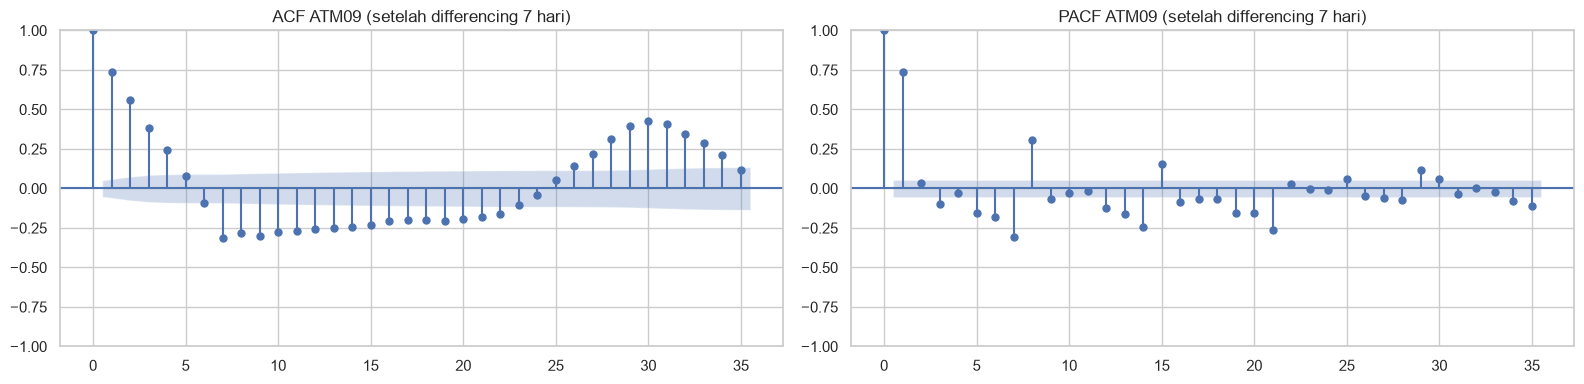

In [7]:
rows = []
normal = long[(long["lebaran_bin"] == "normal") & (long["is_holiday"] == 0)]
for loc, g in long.groupby("location_type"):
    n = normal[normal["location_type"] == loc]
    # residual = log penarikan − rata-rata ATM itu (di SEMUA hari), baru dikelompokkan per hari
    resid = n["log_y"] - n.groupby("atm_id")["log_y"].transform("mean")
    h, p = stats.kruskal(*[resid[n["dow"] == d] for d in range(7)])
    eps2 = h / ((len(n) ** 2 - 1) / (len(n) + 1))
    pay, mid = resid[n["dom_bin"].isin(["gajian_25-31", "gajian_1-2"])], resid[n["dom_bin"] == "tengah_10-19"]
    u = stats.mannwhitneyu(pay, mid)
    g_res = g["log_y"] - g.groupby("atm_id")["log_y"].transform("mean")
    pre, norm = g_res[g["lebaran_bin"] == "H-7_s.d._H-1"], g_res[(g["lebaran_bin"] == "normal") & (g["is_holiday"] == 0)]
    u2 = stats.mannwhitneyu(pre, norm)
    rows.append({"location_type": loc, "dow_eps2": eps2, "dow_p": p,
                 "gajian_vs_tengah_%": np.exp(pay.median() - mid.median()) - 1, "gajian_p": u.pvalue, "gajian_r": 2 * u.statistic / (len(pay) * len(mid)) - 1,
                 "pra_lebaran_vs_normal_%": np.exp(pre.median() - norm.median()) - 1, "lebaran_p": u2.pvalue})
cal_tests = pd.DataFrame(rows).set_index("location_type")
for col in ["dow_p", "gajian_p", "lebaran_p"]:
    cal_tests[col.replace("_p", "_p_holm")] = holm_correction(cal_tests[col])
with pd.option_context("display.float_format", "{:.4f}".format):
    display(cal_tests[["dow_eps2", "dow_p_holm", "gajian_vs_tengah_%", "gajian_r", "gajian_p_holm", "pra_lebaran_vs_normal_%", "lebaran_p_holm"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(W[example_atm].diff(7).dropna(), lags=35, ax=axes[0], title=f"ACF {example_atm} (setelah differencing 7 hari)")
plot_pacf(W[example_atm].diff(7).dropna(), lags=35, ax=axes[1], method="ywm", title=f"PACF {example_atm} (setelah differencing 7 hari)")
plt.tight_layout()
plt.show()

### Interpretasi Uji Statistik

**Stasioneritas & tren**
- Semua 20 deret **stasioner di sekitar tren** (ADF menolak unit root, p < 0,001; KPSS tidak menolak stasioneritas-tren, p ≥ 0,10). Model tidak perlu differencing tambahan, cukup menangani level, tren, dan musim.
- **12 dari 20 ATM** punya tren turun yang signifikan (Holm, SE Newey-West), dengan median **−3,4% per tahun**. Delapan sisanya juga cenderung turun, tetapi tidak signifikan setelah koreksi.

**Efek kalender (semua signifikan, p_holm < 0,001)**
- **Hari dalam seminggu**: efek **besar** di kantor (ε² = 0,63), mall (0,58), kampus (0,54), dan sedang di transport hub (0,25). Di perumahan (0,07) dan pasar (0,11) efeknya kecil. Ini konsisten dengan heatmap di Bagian 3.
- **Gajian vs tengah bulan**: kantor **+49%**, perumahan +40%, pasar +22%, mall +21%, transport hub +14%, kampus hanya +2% (mahasiswa tidak menerima gaji tanggal 25).
- **Pra-Lebaran (H-7…H-1) vs hari normal**: pasar **+85%**, perumahan +68%, transport hub/mall/kantor/kampus +40–45%.
- **ACF/PACF** setelah differencing 7 hari menunjukkan korelasi signifikan di lag 1 dan lag kelipatan 7. Ini dasar pemilihan lag 1, 2, 3, 7, 14, 21, 28 di feature engineering.

**Kesimpulan untuk pemodelan:** ada tiga sumber variasi besar yang **berbeda per tipe lokasi** (hari, gajian, Lebaran) dan tidak periodik sederhana. Model perlu fitur kalender eksplisit, dan perlu bisa belajar interaksi “efek kalender × tipe lokasi”.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Ringkasnya:**
- Data penarikan **stabil di sekitar tren** sehingga dapat diramal.
- Ada **tren menurun** yang perlu diikuti model.
- Ada **tiga sumber variasi besar**, yaitu **hari, gajian, dan Lebaran**, dan pengaruhnya **berbeda di setiap tipe lokasi**.
- Penarikan hari ini **berkaitan erat** dengan kemarin dan dengan minggu lalu.

Implikasinya, model perlu diberi **informasi kalender**, **tipe lokasi**, dan **data penarikan hari-hari sebelumnya**.

## 5. Desain Validasi: Rolling-Origin (Time-Series Cross-Validation)

Data deret waktu **tidak boleh di-split acak**. Split acak berarti model “melihat” hari esok saat dilatih untuk meramal hari ini. Validasi yang benar meniru pemakaian nyata:

```
origin 1:  [========== latih ==========] → ramal 14 hari
origin 2:  [============ latih ============] → ramal 14 hari
origin 3:  [============== latih ==============] → ramal 14 hari     (expanding window)
```

| Periode | Peran | Origin |
|---|---|---|
| 2022 | riwayat awal (tidak dievaluasi) | — |
| **2023** | **tuning** hyperparameter | 8 origin, tiap 42 hari |
| **2024** | **pemilihan model** + kalibrasi interval | 26 origin, tiap 14 hari (seluruh tahun tercakup tanpa tumpang tindih) |
| **2025** | **uji akhir** (backtest out-of-time), dikunci | 26 origin, tiap 14 hari |

Di setiap origin, **semua** model dilatih ulang dengan data ≤ origin, lalu meramal 14 hari. Total uji akhir: 26 × 14 hari × 20 ATM = **7.280 ramalan per model**.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Bagaimana menguji model peramalan dengan jujur?**

Data deret waktu **tidak boleh diacak**. Jika diacak, model bisa "melihat" data esok hari saat belajar meramal hari ini, sehingga hasilnya terlalu optimis.

**Rolling-origin** meniru pemakaian nyata:
1. Tentukan tanggal "hari ini". Model hanya boleh memakai data **sebelum** tanggal tersebut.
2. Ramal 14 hari ke depan.
3. Bandingkan dengan kenyataan.
4. Maju 14 hari, lalu ulangi.

Ilustrasinya seperti menguji peramal cuaca dengan memutar ulang tahun lalu, hari demi hari, tanpa memberi tahu cuaca keesokan harinya.

**Pembagian periode:**
| Periode | Fungsi |
|---|---|
| 2022 | data awal untuk belajar |
| 2023 | **tuning** pengaturan model |
| 2024 | **memilih model** terbaik |
| 2025 | **ujian akhir**: 7.280 ramalan per model |

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Cara menguji ramalan dengan jujur.** Pada data waktu, kita **tidak boleh** mengacak data, karena itu sama saja dengan "mengintip masa depan".

**Rolling-origin** meniru pemakaian nyata:
1. Berdiri di tanggal tertentu, misalnya 1 Maret 2024. Model hanya boleh melihat data **sebelum** tanggal itu.
2. Ramal 14 hari ke depan.
3. Bandingkan dengan kenyataan.
4. Maju 14 hari, lalu ulangi.

**Pembagian tahun:**
- **2023:** untuk menyetel model (seperti latihan).
- **2024:** untuk memilih model terbaik (seperti ujian coba).
- **2025:** **disegel** untuk ujian akhir. Total **7.280 ramalan** per model (26 kali × 14 hari × 20 ATM).

**Analogi:** menguji peramal cuaca dengan memutar ulang tahun lalu, hari demi hari, tanpa memberi tahu dia apa yang terjadi besok.

> **🔄 Alur data: Origin Rolling-Origin**
>
> - **Input:** Rentang tanggal `W`.
> - **Proses:**
>   1. 8 origin tuning (2023), 26 origin seleksi (2024), 26 origin uji akhir (2025), tiap 14 hari.
>   2. `assert`: jendela 2024 tidak masuk 2025, dan jendela 2025 tidak melewati data.
> - **Output:** `TUNE_ORIGINS` (8: 15 Jan – 5 Nov 2023), `SELECT_ORIGINS` (26: 31 Des 2023 – 15 Des 2024), `TEST_ORIGINS` (26: 29 Des 2024 – 14 Des 2025). Lebaran 2025 masuk jendela origin 23 Mar 2025.
> - **Berikutnya:** Bangun fitur.

In [8]:
TUNE_ORIGINS = pd.date_range("2023-01-15", periods=8, freq="42D")
SELECT_ORIGINS = pd.date_range("2023-12-31", periods=26, freq=f"{STEP}D")
TEST_ORIGINS = pd.date_range("2024-12-29", periods=26, freq=f"{STEP}D")
for name, o in [("tuning", TUNE_ORIGINS), ("seleksi", SELECT_ORIGINS), ("uji akhir", TEST_ORIGINS)]:
    last_day = o[-1] + pd.Timedelta(days=HORIZON)
    print(f"{name:<9}: {len(o)} origin, {o[0].date()} … {o[-1].date()} → ramalan s.d. {last_day.date()}")
assert TEST_ORIGINS[-1] + pd.Timedelta(days=HORIZON) <= W.index.max()
assert SELECT_ORIGINS[-1] + pd.Timedelta(days=HORIZON) < pd.Timestamp("2025-01-01")
lebaran_2025 = pd.Timestamp("2025-03-31")
covered = [o for o in TEST_ORIGINS if o < lebaran_2025 <= o + pd.Timedelta(days=HORIZON)]
print(f"Lebaran 2025 ({lebaran_2025.date()}) masuk jendela origin {covered[0].date()}; lonjakan pra-Lebaran tercakup origin sebelumnya")

tuning   : 8 origin, 2023-01-15 … 2023-11-05 → ramalan s.d. 2023-11-19
seleksi  : 26 origin, 2023-12-31 … 2024-12-15 → ramalan s.d. 2024-12-29
uji akhir: 26 origin, 2024-12-29 … 2025-12-14 → ramalan s.d. 2025-12-28
Lebaran 2025 (2025-03-31) masuk jendela origin 2025-03-23; lonjakan pra-Lebaran tercakup origin sebelumnya


## 6. Feature Engineering: Lag, Rolling, Binning Kalender + One-Hot

Fitur untuk tanggal **t** (semua dihitung dari log1p penarikan; lag/rolling hanya memakai data ≤ t−1):

| Kelompok | Fitur | Perlakuan |
|---|---|---|
| Lag | `lag_1`, `lag_2`, `lag_3`, `lag_7`, `lag_14`, `lag_21`, `lag_28` | angka |
| Rolling | rata-rata 7 & 28 hari, std 7 hari, rata-rata hari yang sama 4 minggu terakhir | angka |
| Hari & bulan | `dow` (Senin–Minggu), `month` | **one-hot** |
| Jendela gajian | tanggal → **bin**: gajian_1-2, awal_3-9, tengah_10-19, menjelang_20-24, gajian_25-31 | **binning → one-hot** |
| Fase Lebaran | jarak ke Lebaran → **bin**: H-21…H-15, H-14…H-8, H-7…H-1, H0…H+3, H+4…H+7, H+8…H+14, normal | **binning → one-hot** |
| Libur & musim | libur nasional, H-1/H+1 libur, puncak Desember, libur semester | 0/1 |
| ATM | tipe lokasi | **one-hot** |

**Kenapa binning?** Efek gajian tidak linear terhadap tanggal: lonjakan tgl 25 s.d. 2 lalu turun. Efek Lebaran juga berupa fase (THR, mudik, arus balik). Kalau dibiarkan sebagai angka, model butuh banyak percabangan untuk menemukan ambang yang sama. Binning dengan batas dari pengetahuan bisnis langsung memberi model “bahasa” yang tepat.

Fitur dibangun oleh **satu** fungsi (`src/features.py::build_features`) yang dipakai untuk training, forecast rekursif, dan API.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Model membutuhkan **informasi pendukung** (fitur) yang tepat:
- **Penarikan hari-hari sebelumnya**: kemarin, 2 hari lalu, seminggu lalu, dan seterusnya.
- **Rata-rata terkini**: rata-rata 7 dan 28 hari terakhir.
- **Hari dan bulan**.
- **Periode gajian**: tanggal dikelompokkan menjadi "masa gajian (25–31)", "awal bulan (3–9)", "tengah bulan (10–19)", dan seterusnya.
- **Fase Lebaran**: "3 minggu sebelum", "seminggu sebelum", "hari Lebaran s.d. H+3", "seminggu sesudah", dan seterusnya.
- **Hari libur** dan musim liburan.
- **Tipe lokasi ATM**.

**Kenapa tanggal dikelompokkan (binning)?** Efek gajian dan Lebaran berupa **periode**, bukan garis lurus. Tanggal 26 dan 29 sama-sama masa gajian. Dengan pengelompokan, model langsung mendapat informasi dalam "bahasa bisnis".

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Model perlu diberi "petunjuk" yang tepat. Petunjuk yang kita berikan:
- **Penarikan beberapa hari terakhir:** kemarin, 2 hari lalu, seminggu lalu, dst.
- **Rata-rata terakhir:** rata-rata 7 dan 28 hari terakhir.
- **Hari dan bulan.**
- **Periode gajian:** tanggal diubah menjadi kelompok, misalnya "gajian (25–31)", "awal bulan (3–9)", "tengah bulan (10–19)".
- **Fase Lebaran:** jarak ke Lebaran diubah menjadi kelompok, misalnya "3 minggu sebelum", "seminggu sebelum", "hari Lebaran s.d. H+3", "seminggu sesudah".
- **Libur nasional dan musim liburan.**
- **Tipe lokasi ATM.**

**Kenapa tanggal dikelompokkan (binning)?** Efek gajian dan Lebaran berupa **periode**, bukan garis lurus. Tanggal 26 dan 29 sama-sama "masa gajian". Dengan pengelompokan, model langsung "paham bahasa bisnis".

> **🔄 Alur data: Matriks Fitur**
>
> - **Input:** `W` s.d. 2024.
> - **Proses:**
>   1. `training_frame`: `build_features` untuk setiap tanggal yang punya 28 hari riwayat → lag, rolling, kalender, binning, one-hot; target = log1p hari itu.
>   2. Contoh satu baris: ATM residential pada H-5 Lebaran 2024.
> - **Output:** `X_demo` **21.360 × 53 fitur** (lag 7, rolling 4, flag 5, one-hot: bulan 12, hari 7, fase Lebaran 7, tipe lokasi 6, jendela gajian 5). Contoh ATM09 pada 5 Apr 2024: `lebaran_bin_H-7_s.d._H-1` = 1, `dow_4` (Jumat) = 1, `lag_1` = 5,30 (log), jauh di atas `lag_28` = 4,79 karena sudah masuk masa pra-Lebaran.
> - **Berikutnya:** Buktikan tidak ada kebocoran.

In [9]:
X_demo, y_demo = training_frame(W.loc[:"2024-12-31"], ATM_TYPES)
print(f"Matriks training s.d. 2024: {X_demo.shape[0]:,} baris × {len(FEATURE_COLUMNS)} fitur")
groups = pd.Series(FEATURE_COLUMNS).str.extract(r"^(lag|roll|same|is|dow|month|dom_bin|lebaran_bin|location_type)")[0].value_counts()
print(groups.to_string())

row = X_demo[(X_demo["atm_id"] == example_atm) & (X_demo["date"] == "2024-04-05")].iloc[0]
print(f"\nContoh: {example_atm} pada 2024-04-05 (H-5 Lebaran, hari Jumat) — target log1p = {y_demo.loc[row.name]:.3f}")
display(row[FEATURE_COLUMNS][row[FEATURE_COLUMNS] != 0].to_frame("nilai").T.round(3))

Matriks training s.d. 2024: 21,360 baris × 53 fitur
0
month            12
lag               7
dow               7
lebaran_bin       7
location_type     6
is                5
dom_bin           5
roll              3
same              1

Contoh: ATM09 pada 2024-04-05 (H-5 Lebaran, hari Jumat) — target log1p = 5.291


,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_mean_28,roll_std_7,same_dow_mean_4,dow_4,month_4,dom_bin_awal_3-9,lebaran_bin_H-7_s.d._H-1,location_type_residential
nilai,5.301014,5.329525,5.480681,5.515362,4.802134,4.835567,4.788991,5.489631,5.026694,0.137309,4.985514,1.0,1.0,1.0,1.0,1.0


> **🔄 Alur data: Uji Kebocoran**
>
> - **Input:** `W` dan salinannya yang dimodifikasi.
> - **Proses:**
>   1. Nilai aktual 12 Jun 2024 ditambah +5 (log), lalu fitur tanggal itu dibandingkan dengan versi asli (harus sama).
>   2. `lag_1` tanggal berikutnya harus sama dengan nilai yang dimodifikasi.
> - **Output:** ✅ Lulus: fitur hari t identik walaupun nilai aktual hari t diubah, dan `lag_1` hari t+1 = nilai hari t.
> - **Berikutnya:** Definisikan kandidat.

In [10]:
# Uji kebocoran: mengubah nilai aktual pada hari t TIDAK boleh mengubah fitur hari t
W_leak = W.copy()
probe = pd.Timestamp("2024-06-12")
W_leak.loc[probe] = W_leak.loc[probe] + 5.0
f_orig = build_features(W, [probe], ATM_TYPES)[FEATURE_COLUMNS]
f_leak = build_features(W_leak, [probe], ATM_TYPES)[FEATURE_COLUMNS]
f_next = build_features(W_leak, [probe + pd.Timedelta(days=1)], ATM_TYPES)[["lag_1"]]
assert np.allclose(f_orig.to_numpy(), f_leak.to_numpy()), "BOCOR: fitur hari t berubah saat nilai hari t diubah"
assert np.allclose(f_next["lag_1"].to_numpy(), W_leak.loc[probe].to_numpy())
print("✅ Tidak ada kebocoran: fitur hari t hanya bergantung pada data ≤ t−1 (dan lag_1 hari t+1 = nilai hari t)")

✅ Tidak ada kebocoran: fitur hari t hanya bergantung pada data ≤ t−1 (dan lag_1 hari t+1 = nilai hari t)


## 7. Model

| | **Seasonal naive** (patokan) | **Holt-Winters / ETS** | **Gradient Boosting global** |
|---|---|---|---|
| Ide | ramalan = hari yang sama minggu lalu | level + tren teredam + musiman 7 hari, diperbarui eksponensial | pohon keputusan bertingkat pada fitur lag + kalender |
| Dilatih | — | **per ATM** (20 model), 2 tahun terakhir | **satu model untuk 20 ATM** (belajar pola bersama) |
| Kalender (gajian, Lebaran, libur) | ✗ | ✗ (hanya pola mingguan) | ✓ |
| Multi-step | langsung | langsung (rumus) | **rekursif**: ramalan hari ke-h menjadi lag untuk hari ke-h+1 |
| Kelebihan | sangat sederhana | klasik, interpretable, cepat | menangkap efek kalender & antar-ATM |

Pilihan *damped trend* ETS ditentukan per ATM dengan AIC. Seasonal naive juga menjadi penyebut **MASE**: MASE < 1 berarti lebih baik dari sekadar “sama dengan minggu lalu”.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Tiga metode dibandingkan:

| | **Seasonal naive** | **Holt-Winters (ETS)** | **Gradient Boosting** |
|---|---|---|---|
| Cara kerja | "Sama seperti minggu lalu" | Mengikuti level, tren, dan pola mingguan | Belajar dari penarikan sebelumnya dan kalender |
| Kalender gajian & Lebaran | ✗ | ✗ | ✓ |
| Peran | Patokan minimum | Metode klasik | Kandidat utama |

**Holt-Winters** ibarat peramal berpengalaman yang **tidak memegang kalender**: ia memahami pola mingguan, tetapi tidak tahu kapan gajian atau Lebaran. **Gradient Boosting** belajar dari **20 ATM sekaligus** dan memahami kalender.

**Ramalan berantai:** Gradient Boosting meramal besok, lalu hasilnya dipakai sebagai "penarikan kemarin" untuk meramal lusa, dan seterusnya sampai 14 hari.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Tiga metode diadu:**

| | **Seasonal naive** | **Holt-Winters (ETS)** | **Gradient Boosting** |
|---|---|---|---|
| Ide | "Sama seperti minggu lalu" | Mengikuti level, tren, dan pola mingguan | Belajar dari penarikan terakhir + kalender |
| Perumpamaan | Menebak cuaca besok = cuaca minggu lalu | Peramal berpengalaman yang **tidak punya kalender** | Peramal berpengalaman **yang punya kalender** dan mengenal semua ATM |
| Tahu gajian & Lebaran? | ✗ | ✗ | ✓ |
| Peran | Patokan minimum | Metode klasik | Kandidat utama |

**Gradient Boosting meramal "berantai":** ramalan untuk besok dipakai sebagai "penarikan kemarin" untuk meramal lusa, dan seterusnya sampai 14 hari.

> **🔄 Alur data: Grid Kandidat**
>
> - **Input:** Tidak ada data.
> - **Proses:**
>   1. 3 konfigurasi GBR (jumlah pohon, kedalaman, learning rate) dan 2 konfigurasi ETS (jendela latih 2 tahun / 1 tahun; damped dipilih per ATM via AIC).
>   2. Factory: fungsi yang membuat model baru (belum dilatih) untuk setiap origin.
> - **Output:** `GBR_GRID`, `ETS_GRID`, `TUNE_FACTORIES`.
> - **Berikutnya:** Tuning di 2023.

In [11]:
GBR_GRID = {
    "gbr_a": dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.7),
    "gbr_b": dict(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.7),
    "gbr_c": dict(n_estimators=600, max_depth=5, learning_rate=0.03, subsample=0.7),
}
ETS_GRID = {"ets_2y": dict(damped="auto", train_days=730), "ets_1y": dict(damped="auto", train_days=365)}


def gbr_factory(params):
    return lambda: GBRForecaster(ATM_TYPES, GradientBoostingRegressor(random_state=RANDOM_STATE, **params))


def ets_factory(params):
    return lambda: ETSForecaster(n_jobs=1, **params)


TUNE_FACTORIES = {**{k: gbr_factory(v) for k, v in GBR_GRID.items()}, **{k: ets_factory(v) for k, v in ETS_GRID.items()}}
print("Konfigurasi yang dituning:", list(TUNE_FACTORIES))

Konfigurasi yang dituning: ['gbr_a', 'gbr_b', 'gbr_c', 'ets_2y', 'ets_1y']


### 7.1 Model Statistik (Inferensi): Regresi Kalender per Tipe Lokasi + SARIMAX

Sebelum tuning dan backtesting (Bagian 8–11), efek kalender diukur secara **statistik** dengan intercept, koefisien, p-value, dan VIF. Dengan begitu kita tahu **berapa persen** gajian, Lebaran, atau akhir pekan mengubah penarikan, dan apakah efeknya **signifikan**.

**Model 1: regresi kalender per tipe lokasi** (data s.d. 31 Des 2024, tanpa menyentuh tahun uji 2025):

log(penarikan) = intercept + efek tetap ATM + hari + jendela gajian + fase Lebaran + bulan + libur + tren + error

- Dipisah **per tipe lokasi**, karena efek kalender berlawanan arah antar lokasi (akhir pekan: kantor turun, mall naik).
- **Efek tetap ATM** (dummy per ATM) menyerap perbedaan level antar ATM.
- Koefisien dummy → **efek % = e^koef − 1** terhadap acuan: Senin, tanggal 10–19, hari normal (bukan Lebaran), Januari, bukan libur.
- Data deret waktu panel: error **berautokorelasi** dan **berkorelasi antar ATM** di hari yang sama. SE biasa akan terlalu kecil, jadi dipakai **SE Driscoll-Kraay** (`hac-groupsum`, lag 7), yang tahan terhadap keduanya.

**Model 2: regresi dengan error ARIMA (SARIMAX)** untuk satu ATM: efek kalender di bagian regresi, sedangkan autokorelasi dimodelkan oleh komponen AR pada error. Ini model time series klasik dengan koefisien dan p-value. Dua spesifikasi dibandingkan dengan AIC.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Bagian ini menjawab: ***seberapa besar pengaruh kalender terhadap penarikan di setiap tipe lokasi?***

**Titik awal: "hari acuan" (intercept)**
- Senin biasa, tanggal 10–19, bulan Januari, bukan hari libur.
- Untuk ATM perkantoran: sekitar **Rp 147 jt per hari**.

**Pengaruh kalender dibanding hari acuan (koefisien):**

| Kondisi | Perkantoran | Kampus | Mal | Transportasi | Perumahan | Pasar |
|---|---|---|---|---|---|---|
| Minggu | **−70%** | −64% | **+64%** | +5% | −1% | +5% |
| Masa gajian (tgl 25–31) | **+51%** | +10% | +19% | +14% | +40% | +23% |
| Seminggu sebelum Lebaran | +29% | +12% | +39% | +42% | +50% | **+87%** |
| Hari Lebaran s.d. H+3 | **−69%** | −68% | −8% | **+14%** | −33% | −37% |

**Temuan penting: pengaruhnya bisa berlawanan arah.**
- Hari Minggu: ATM perkantoran **sepi**, ATM mal **ramai**.
- Saat Lebaran: ATM perkantoran **sepi**, ATM transportasi justru **naik** karena arus mudik.

Karena itu, **satu rumus untuk semua ATM tidak akan tepat**. Model perlu mengetahui tipe lokasi setiap ATM.

**Cara membaca:**
- **R²**: kalender menjelaskan **96%** variasi penarikan di perkantoran, tetapi hanya **66%** di pasar, karena pasar lebih acak.
- **Tanda bintang** di heatmap → pengaruhnya **signifikan**.
- **VIF**: "libur semester" ternyata identik dengan gabungan bulan Januari, Juli, dan Agustus, sehingga dikeluarkan karena informasinya sudah terwakili.
- **Driscoll-Kraay**: karena penarikan hari ini mirip kemarin, cara biasa menghitung p-value menjadi terlalu optimis. Metode ini mengoreksinya.

**Regresi dengan error ARIMA (satu ATM perumahan):** setelah efek kalender diperhitungkan, masih ada fluktuasi harian, dan sekitar **43%** fluktuasi hari ini **terbawa ke esok hari**. Inilah dasar pemakaian informasi **penarikan kemarin** dalam model.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Bagian ini menjawab: ***"Seberapa besar pengaruh kalender terhadap penarikan di setiap tipe lokasi?"***

**Cara kerja model ini dalam bahasa sederhana:**
1. Mulai dari penarikan pada **"hari acuan"** (**intercept**), yaitu hari Senin biasa di tengah bulan (tgl 10–19), bulan Januari, bukan hari libur. Untuk ATM kantor: **±Rp 147 jt per hari**.
2. Setiap kondisi kalender **menaikkan atau menurunkan** penarikan dalam persen (**koefisien**).

**Hasilnya, dalam bahasa bisnis** (perubahan dibanding hari acuan):

| Kondisi | Kantor | Kampus | Mall | Transport | Perumahan | Pasar |
|---|---|---|---|---|---|---|
| Sabtu / Minggu | **−61% / −70%** | −50% / −64% | **+58% / +64%** | −9% / +5% | +10% / −1% | +10% / +5% |
| Masa gajian (tgl 25–31) | **+51%** | +10% | +19% | +14% | +40% | +23% |
| Seminggu sebelum Lebaran | +29% | +12% | +39% | +42% | +50% | **+87%** |
| Hari Lebaran s.d. H+3 | **−69%** | −68% | −8% | **+14%** | −33% | −37% |
| Libur nasional | −61% | −50% | **+28%** | −8% | −4% | −15% |
| Tren per tahun | −4% | −3% | −5% | −3% | −4% | −3% |

**Pelajaran penting:** efeknya bisa **berlawanan arah**. Saat akhir pekan, ATM kantor sepi tetapi ATM mall ramai. Saat Lebaran, ATM kantor kosong pengunjung tetapi ATM transport hub justru naik karena arus mudik. Jadi **satu rumus untuk semua ATM pasti salah**. Karena itu, model Gradient Boosting diberi informasi tipe lokasi.

**Cara membaca:**
- **R²** 0,66 (pasar) sampai 0,96 (kantor): penarikan di ATM kantor **hampir sepenuhnya** ditentukan kalender, sedangkan pasar lebih "acak".
- **p-value < 0,05** (ditandai bintang di heatmap) = efeknya nyata.
- **VIF:** "libur semester" ternyata **identik** dengan gabungan bulan Januari, Juli, dan Agustus, jadi dikeluarkan karena informasinya sudah ada.
- **Driscoll-Kraay:** penarikan hari ini mirip kemarin, sehingga cara biasa menghitung p-value terlalu "percaya diri". Cara ini memperbaikinya.

**Regresi + ARIMA (satu ATM perumahan):** setelah efek kalender dihitung, masih tersisa "kejutan" harian. Sekitar **43%** kejutan hari ini terbawa ke esok hari. Inilah alasan model diberi informasi **penarikan kemarin**.

> **🔄 Alur data: Regresi Kalender per Tipe Lokasi**
>
> - **Input:** `tx` s.d. 31 Des 2024 + `master` + kalender.
> - **Proses:**
>   1. `panel` = data harian per ATM + fitur kalender + log penarikan + tren (tahun).
>   2. `calendar_design`: dummy ATM/hari/gajian/Lebaran/bulan + flag libur + tren → `reference_coding` (acuan terbanyak).
>   3. Per tipe lokasi: `resolve_perfect_collinearity`, GVIF, OLS dengan SE Driscoll-Kraay (lag 7), lalu OLS biasa untuk diagnostik.
>   4. Ringkasan: R², GVIF maks, autokorelasi residual (rata-rata per ATM), rasio SE Driscoll-Kraay / SE biasa.
> - **Output:** `cal_models`, `cal_gvif`, `cal_fit` (6 model). R² 0,66 (pasar) – **0,96** (kantor). `is_semester_break` dibuang (kolinear sempurna dengan dummy bulan). GVIF maks 1,51. ACF residual lag-1 **0,43–0,47**, lag-7 ≈ 0. SE Driscoll-Kraay 1,15–1,39× SE biasa.
> - **Berikutnya:** Baca efek kalender.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

CAL_FLAGS = ["is_holiday", "is_pre_holiday", "is_post_holiday", "is_december_peak", "is_semester_break"]
panel = (tx[tx["date"] <= "2024-12-31"].merge(master[["atm_id", "location_type"]], on="atm_id")
         .merge(calendar_frame(W.index), on="date").sort_values(["date", "atm_id"]))
panel["log_y"] = np.log(panel["withdrawal"])
panel["t_years"] = (panel["date"] - W.index.min()).dt.days / 365.25
CAL_PREFIXES = {"dow": "dow_", "dom_bin": "dom_bin_", "lebaran_bin": "lebaran_bin_", "month": "month_", **{c: c for c in CAL_FLAGS}, "t_years": "t_years"}


def calendar_design(g, with_atm=True):
    cats = (["atm_id"] if with_atm else []) + ["dow", "dom_bin", "lebaran_bin", "month"]
    X = pd.get_dummies(g[cats].astype(str), dtype=float)
    X[CAL_FLAGS + ["t_years"]] = g[CAL_FLAGS + ["t_years"]].astype(float).to_numpy()
    X.index = g.index
    prefixes = ({"atm_id": "atm_id_"} if with_atm else {}) | CAL_PREFIXES
    return reference_coding(X, prefixes)


cal_models, cal_gvif, fit_rows = {}, {}, []
for loc, g in panel.groupby("location_type"):
    D, G, R = calendar_design(g)
    D, G, dropped = resolve_perfect_collinearity(D, G)
    gv = gvif(D, G)
    res = sm.OLS(g["log_y"].to_numpy(), sm.add_constant(D)).fit(cov_type="hac-groupsum", cov_kwds={"time": pd.factorize(g["date"])[0], "maxlags": 7})
    plain = sm.OLS(g["log_y"].to_numpy(), sm.add_constant(D)).fit()
    resid = pd.Series(plain.resid, index=g.index)
    acf1 = g.assign(r=resid).groupby("atm_id")["r"].apply(lambda r: r.autocorr(1)).mean()
    acf7 = g.assign(r=resid).groupby("atm_id")["r"].apply(lambda r: r.autocorr(7)).mean()
    cal_models[loc], cal_gvif[loc] = res, gv
    fit_rows.append({"location_type": loc, "n": int(res.nobs), "ATM": g["atm_id"].nunique(), "parameter": len(res.params),
                     "R²": res.rsquared, "R² adj": res.rsquared_adj, "kolinear_sempurna_dibuang": ", ".join(dropped) or "-",
                     "GVIF_adj_maks": gv["GVIF_adj"].max(), "ACF residual lag-1": acf1, "ACF residual lag-7": acf7,
                     "rasio SE Driscoll-Kraay / SE biasa (median)": float(np.median(res.bse / plain.bse))})
cal_fit = pd.DataFrame(fit_rows).set_index("location_type")
cal_fit.round(3)

,n,ATM,parameter,R²,R² adj,kolinear_sempurna_dibuang,GVIF_adj_maks,ACF residual lag-1,ACF residual lag-7,rasio SE Driscoll-Kraay / SE biasa (median)
location_type,,,,,,,,,,
mall,4384,4,36,0.819,0.817,is_semester_break,1.514,0.463,0.024,1.391
market,2192,2,34,0.663,0.658,is_semester_break,1.514,0.426,-0.034,1.279
office,4384,4,36,0.959,0.958,is_semester_break,1.514,0.426,0.018,1.297
residential,5480,5,37,0.780,0.778,is_semester_break,1.514,0.465,-0.002,1.148
transport_hub,3288,3,35,0.901,0.900,is_semester_break,1.514,0.427,-0.022,1.149
university,2192,2,34,0.945,0.944,is_semester_break,1.514,0.445,0.041,1.248


> **🔄 Alur data: Efek Kalender (%), Tabel Koefisien & GVIF**
>
> - **Input:** `cal_models` (6 model).
> - **Proses:**
>   1. 17 efek kunci → % = e^koef − 1 per tipe lokasi, p-value Holm per model, heatmap dengan bintang.
>   2. Tabel lengkap model ATM kantor: intercept, koefisien, SE Driscoll-Kraay, p, CI, efek %; dan GVIF model kantor.
> - **Output:** `eff`, heatmap, `office_table`. Kantor: Sabtu/Minggu **−61%/−70%**, gajian **+51%**, Lebaran −69%, libur −61%. Mall: akhir pekan **+58%/+64%**, libur +28%. Pasar: pra-Lebaran **+87%**. Transport hub saat Lebaran **+14%**. Intercept kantor → Rp 146,7 jt/hari.
> - **Berikutnya:** Model time series klasik untuk satu ATM.

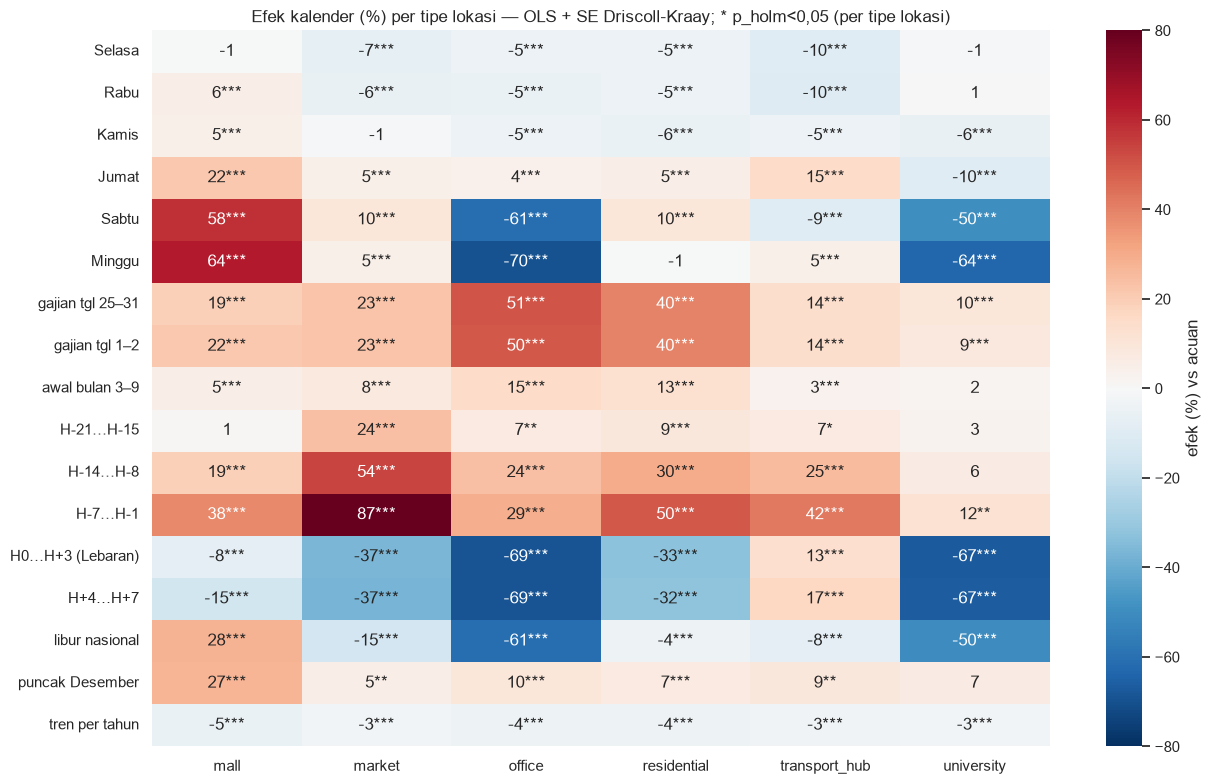

,mall,market,office,residential,transport_hub,university
Selasa,-0.6,-7.0,-4.8,-4.8,-9.9,-0.6
Rabu,5.6,-5.9,-5.4,-4.7,-10.1,0.5
Kamis,4.9,-1.2,-4.9,-5.6,-5.0,-5.7
Jumat,21.9,4.5,4.2,5.1,15.2,-9.8
Sabtu,58.3,9.7,-60.9,9.6,-9.4,-49.6
Minggu,63.7,4.8,-69.8,-0.6,4.6,-63.5
gajian tgl 25–31,18.8,23.0,50.6,39.7,13.8,10.0
gajian tgl 1–2,21.6,22.9,49.7,39.5,14.3,8.7
awal bulan 3–9,5.1,7.9,15.5,12.9,3.2,1.9
H-21…H-15,0.7,24.0,7.1,9.2,7.2,2.6


Contoh tabel lengkap — ATM kantor. INTERCEPT = log penarikan ATM acuan pada Senin, tgl 10–19, Januari, hari biasa, awal 2022 → Rp 146.7 jt/hari


,koefisien,SE_Driscoll_Kraay,p_value,ci95_lower,ci95_upper,efek_%
INTERCEPT,4.9883,0.0128,0.0000,4.9631,5.0134,14568.1017
atm_id_ATM06,-0.0371,0.0079,0.0000,-0.0526,-0.0216,-3.6445
atm_id_ATM07,0.3181,0.0079,0.0000,0.3025,0.3336,37.4449
atm_id_ATM08,-0.3737,0.0082,0.0000,-0.3897,-0.3577,-31.1842
dow_1,-0.0488,0.0075,0.0000,-0.0634,-0.0341,-4.7588
dow_2,-0.0555,0.0091,0.0000,-0.0734,-0.0377,-5.4026
dow_3,-0.0501,0.0088,0.0000,-0.0674,-0.0328,-4.8840
dow_4,0.0412,0.0084,0.0000,0.0247,0.0576,4.2034
dow_5,-0.9389,0.0083,0.0000,-0.9551,-0.9226,-60.8923
dow_6,-1.1960,0.0061,0.0000,-1.2080,-1.1840,-69.7591


GVIF model kantor:


,df,GVIF,GVIF_adj
is_december_peak,1.0,2.291,1.514
is_post_holiday,1.0,1.280,1.131
lebaran_bin,6.0,4.009,1.123
is_holiday,1.0,1.235,1.111
month,11.0,7.202,1.094
t_years,1.0,1.124,1.060
is_pre_holiday,1.0,1.105,1.051
dom_bin,4.0,1.224,1.026


In [13]:
KEY_TERMS = {"Selasa": "dow_1", "Rabu": "dow_2", "Kamis": "dow_3", "Jumat": "dow_4", "Sabtu": "dow_5", "Minggu": "dow_6",
             "gajian tgl 25–31": "dom_bin_gajian_25-31", "gajian tgl 1–2": "dom_bin_gajian_1-2", "awal bulan 3–9": "dom_bin_awal_3-9",
             "H-21…H-15": "lebaran_bin_H-21_s.d._H-15", "H-14…H-8": "lebaran_bin_H-14_s.d._H-8", "H-7…H-1": "lebaran_bin_H-7_s.d._H-1",
             "H0…H+3 (Lebaran)": "lebaran_bin_H0_s.d._H+3", "H+4…H+7": "lebaran_bin_H+4_s.d._H+7",
             "libur nasional": "is_holiday", "puncak Desember": "is_december_peak", "tren per tahun": "t_years"}
eff = pd.DataFrame({loc: {k: np.exp(m.params[v]) - 1 for k, v in KEY_TERMS.items() if v in m.params} for loc, m in cal_models.items()})
pv = pd.DataFrame({loc: {k: m.pvalues[v] for k, v in KEY_TERMS.items() if v in m.params} for loc, m in cal_models.items()})
pv_holm = pv.apply(lambda col: holm_correction(col.dropna()).reindex(col.index))
star = pv_holm.map(lambda p: "" if pd.isna(p) else ("***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""))
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(eff * 100, annot=(eff * 100).round(0).astype("Int64").astype(str) + star, fmt="", cmap="RdBu_r", center=0, vmin=-80, vmax=80,
            ax=ax, cbar_kws={"label": "efek (%) vs acuan"})
ax.set_title("Efek kalender (%) per tipe lokasi — OLS + SE Driscoll-Kraay; * p_holm<0,05 (per tipe lokasi)")
plt.tight_layout()
plt.show()
display((eff * 100).round(1))

office = cal_models["office"]
ci = office.conf_int()
office_table = pd.DataFrame({"koefisien": office.params, "SE_Driscoll_Kraay": office.bse, "p_value": office.pvalues,
                             "ci95_lower": ci[0], "ci95_upper": ci[1], "efek_%": (np.exp(office.params) - 1) * 100})
office_table.index = office_table.index.str.replace("const", "INTERCEPT")
print(f"Contoh tabel lengkap — ATM kantor. INTERCEPT = log penarikan ATM acuan pada Senin, tgl 10–19, Januari, hari biasa, awal 2022 "
      f"→ Rp {np.exp(office.params['const']):,.1f} jt/hari")
with pd.option_context("display.max_rows", 60, "display.float_format", "{:.4f}".format):
    display(office_table)
print("GVIF model kantor:")
display(cal_gvif["office"].round(3).head(8))

> **🔄 Alur data: Regresi + Error ARIMA (SARIMAX, 1 ATM)**
>
> - **Input:** Deret `example_atm` 2022–2024, desain kalender tanpa dummy ATM.
> - **Proses:**
>   1. Regresi dengan error ARIMA (SARIMAX, konstanta di bagian regresi): dua spesifikasi, AR(1) + AR musiman 7 dan AR(1) saja, dibandingkan dengan OLS tanpa AR.
>   2. Perbandingan konvergensi, AIC, BIC, log-likelihood, Ljung-Box; spesifikasi dengan AIC terkecil dipilih.
>   3. Koefisien konstanta, AR, efek kalender (%), p-value, CI; ACF residual sebelum vs sesudah AR.
> - **Output:** `sar_compare`, `sar_res`. Kedua spesifikasi konvergen; terpilih **AR(1)** (AIC −1.701 vs OLS −1.484). AR(1) = **0,43** (CI 0,38–0,49); ACF residual 0,425 → −0,005; Ljung-Box p = 0,68. Gajian +42%, pra-Lebaran +46%, Lebaran −34%, tren −4,0%/th.
> - **Berikutnya:** Interpretasi, lalu tuning rolling-origin (Bagian 8).

In [14]:
sar_atm = example_atm
g = panel[panel["atm_id"] == sar_atm].sort_values("date")
D_sar, G_sar, _ = calendar_design(g, with_atm=False)
D_sar, G_sar, sar_dropped = resolve_perfect_collinearity(D_sar, G_sar)
endog = pd.Series(g["log_y"].to_numpy(), index=pd.DatetimeIndex(g["date"]).to_period("D"))
exog = sm.add_constant(D_sar.set_index(endog.index))      # regresi dengan error ARIMA: konstanta di bagian regresi

specs = {"AR(1) + AR musiman(7)": ((1, 0, 0), (1, 0, 0, 7)), "AR(1)": ((1, 0, 0), (0, 0, 0, 0))}
sar_fits = {name: SARIMAX(endog, exog=exog, order=o, seasonal_order=so, trend="n").fit(disp=False, maxiter=1000) for name, (o, so) in specs.items()}
ols_same = sm.OLS(endog.to_numpy(), exog.to_numpy()).fit()
sar_compare = pd.DataFrame({name: {"konvergen": bool(r.mle_retvals.get("converged")), "AIC": r.aic, "BIC": r.bic, "log-likelihood": r.llf,
                                   "Ljung-Box lag 14 p": float(ljung_box(r.resid, lags=(14,))["lb_pvalue"].iloc[0])} for name, r in sar_fits.items()})
sar_compare["OLS tanpa AR"] = {"konvergen": True, "AIC": ols_same.aic, "BIC": ols_same.bic, "log-likelihood": ols_same.llf,
                               "Ljung-Box lag 14 p": float(ljung_box(ols_same.resid, lags=(14,))["lb_pvalue"].iloc[0])}
assert all(sar_compare.loc["konvergen", list(specs)]), "SARIMAX tidak konvergen"
best_sar_name = sar_compare.loc["AIC", list(specs)].astype(float).idxmin()
sar_res = sar_fits[best_sar_name]
print(f"Regresi + error ARIMA untuk {sar_atm} ({ATM_TYPES[sar_atm]}), 2022–2024. Spesifikasi terpilih (AIC terkecil): {best_sar_name}")
display(sar_compare)

ci = sar_res.conf_int()
sar_table = pd.DataFrame({"koefisien": sar_res.params, "SE": sar_res.bse, "p_value": sar_res.pvalues, "ci95_lower": ci[0], "ci95_upper": ci[1]})
ts_terms = [t for t in ["const", "ar.L1", "ar.S.L7", "sigma2"] if t in sar_table.index]
show = ts_terms + [KEY_TERMS[k] for k in ["Sabtu", "Minggu", "gajian tgl 25–31", "H-7…H-1", "H0…H+3 (Lebaran)", "libur nasional", "tren per tahun"]
                   if KEY_TERMS[k] in sar_table.index]
sar_table["efek_%"] = np.where(sar_table.index.isin(ts_terms), np.nan, (np.exp(sar_table["koefisien"]) - 1) * 100)
print(f"ACF lag-1 residual: OLS tanpa AR {pd.Series(ols_same.resid).autocorr(1):.3f} → model terpilih {pd.Series(np.asarray(sar_res.resid)).autocorr(1):.3f}")
with pd.option_context("display.float_format", "{:.4f}".format):
    display(sar_table.loc[show])

Regresi + error ARIMA untuk ATM09 (residential), 2022–2024. Spesifikasi terpilih (AIC terkecil): AR(1)


,AR(1) + AR musiman(7),AR(1),OLS tanpa AR
konvergen,True,True,True
AIC,-1699.618687,-1701.18401,-1484.32008
BIC,-1519.639478,-1526.204224,-1319.339138
log-likelihood,885.809343,885.592005,775.16004
Ljung-Box lag 14 p,0.690975,0.683491,0.0


ACF lag-1 residual: OLS tanpa AR 0.425 → model terpilih -0.005


,koefisien,SE,p_value,ci95_lower,ci95_upper,efek_%
const,4.8121,0.0237,0.0000,4.7655,4.8586,NaN
ar.L1,0.4314,0.0279,0.0000,0.3768,0.4861,NaN
sigma2,0.0116,0.0005,0.0000,0.0106,0.0127,NaN
dow_5,0.1027,0.0119,0.0000,0.0793,0.1260,10.8118
dow_6,-0.0058,0.0101,0.5642,-0.0256,0.0139,-0.5793
dom_bin_gajian_25-31,0.3501,0.0146,0.0000,0.3215,0.3787,41.9212
lebaran_bin_H-7_s.d._H-1,0.3807,0.0384,0.0000,0.3054,0.4561,46.3335
lebaran_bin_H0_s.d._H+3,-0.4207,0.0470,0.0000,-0.5128,-0.3286,-34.3436
is_holiday,-0.0162,0.0260,0.5327,-0.0671,0.0347,-1.6074
t_years,-0.0410,0.0071,0.0000,-0.0548,-0.0271,-4.0124


#### Interpretasi Model Statistik

**1. Kualitas model & multikolinearitas**
- Kalender + efek tetap ATM menjelaskan **66% (pasar) s.d. 96% (kantor)** variasi log-penarikan: kantor 0,96, kampus 0,94, transport hub 0,90, mall 0,82, perumahan 0,78, pasar 0,66. Pola kantor & kampus hampir sepenuhnya ditentukan kalender, sedangkan pasar & perumahan lebih “acak”.
- **Kolinearitas sempurna** terdeteksi otomatis: `is_semester_break` = dummy bulan Jan + Jul + Agu, sehingga dibuang (informasinya tetap ada di dummy bulan). Setelah itu semua GVIF^(1/(2·df)) ≤ 1,51 (aman).

**2. Kenapa SE Driscoll-Kraay wajib**
- Residual model statis punya **autokorelasi lag-1 0,43–0,47** di semua tipe lokasi (hari ini mirip kemarin). Autokorelasi lag-7 ≈ 0, karena pola mingguan sudah tertangkap dummy hari.
- SE Driscoll-Kraay **15–39% lebih besar** daripada SE biasa (median rasio 1,15–1,39). Tanpa koreksi ini, p-value akan terlalu optimistis.

**3. Intercept**: contoh ATM kantor. **Rp 146,7 jt/hari** adalah penarikan ATM kantor acuan pada **Senin, tanggal 10–19, Januari, hari biasa, awal 2022**. Semua efek di heatmap dibaca relatif terhadap kondisi ini.

**4. Efek kalender (%, semua signifikan kecuali yang tidak bertanda bintang di heatmap)**

| Efek | Kantor | Kampus | Mall | Transport | Perumahan | Pasar |
|---|---|---|---|---|---|---|
| Sabtu / Minggu | **−61% / −70%** | −50% / −64% | **+58% / +64%** | −9% / +5% | +10% / −1% | +10% / +5% |
| Gajian tgl 25–31 | **+51%** | +10% | +19% | +14% | +40% | +23% |
| H-7…H-1 Lebaran | +29% | +12% | +39% | +42% | +50% | **+87%** |
| H0…H+3 Lebaran | **−69%** | −68% | −8% | **+14%** | −33% | −37% |
| Libur nasional | −61% | −50% | **+28%** | −8% | −4% | −15% |
| Tren per tahun | −4,1% | −3,0% | −5,3% | −3,2% | −4,0% | −3,1% |

- Efek yang **berlawanan arah** antar lokasi (akhir pekan & libur: kantor anjlok, mall naik; saat Lebaran: kantor/kampus −68%, transport hub **naik** +14% karena arus mudik) membuktikan bahwa satu model “rata-rata” untuk semua ATM akan salah. Inilah alasan model Gradient Boosting di bagian berikutnya diberi fitur **tipe lokasi** agar bisa belajar interaksi “kalender × lokasi”.
- Pasar adalah lokasi yang paling sensitif terhadap pra-Lebaran (+87%), sesuai pola belanja kebutuhan Lebaran.
- **Tren turun di semua lokasi** (−3% s.d. −5% per tahun, signifikan), konsisten dengan uji tren di Bagian 4.

**5. Regresi + error ARIMA (ATM09, perumahan)**
- Kedua spesifikasi **konvergen**. **AR(1)** dipilih (AIC −1.701 vs −1.700 dengan AR musiman; koefisien AR musiman tidak signifikan), dan jauh lebih baik daripada OLS tanpa AR (AIC −1.484).
- **AR(1) = 0,43** (CI 0,38–0,49): kejutan hari ini terbawa ±43% ke esok hari. Setelah AR dimodelkan, autokorelasi residual lag-1 turun dari **0,425 ke −0,005**, dan Ljung-Box tidak lagi menolak (p = 0,68 vs p ≈ 0 untuk OLS).
- Efek kalender untuk ATM ini konsisten dengan model panel perumahan: gajian **+42%**, pra-Lebaran **+46%**, saat Lebaran **−34%**, Sabtu +11%, tren **−4,0%/tahun**.
- **Implikasi untuk forecasting:** informasi beberapa hari terakhir (lag) memang berguna. Inilah dasar fitur `lag_1`, `lag_2`, … pada model Gradient Boosting.

## 8. Tuning di 2023 (Rolling-Origin)

Setiap konfigurasi diuji di 8 origin tahun 2023. Kriteria: **WAPE terendah**. Konfigurasi terbaik untuk masing-masing keluarga model (GBR dan ETS) dibawa ke tahap pemilihan.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Tuning dengan data 2023.** Setiap model punya pengaturan, misalnya jumlah pohon dan kecepatan belajar. Berbagai kombinasi diuji dengan rolling-origin di tahun 2023, lalu dipilih yang kesalahannya (**WAPE**) paling kecil.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Menyetel "tombol pengaturan"** setiap model menggunakan data tahun **2023**. Contoh tombolnya: berapa banyak pohon, atau seberapa cepat model belajar. Setiap kombinasi diuji dengan rolling-origin, lalu dipilih yang kesalahannya (**WAPE**) paling kecil.

> **🔄 Alur data: Tuning 2023**
>
> - **Input:** `W`, 8 origin 2023, 5 konfigurasi.
> - **Proses:**
>   1. Untuk setiap origin (paralel): latih semua konfigurasi dengan data ≤ origin, lalu ramal 14 hari.
>   2. WAPE, bias, MAE, sMAPE per konfigurasi + std WAPE antar origin.
> - **Output:** `tuning`. GBR: gbr_c **12,1%** (600 pohon, depth 5, lr 0,03), gbr_b 12,4%, gbr_a 12,9%. ETS: 2 tahun 19,5%, 1 tahun 19,8%. Terpilih: `BEST_GBR = gbr_c`, `BEST_ETS = ets_2y`.
> - **Berikutnya:** Seleksi model di 2024.

In [15]:
bt_tune = rolling_origin(TUNE_FACTORIES, W, TUNE_ORIGINS, HORIZON)
tuning = metrics_by(bt_tune, "model")[["wape", "bias", "mae", "smape"]]
tuning["keluarga"] = np.where(tuning.index.str.startswith("gbr"), "gbr", "ets")
per_origin = bt_tune.groupby(["model", "origin"]).apply(lambda g: forecast_metrics(g)["wape"], include_groups=False).unstack()
tuning["wape_std_antar_origin"] = per_origin.std(axis=1)
display(tuning.sort_values("wape").round(4))

BEST_GBR = tuning[tuning["keluarga"] == "gbr"]["wape"].idxmin()
BEST_ETS = tuning[tuning["keluarga"] == "ets"]["wape"].idxmin()
print(f"Terbaik: GBR = {BEST_GBR} {GBR_GRID[BEST_GBR]} | ETS = {BEST_ETS} {ETS_GRID[BEST_ETS]}")

,wape,bias,mae,smape,keluarga,wape_std_antar_origin
model,,,,,,
gbr_c,0.1214,0.0007,18.5855,0.1276,gbr,0.0143
gbr_b,0.1243,-0.0020,19.0293,0.1294,gbr,0.0161
gbr_a,0.1293,-0.0121,19.7919,0.1363,gbr,0.0183
ets_2y,0.1954,0.0044,29.9000,0.2051,ets,0.0302
ets_1y,0.1981,0.0092,30.3226,0.2079,ets,0.0329


Terbaik: GBR = gbr_c {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.7} | ETS = ets_2y {'damped': 'auto', 'train_days': 730}


## 9. Pemilihan Model di 2024 (Rolling-Origin, 26 Origin)

Tiga metode diuji di **seluruh tahun 2024** (26 jendela × 14 hari, tanpa tumpang tindih), termasuk Lebaran 2024.

**Aturan:** model dengan **WAPE 2024 terendah** dipilih. Signifikansi diuji dengan:
- **Diebold-Mariano** pada deret harian total absolute error (koreksi Newey-West untuk autokorelasi multi-step + koreksi sampel kecil HLN),
- **Wilcoxon signed-rank** pada WAPE per lintasan (origin × ATM, 520 pasangan).

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Pemilihan model dengan data 2024**: 26 kali ramalan 14 hari sepanjang tahun, termasuk Lebaran 2024.

**Model terpilih: Gradient Boosting**, dengan kesalahan terkecil.

**Apakah keunggulannya nyata?** Uji **Diebold-Mariano** dan **Wilcoxon** memastikan selisihnya **bukan kebetulan** ✅.

**Cara membaca grafik:** garis yang **lebih rendah** berarti kesalahan lebih kecil. Perhatikan lonjakan kesalahan di sekitar Lebaran: lonjakan Holt-Winters jauh lebih tinggi karena metode ini tidak mengenal kalender Lebaran.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Ujian coba** di seluruh tahun **2024** (26 kali ramalan 14 hari, termasuk Lebaran 2024). Model dengan kesalahan terkecil dipilih: **Gradient Boosting**.

**Apakah unggulnya nyata?** Uji **Diebold-Mariano** dan **Wilcoxon** memastikan selisihnya **bukan kebetulan**.

**Cara membaca grafik:** garis yang **lebih rendah** = kesalahan lebih kecil = lebih baik. Perhatikan lonjakan kesalahan di sekitar Lebaran: lonjakan pada Holt-Winters jauh lebih tinggi.

> **🔄 Alur data: Backtest Seleksi 2024**
>
> - **Input:** `W`, 26 origin 2024, 3 metode (konfigurasi terbaik).
> - **Proses:**
>   1. Rolling-origin → `bt_2024` (ramalan, aktual, error, residual log).
>   2. Skala MASE per origin × ATM (MAE seasonal naive 365 hari sebelum origin).
>   3. Metrik per metode, lalu model dengan WAPE terendah dipilih (di luar naive).
> - **Output:** `bt_2024` (3 metode × 7.280 ramalan). WAPE: **GBR 12,3%**, ETS 21,9%, naive 24,9%; MASE GBR 0,57. `best_name = "gbr"`.
> - **Berikutnya:** Uji signifikansi & grafik.

In [16]:
SELECT_FACTORIES = {"seasonal_naive": SeasonalNaive, "ets": ets_factory(ETS_GRID[BEST_ETS]), "gbr": gbr_factory(GBR_GRID[BEST_GBR])}
bt_2024 = rolling_origin(SELECT_FACTORIES, W, SELECT_ORIGINS, HORIZON)
bt_2024 = bt_2024.merge(naive_scale(W, SELECT_ORIGINS), on=["origin", "atm_id"])
sel = metrics_by(bt_2024, "model")
sel.index = sel.index.map(MODEL_LABELS)
display(sel.sort_values("wape").round(4))

best_name = metrics_by(bt_2024[bt_2024["model"] != "seasonal_naive"], "model")["wape"].idxmin()
other_name = "ets" if best_name == "gbr" else "gbr"
print(f"Model terpilih: {MODEL_LABELS[best_name]}")

,wape,bias,mae,rmse,smape,mase
model,,,,,,
Gradient Boosting,0.1226,-0.0024,17.7875,25.0275,0.1269,0.5739
Holt-Winters (ETS),0.2185,0.0179,31.6966,45.9794,0.2216,1.0200
Seasonal naive,0.2491,0.0114,36.1434,51.0987,0.2559,1.1596


Model terpilih: Gradient Boosting


> **🔄 Alur data: Uji Signifikansi 2024**
>
> - **Input:** `bt_2024`.
> - **Proses:**
>   1. `daily_loss`: total |error| per tanggal; `path_wape`: WAPE per lintasan origin × ATM.
>   2. Diebold-Mariano (Newey-West lag 14 + HLN) dan Wilcoxon untuk 3 pasangan.
>   3. Grafik WAPE per horizon & per origin.
> - **Output:** `sel_tests` + 2 grafik. GBR vs ETS: DM p ≈ 1,5×10⁻⁷, Wilcoxon p ≈ 10⁻⁵⁸, GBR lebih baik di 81% lintasan. Lonjakan error ETS terlihat jelas di sekitar Lebaran 2024.
> - **Berikutnya:** Kalibrasi interval.

,DM_HLN,DM_p,wilcoxon_p,Gradient Boosting_lebih_baik_%_lintasan,Holt-Winters (ETS)_lebih_baik_%_lintasan
pembanding,,,,,
Gradient Boosting vs Holt-Winters (ETS),-5.364,1.451e-07,1.019e-58,0.8115,NaN
Gradient Boosting vs Seasonal naive,-7.264,2.312e-12,2.129e-80,0.9231,NaN
Holt-Winters (ETS) vs Seasonal naive,-6.06,3.417e-09,1.005e-23,NaN,0.7173


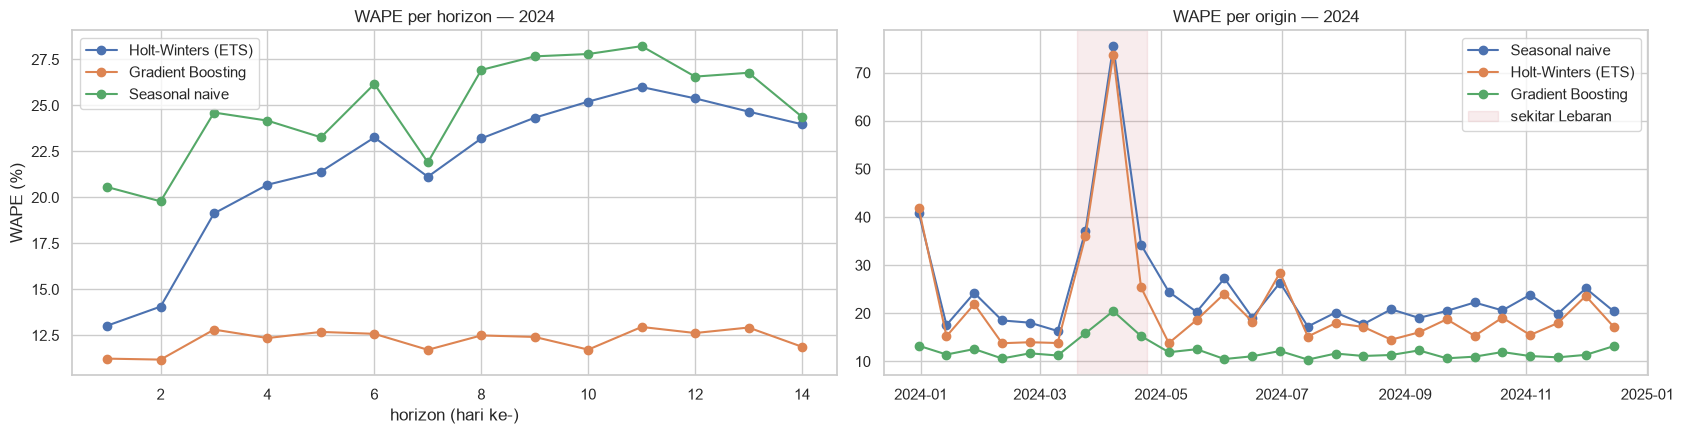

In [17]:
def daily_loss(bt, model):
    return bt[bt["model"] == model].groupby("date")["error"].apply(lambda e: e.abs().sum())


def path_wape(bt, model):
    g = bt[bt["model"] == model].groupby(["origin", "atm_id"])
    return g["error"].apply(lambda e: e.abs().sum()) / g["y"].sum()


def compare_models(bt, a, b):
    dm = diebold_mariano(daily_loss(bt, a), daily_loss(bt, b), h=HORIZON)
    pa, pb = path_wape(bt, a), path_wape(bt, b)
    w = stats.wilcoxon(pa, pb)
    return {"pembanding": f"{MODEL_LABELS[a]} vs {MODEL_LABELS[b]}", "DM_HLN": dm["DM_HLN"], "DM_p": dm["p_value"],
            "wilcoxon_p": w.pvalue, f"{MODEL_LABELS[a]}_lebih_baik_%_lintasan": (pa < pb).mean()}


sel_tests = pd.DataFrame([compare_models(bt_2024, best_name, other_name), compare_models(bt_2024, best_name, "seasonal_naive"),
                          compare_models(bt_2024, other_name, "seasonal_naive")]).set_index("pembanding")
with pd.option_context("display.float_format", "{:.4g}".format):
    display(sel_tests)

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
for m, g in metrics_by(bt_2024, ["model", "h"])["wape"].groupby(level=0):
    axes[0].plot(g.index.get_level_values("h"), g.values * 100, "o-", label=MODEL_LABELS[m])
axes[0].set_xlabel("horizon (hari ke-)")
axes[0].set_ylabel("WAPE (%)")
axes[0].set_title("WAPE per horizon — 2024")
axes[0].legend()
for m in ["seasonal_naive", "ets", "gbr"]:
    w = bt_2024[bt_2024["model"] == m].groupby("origin").apply(lambda g: forecast_metrics(g)["wape"], include_groups=False)
    axes[1].plot(w.index, w.values * 100, "o-", label=MODEL_LABELS[m])
axes[1].axvspan(pd.Timestamp("2024-03-20"), pd.Timestamp("2024-04-24"), color="#C44E52", alpha=0.1, label="sekitar Lebaran")
axes[1].set_title("WAPE per origin — 2024")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Interval Prediksi (Kalibrasi di 2024)

Ketidakpastian ramalan **membesar seiring horizon**. Interval dibuat dari **kuantil empiris residual log** (aktual − ramalan) model terpilih di backtest 2024, **per horizon**:

ramalan_q = ramalan × exp(kuantil residual_q, h)

Kuantil yang disimpan: P05, P10, P50, P90, P95. Interval 80% = [P10, P90] dan interval 90% = [P05, P95]. Kalibrasi ini **hanya** memakai 2024, lalu cakupannya diuji di 2025 (Bagian 11).

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Ramalan tunggal (misalnya Rp 150 jt) tidak cukup. Bank juga perlu tahu ***berapa kira-kira jumlah maksimumnya***, agar ATM tidak kosong.

**Rentang ramalan** dibuat dari catatan kesalahan ramalan selama 2024. Jika sebagian besar kesalahan berada di antara −20% dan +25%, rentangnya adalah ramalan −20% sampai +25%.

- **Makin jauh ke depan, makin lebar rentangnya.** Ramalan besok lebih pasti daripada ramalan dua minggu lagi, sama seperti prakiraan cuaca.
- **P90** = jumlah yang hanya terlampaui pada sekitar **1 dari 10 hari**. Jika ATM diisi sebesar P90, peluang uang habis sekitar 10%.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Ramalan tunggal (misalnya "Rp 150 jt") **tidak cukup**. Bank perlu tahu ***"paling banyak kira-kira berapa?"*** agar ATM tidak kosong.

**Interval prediksi** dibuat dari catatan kesalahan ramalan selama 2024. Contohnya, jika 90% kesalahan berada antara −20% dan +25%, rentang ramalan adalah ramalan −20% sampai +25%.

- **Makin jauh ke depan, makin lebar rentangnya.** Ramalan untuk besok lebih yakin daripada ramalan untuk 2 minggu lagi, sama seperti ramalan cuaca.
- **P90** = jumlah yang **hanya 10% kemungkinan terlampaui**. Kalau ATM diisi sebanyak P90, peluang uangnya habis sekitar 10%.

> **🔄 Alur data: Kuantil Interval per Horizon**
>
> - **Input:** Residual log model terpilih di 2024.
> - **Proses:**
>   1. Kuantil P05, P10, P50, P90, P95 per horizon 1–14 → `INTERVALS`.
> - **Output:** `INTERVALS` (14 horizon × 5 kuantil). Interval 80% ≈ ramalan × [0,80–0,84; 1,17–1,22]; interval 90% ≈ × [0,75–0,79; 1,24–1,31]. Lebarnya hampir konstan antar horizon, karena lag mingguan (7, 14, 21, 28) tetap tersedia dari data aktual.
> - **Berikutnya:** Uji akhir 2025.

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
q05,0.791,0.784,0.752,0.760,0.759,0.756,0.768,0.753,0.750,0.757,0.770,0.759,0.760,0.764
q10,0.838,0.821,0.811,0.810,0.800,0.819,0.818,0.809,0.804,0.817,0.795,0.798,0.814,0.819
q50,0.976,0.986,0.988,0.998,1.008,0.987,0.988,0.997,0.972,0.982,0.982,0.979,0.992,0.994
q90,1.187,1.186,1.212,1.206,1.217,1.218,1.200,1.222,1.174,1.191,1.212,1.214,1.208,1.200
q95,1.255,1.236,1.281,1.293,1.292,1.314,1.271,1.296,1.257,1.286,1.271,1.282,1.289,1.278


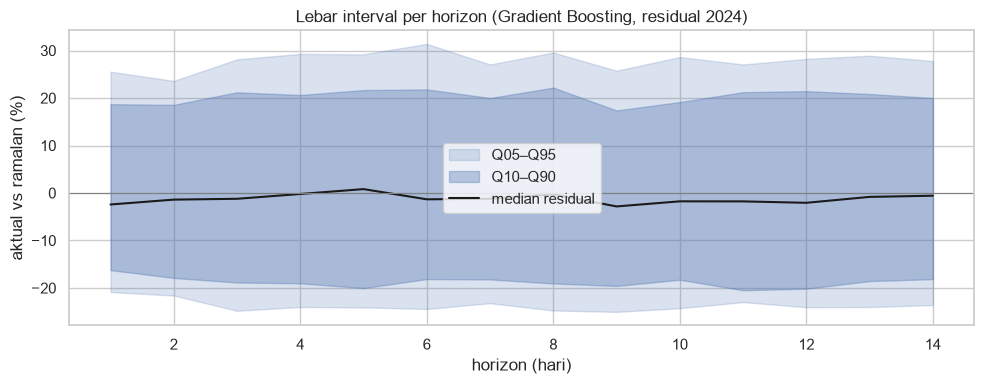

In [18]:
res_2024 = bt_2024[bt_2024["model"] == best_name]
INTERVALS = interval_quantiles(res_2024["log_resid"], res_2024["h"])
display(np.exp(INTERVALS).round(3).T)

fig, ax = plt.subplots(figsize=(10, 4))
for lo, hi, a in [("q05", "q95", 0.2), ("q10", "q90", 0.35)]:
    ax.fill_between(INTERVALS.index, (np.exp(INTERVALS[lo]) - 1) * 100, (np.exp(INTERVALS[hi]) - 1) * 100, alpha=a, color="#4C72B0",
                    label=f"{lo.upper()}–{hi.upper()}")
ax.plot(INTERVALS.index, (np.exp(INTERVALS["q50"]) - 1) * 100, "k-", label="median residual")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("horizon (hari)")
ax.set_ylabel("aktual vs ramalan (%)")
ax.set_title(f"Lebar interval per horizon ({MODEL_LABELS[best_name]}, residual 2024)")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Backtest Akhir 2025 (Out-of-Time)

Ketiga metode dijalankan ulang di 26 origin tahun 2025 dengan konfigurasi yang dipilih di 2023–2024. Tahun ini belum pernah dipakai untuk keputusan apa pun.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Ujian akhir: tahun 2025** diputar ulang. Data ini tidak pernah dipakai saat membangun model.

**Hasil Gradient Boosting:**
- **WAPE 11,6%** → rata-rata ramalan meleset sekitar 12%.
- **MASE 0,53** → kesalahannya hampir **separuh** cara "sama seperti minggu lalu".
- Kesalahan **48% lebih kecil** daripada cara sederhana dan **42% lebih kecil** daripada Holt-Winters. Keunggulan ini **signifikan**.
- **Tidak bias** (−0,15%).
- **Stabil sepanjang tahun**: kesalahan per periode 9,9–14,7%.

**Kinerja saat Lebaran:**
| Fase | Gradient Boosting | Holt-Winters |
|---|---|---|
| Seminggu sebelum (puncak) | **12%** | 29% |
| Hari Lebaran s.d. H+3 (anjlok) | **22%** | **52%** |

Holt-Winters tidak mengenal kalender Lebaran, sehingga ramalannya **terlalu rendah** saat puncak (risiko ATM kosong) dan **terlalu tinggi** saat anjlok (uang menganggur).

**Rentang ramalan:** rentang 80% tepat pada **82%** hari, dan rentang 90% tepat pada **92%** hari. Sedikit lebih lebar dari target ⚠️, tetapi untuk pengelolaan kas ATM, kelebihan kecil ini justru lebih aman.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Inilah **ujian akhir**: tahun **2025 yang disegel** diputar ulang. Model tidak pernah melihat data 2025 saat dibuat.

**Hasil Gradient Boosting:**
- **WAPE 11,6%** → secara rata-rata ramalan meleset ±12%.
- **MASE 0,53** → kesalahannya **hampir separuh** dari cara "sama seperti minggu lalu".
- Kesalahan **48% lebih kecil** daripada cara sederhana dan **42% lebih kecil** daripada Holt-Winters. Selisih ini **pasti bukan kebetulan** (p-value sangat kecil).
- **Tidak condong:** bias −0,15%.
- **Stabil sepanjang tahun:** kesalahan per periode 9,9–14,7%, tanpa tanda memburuk.

**Saat Lebaran:**

| Fase | Gradient Boosting | Holt-Winters |
|---|---|---|
| Seminggu sebelum (puncak) | 12% | 29% |
| Lebaran s.d. H+3 (anjlok) | 22% | **52%** |

Holt-Winters tidak tahu kapan Lebaran, sehingga ramalannya **kurang** saat puncak (risiko ATM kosong) dan **berlebih** saat anjlok (uang menganggur).

**Rentang ramalan:** rentang 80% berisi kenyataan pada **82%** hari, dan rentang 90% pada **92%** hari. Rentangnya sedikit lebih lebar dari yang perlu (⚠️), tetapi untuk urusan kas ATM, sedikit berlebih lebih aman daripada kurang.

> **🔄 Alur data: Backtest Akhir 2025**
>
> - **Input:** `W`, 26 origin 2025 (dipakai pertama kali).
> - **Proses:**
>   1. Rolling-origin 3 metode → `bt_2025`; metrik per metode.
>   2. Cluster bootstrap 1.000× (resample lintasan origin × ATM) → 95% CI.
>   3. Forecast Value Added = pengurangan WAPE dibanding naive & ETS.
> - **Output:** `bt_2025`, `final_ci`. GBR: WAPE **11,57%** [11,27–11,85%], bias −0,15% [−0,78…+0,56%], MASE 0,53. ETS 19,9%, naive 22,1%. FVA: **−48%** vs naive, **−42%** vs ETS.
> - **Berikutnya:** Uji signifikansi 2025.

In [19]:
bt_2025 = rolling_origin(SELECT_FACTORIES, W, TEST_ORIGINS, HORIZON)
bt_2025 = bt_2025.merge(naive_scale(W, TEST_ORIGINS), on=["origin", "atm_id"])
test_metrics = metrics_by(bt_2025, "model")
test_metrics.index = test_metrics.index.map(MODEL_LABELS)
display(test_metrics.sort_values("wape").round(4))

best_bt = bt_2025[bt_2025["model"] == best_name].copy()
final_ci = cluster_bootstrap_ci(best_bt, n_boot=1000, seed=RANDOM_STATE)
print(f"Cluster bootstrap 95% CI ({MODEL_LABELS[best_name]}, 1.000×, resample {best_bt.groupby(['origin', 'atm_id']).ngroups} lintasan):")
display(final_ci.round(4))

fva = pd.Series({f"vs {MODEL_LABELS[m]}": 1 - test_metrics.loc[MODEL_LABELS[best_name], "wape"] / test_metrics.loc[MODEL_LABELS[m], "wape"]
                 for m in ["seasonal_naive", other_name]})
print("Forecast Value Added (pengurangan WAPE):", (fva * 100).round(1).astype(str).add("%").to_dict())

,wape,bias,mae,rmse,smape,mase
model,,,,,,
Gradient Boosting,0.1157,-0.0015,16.0135,22.3007,0.1183,0.5281
Holt-Winters (ETS),0.1993,-0.0097,27.5857,38.5725,0.2121,0.9187
Seasonal naive,0.2206,-0.0101,30.5414,41.8518,0.2336,1.0140


Cluster bootstrap 95% CI (Gradient Boosting, 1.000×, resample 520 lintasan):


,estimate,ci_lower,ci_upper,std_error
wape,0.1157,0.1127,0.1185,0.0015
bias,-0.0015,-0.0078,0.0056,0.0034
mae,16.0135,15.3543,16.7110,0.3396
rmse,22.3007,21.3647,23.2361,0.4908
smape,0.1183,0.1150,0.1215,0.0017
mase,0.5281,0.5127,0.5443,0.0083


Forecast Value Added (pengurangan WAPE): {'vs Seasonal naive': '47.6%', 'vs Holt-Winters (ETS)': '42.0%'}


> **🔄 Alur data: Uji Signifikansi & Stabilitas 2025**
>
> - **Input:** `bt_2025`.
> - **Proses:**
>   1. Diebold-Mariano & Wilcoxon untuk 3 pasangan model.
>   2. WAPE per origin dan uji tren Spearman (apakah performa memburuk sepanjang tahun?).
> - **Output:** `test_tests`. GBR vs ETS: DM = −8,65, p ≈ 1,6×10⁻¹⁶ (GBR lebih baik di 84% lintasan). GBR vs naive: p ≈ 1,9×10⁻³¹. WAPE per origin 9,9–14,7% (terburuk: jendela Lebaran), tren p = 0,12.
> - **Berikutnya:** Uji cakupan interval.

In [20]:
test_tests = pd.DataFrame([compare_models(bt_2025, best_name, other_name), compare_models(bt_2025, best_name, "seasonal_naive"),
                           compare_models(bt_2025, other_name, "seasonal_naive")]).set_index("pembanding")
with pd.option_context("display.float_format", "{:.4g}".format):
    display(test_tests)

ow = best_bt.groupby("origin").apply(lambda g: forecast_metrics(g)["wape"], include_groups=False)
rho, p_trend = stats.spearmanr(np.arange(len(ow)), ow)
print(f"WAPE per origin 2025: rata-rata {ow.mean():.2%}, min {ow.min():.2%}, maks {ow.max():.2%} (origin {ow.idxmax().date()}); "
      f"tren Spearman ρ = {rho:+.2f}, p = {p_trend:.3f}")

,DM_HLN,DM_p,wilcoxon_p,Gradient Boosting_lebih_baik_%_lintasan,Holt-Winters (ETS)_lebih_baik_%_lintasan
pembanding,,,,,
Gradient Boosting vs Holt-Winters (ETS),-8.654,1.634e-16,2.041e-65,0.8365,NaN
Gradient Boosting vs Seasonal naive,-12.86,1.866e-31,1.443e-82,0.9442,NaN
Holt-Winters (ETS) vs Seasonal naive,-4.642,4.831e-06,4.231e-18,NaN,0.6904


WAPE per origin 2025: rata-rata 11.54%, min 9.87%, maks 14.74% (origin 2025-03-23); tren Spearman ρ = -0.31, p = 0.121


> **🔄 Alur data: Cakupan Interval 2025**
>
> - **Input:** `best_bt`, `INTERVALS`.
> - **Proses:**
>   1. Untuk interval 80% (P10–P90) & 90% (P05–P95): % residual di dalam interval, uji binomial vs nominal, dan % di bawah/di atas.
>   2. Grafik WAPE per horizon, cakupan per horizon, dan contoh ramalan ±Lebaran 2025.
> - **Output:** `coverage`. P10–P90: **82,0%** (target 80%), P05–P95: **92,2%** (target 90%). Keduanya sedikit lebih lebar dari target (p < 0,001), dan meleset seimbang di bawah/atas (8,6%/9,3%).
> - **Berikutnya:** Cek bias per segmen.

,nominal,coverage,ci_lower,ci_upper,n,p_value,di_bawah,di_atas
interval,,,,,,,,
Q10–Q90,0.8,0.8205,0.8115,0.8291,7280,0.0,0.0861,0.0934
Q05–Q95,0.9,0.9221,0.9157,0.9281,7280,0.0,0.0364,0.0415


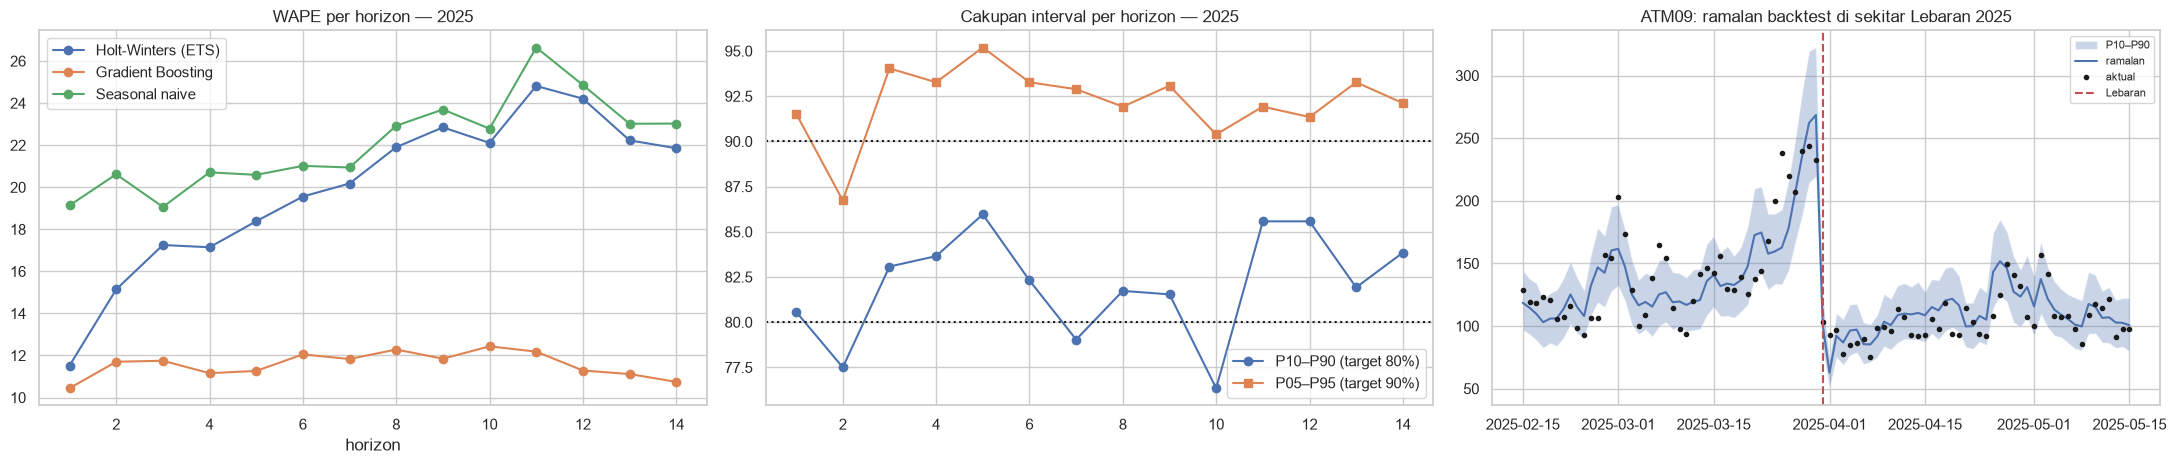

In [21]:
cov_rows = []
for lo, hi, nominal in [("q10", "q90", 0.80), ("q05", "q95", 0.90)]:
    q = INTERVALS.loc[best_bt["h"]]
    inside = (best_bt["log_resid"].to_numpy() >= q[lo].to_numpy()) & (best_bt["log_resid"].to_numpy() <= q[hi].to_numpy())
    best_bt[f"in_{lo}_{hi}"] = inside
    cov_rows.append({"interval": f"{lo.upper()}–{hi.upper()}", "nominal": nominal, **coverage_test(inside, nominal),
                     "di_bawah": (best_bt["log_resid"].to_numpy() < q[lo].to_numpy()).mean(),
                     "di_atas": (best_bt["log_resid"].to_numpy() > q[hi].to_numpy()).mean()})
coverage = pd.DataFrame(cov_rows).set_index("interval")
display(coverage.round(4))
cov_h = best_bt.groupby("h")[["in_q10_q90", "in_q05_q95"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(22, 4.8))
for m, g in metrics_by(bt_2025, ["model", "h"])["wape"].groupby(level=0):
    axes[0].plot(g.index.get_level_values("h"), g.values * 100, "o-", label=MODEL_LABELS[m])
axes[0].set_title("WAPE per horizon — 2025")
axes[0].set_xlabel("horizon")
axes[0].legend()
axes[1].plot(cov_h.index, cov_h["in_q10_q90"] * 100, "o-", label="P10–P90 (target 80%)")
axes[1].plot(cov_h.index, cov_h["in_q05_q95"] * 100, "s-", label="P05–P95 (target 90%)")
for y in (80, 90):
    axes[1].axhline(y, color="k", ls=":")
axes[1].set_title("Cakupan interval per horizon — 2025")
axes[1].legend()
one = best_bt[best_bt["atm_id"] == example_atm].sort_values("date")
one = one[(one["date"] >= "2025-02-15") & (one["date"] <= "2025-05-15")]
axes[2].fill_between(one["date"], np.expm1(one["yhat_log"] + INTERVALS.loc[one["h"], "q10"].to_numpy()),
                     np.expm1(one["yhat_log"] + INTERVALS.loc[one["h"], "q90"].to_numpy()), alpha=0.3, label="P10–P90")
axes[2].plot(one["date"], one["yhat"], label="ramalan")
axes[2].plot(one["date"], one["y"], "k.", label="aktual")
axes[2].axvline(pd.Timestamp("2025-03-31"), color="#C44E52", ls="--", label="Lebaran")
axes[2].set_title(f"{example_atm}: ramalan backtest di sekitar Lebaran 2025")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

> **🔄 Alur data: Bias per Segmen & Fase Lebaran**
>
> - **Input:** `best_bt` + kalender.
> - **Proses:**
>   1. `segment_bias` per tipe lokasi, fase Lebaran, jendela gajian, hari: WAPE, bias, t-test pada bias per lintasan (Holm).
>   2. Status: “bias material” jika signifikan **dan** |bias| > 2%; “signifikan tapi kecil” jika signifikan tetapi ≤ 2%.
>   3. WAPE per fase Lebaran: model terpilih vs ETS.
> - **Output:** `seg_all`. **0 segmen bias material**; 4 signifikan tapi kecil (0,3–0,7%). WAPE per fase Lebaran: GBR H0…H+3 **21,9%** vs ETS **52,3%**; H-7…H-1 12,2% vs 28,6%.
> - **Berikutnya:** Diagnostik residual 1 langkah.

In [22]:
best_bt = best_bt.merge(calendar_frame(best_bt["date"].unique()), on="date").assign(location_type=lambda d: d["atm_id"].map(ATM_TYPES))
segments = {}
for col in ["location_type", "lebaran_bin", "dom_bin", "dow"]:
    segments[col] = segment_bias(best_bt, col)
seg_all = pd.concat(segments, names=["dimensi"])
seg_all["status"] = np.select([(seg_all["p_holm"] < 0.05) & (seg_all["bias"].abs() > 0.02), seg_all["p_holm"] < 0.05],
                              ["bias material (>2%)", "signifikan tapi kecil (≤2%)"], default="ok")
display(seg_all.round(4))

ets_bt = bt_2025[bt_2025["model"] == other_name].merge(calendar_frame(bt_2025["date"].unique()), on="date")
leb = pd.DataFrame({MODEL_LABELS[best_name]: metrics_by(best_bt, "lebaran_bin")["wape"], MODEL_LABELS[other_name]: metrics_by(ets_bt, "lebaran_bin")["wape"]})
print("WAPE per fase Lebaran 2025:")
display(leb.round(4))

n_hari    wape    bias  p_value  p_holm                       status
dimensi                                                                                            
location_type mall               1456  0.1185 -0.0045   0.9896  1.0000                           ok
              market              728  0.1112  0.0128   0.0755  0.4528                           ok
              office             1456  0.1230 -0.0083   0.7354  1.0000                           ok
              residential        1820  0.1103 -0.0019   0.4274  1.0000                           ok
              transport_hub      1092  0.1107  0.0039   0.5463  1.0000                           ok
              university          728  0.1300 -0.0075   0.9311  1.0000                           ok
lebaran_bin   H+4_s.d._H+7         80  0.1661 -0.0026   0.0772  0.3859                           ok
              H+8_s.d._H+14       140  0.1419  0.0733   0.0221  0.1328                           ok
              H-14_s.d._H-8       140  0.1093 -0.0125   0.2662  0.7986                           ok
              H-21_s.d._H-15      140  0.1172 -0.0359   0.0180  0.1262                           ok
              H-7_s.d._H-1        140  0.1216 -0.0077   0.2773  0.7986                           ok
              H0_s.d._H+3          80  0.2187 -0.0648   0.5111  0.7986                           ok
              normal             6560  0.1136 -0.0009   0.1635  0.6539                           ok
dom_bin       awal_3-9           1680  0.1140  0.0026   0.0047  0.0186  signifikan tapi kecil (≤2%)
              gajian_1-2          480  0.1247 -0.0226   0.7663  1.0000                           ok
              gajian_25-31       1520  0.1194 -0.0060   0.9942  1.0000                           ok
              menjelang_20-24    1200  0.1079 -0.0027   0.0691  0.2073                           ok
              tengah_10-19       2400  0.1156  0.0051   0.0013  0.0063  signifikan tapi kecil (≤2%)
dow           0                  1040  0.1135  0.0066   0.0003  0.0020  signifikan tapi kecil (≤2%)
              1                  1040  0.1177  0.0005   0.0122  0.0612                           ok
              2                  1040  0.1209  0.0002   0.0569  0.1707                           ok
              3                  1040  0.1166 -0.0055   0.1413  0.2825                           ok
              4                  1040  0.1128 -0.0040   0.1444  0.2825                           ok
              5                  1040  0.1159 -0.0041   0.0068  0.0409  signifikan tapi kecil (≤2%)
              6                  1040  0.1129 -0.0035   0.0236  0.0942                           ok

WAPE per fase Lebaran 2025:


,Gradient Boosting,Holt-Winters (ETS)
lebaran_bin,,
H+4_s.d._H+7,0.1661,0.4347
H+8_s.d._H+14,0.1419,0.2242
H-14_s.d._H-8,0.1093,0.1755
H-21_s.d._H-15,0.1172,0.1359
H-7_s.d._H-1,0.1216,0.2863
H0_s.d._H+3,0.2187,0.5234
normal,0.1136,0.1923


### Interpretasi Backtest 2025

**Akurasi & signifikansi**
- Di 2025, Gradient Boosting mencapai **WAPE 11,6%** (95% CI cluster bootstrap 11,3–11,9%) dan **MASE 0,53**, yaitu error-nya hampir setengah dari seasonal naive. ETS: WAPE 19,9%; seasonal naive: 22,1%.
- **Forecast Value Added**: error berkurang **48%** dibanding naive dan **42%** dibanding Holt-Winters.
- Keunggulan ini **signifikan dan konsisten**: Diebold-Mariano vs ETS p ≈ 10⁻¹⁶, vs naive p ≈ 10⁻³¹. GBR lebih akurat di **84%** lintasan ATM × origin dibanding ETS, dan di 94% lintasan dibanding naive.
- Hasil 2025 (WAPE 11,6%) sejalan dengan hasil pemilihan di 2024 (12,3%), sehingga tidak ada tanda overfitting ke tahun pemilihan.
- **Tidak bias**: −0,15% (CI −0,8% s.d. +0,6%).
- **Stabil sepanjang tahun**: WAPE per origin 9,9–14,7%, tanpa tren memburuk (Spearman p = 0,12). Origin terburuk 23 Mar 2025 adalah jendela yang memuat hari Lebaran.

**Lebaran: di sinilah perbedaan terbesar**

| Fase | GBR | ETS |
|---|---|---|
| H-7…H-1 (puncak penarikan) | 12,2% | 28,6% |
| H0…H+3 (anjlok) | 21,9% | **52,3%** |
| H+4…H+7 | 16,6% | 43,5% |

ETS tidak tahu kapan Lebaran, jadi ramalannya meleset ke dua arah: kurang saat puncak (risiko ATM kosong) dan lebih saat anjlok (uang menganggur). GBR menangkapnya lewat fitur **binning fase Lebaran**. Fase H0…H+3 tetap yang tersulit (WAPE 22%), karena setiap tahun hanya ada 4 hari seperti ini.

**Interval prediksi**
- Cakupan P10–P90 **82,0%** (target 80%) dan P05–P95 **92,2%** (target 90%). Selisihnya 2 poin, signifikan secara statistik (n = 7.280), sehingga interval **sedikit terlalu lebar (konservatif)**. Penyebabnya, 2025 sedikit lebih mudah diramal dibanding 2024 (tahun kalibrasi). Untuk pengisian kas, interval yang sedikit konservatif lebih aman daripada yang terlalu sempit. Rekalibrasi tahunan akan mendekatkannya ke target.

**Bias per segmen**
- Tidak ada segmen dengan bias **material** (> 2%) yang signifikan. Empat segmen (Senin, Sabtu, tanggal 3–9, tanggal 10–19) **signifikan secara statistik tetapi kecil** (0,3–0,7%). Dengan ribuan observasi, selisih sekecil ini pun terdeteksi, padahal dampak bisnisnya bisa diabaikan.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Ringkasnya:**
- Gradient Boosting **paling akurat**, dan keunggulannya **signifikan**.
- Hasil 2025 **konsisten** dengan hasil pemilihan di 2024, jadi tidak ada tanda overfitting.
- **Saat Lebaran**, model jauh lebih akurat berkat fitur fase Lebaran.
- **Tidak bias** di hari, tanggal, maupun tipe lokasi tertentu.
- Rentang ramalan **sedikit konservatif**; dapat dikalibrasi ulang setiap tahun.

## 12. Diagnostik Residual (Ramalan 1 Hari ke Depan)

Untuk menguji apakah masih ada pola yang belum tertangkap, model yang dilatih s.d. 31 Des 2024 meramal **setiap hari 2025 satu langkah ke depan** dengan lag aktual. Residualnya kemudian diuji:
- **Ljung-Box** (lag 7 & 14) per ATM, H0: residual tidak berautokorelasi. Jika ditolak, masih ada informasi waktu yang belum dipakai model.
- **ACF residual** gabungan.
- Distribusi residual (normalitas tidak wajib, karena interval memakai kuantil empiris).

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Apakah kesalahan ramalan masih berpola?**

Jika kesalahan kemarin dan hari ini selalu searah (misalnya sama-sama terlalu tinggi), berarti masih ada informasi yang belum dimanfaatkan model. Kesalahan yang ideal bersifat **acak** dan tidak bisa ditebak.

**Hasil:** di **15 dari 20** ATM kesalahannya acak ✅. Di **5 ATM** masih ada sedikit pola ⚠️. Besarnya kecil, tetapi bisa menjadi bahan perbaikan model berikutnya.

**Cara membaca grafik ACF:** batang yang tetap berada **di dalam area biru** menunjukkan kesalahan acak. Batang yang **melewati** area biru menunjukkan masih ada pola.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Pemeriksaan "sisa pola":** jika kesalahan ramalan masih punya pola (misalnya kalau kemarin meleset ke atas, hari ini juga meleset ke atas), berarti model belum memakai semua informasi yang ada.

**Hasilnya:** pada 5 dari 20 ATM masih ada sedikit pola (⚠️). Besarnya kecil, tetapi menjadi bahan perbaikan model berikutnya.

**Cara membaca grafik ACF:** batang yang keluar dari area biru berarti masih ada pola. Batang yang pendek di dalam area biru berarti kesalahan sudah "acak", dan itulah kondisi yang diharapkan.

> **🔄 Alur data: Ljung-Box Residual 1 Langkah**
>
> - **Input:** Model dilatih s.d. 2024, fitur 2025 dengan lag aktual.
> - **Proses:**
>   1. Residual log 1-langkah per ATM untuk 365 hari 2025.
>   2. Ljung-Box lag 7 & 14 per ATM (Holm), ACF lag-1, ACF plot, histogram.
> - **Output:** `lb_table`. Ljung-Box lag 14 signifikan (Holm) di 5 dari 20 ATM; median ACF lag-1 residual **0,10** (terbesar ATM01 0,26). Residual sedikit berekor tebal.
> - **Berikutnya:** Simulasi pengisian kas.

,location_type,LB_7,p_7,LB_14,p_14,acf_1,p_14_holm
atm_id,,,,,,,
ATM01,mall,42.5659,0.0000,49.9390,0.0000,0.2582,0.0001
ATM02,mall,11.7544,0.1089,21.7111,0.0847,0.0756,0.7627
ATM03,mall,9.5628,0.2147,14.1615,0.4378,0.1000,1.0000
ATM04,mall,15.1592,0.0340,22.6087,0.0669,0.1356,0.6694
ATM05,office,6.6260,0.4688,15.6795,0.3333,-0.0303,1.0000
ATM06,office,21.7721,0.0028,31.4923,0.0047,0.1993,0.0709
ATM07,office,20.5768,0.0044,21.6324,0.0865,0.1888,0.7627
ATM08,office,10.1915,0.1780,15.4407,0.3487,0.0872,1.0000
ATM09,residential,7.3776,0.3906,11.5795,0.6400,0.0685,1.0000


ATM dengan autokorelasi residual signifikan (lag 14, Holm): 5 dari 20 | median ACF lag-1 residual = 0.097


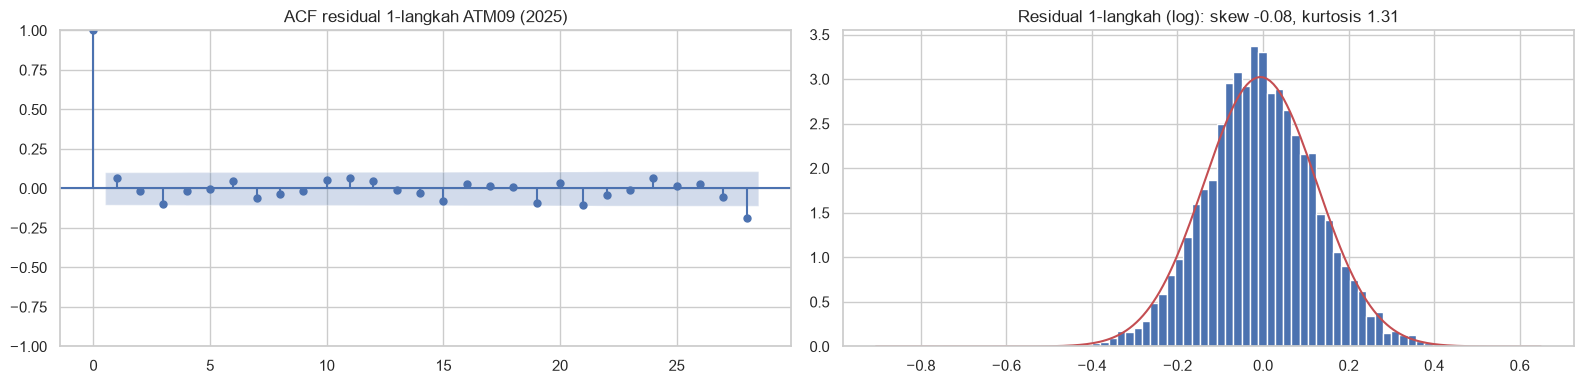

In [23]:
diag_model = SELECT_FACTORIES[best_name]().fit(W, end="2024-12-31")
if best_name == "gbr":
    X25, y25 = training_frame(W, ATM_TYPES, start="2025-01-01")
    one_step = X25[["date", "atm_id"]].assign(resid=y25.to_numpy() - diag_model.predict_features(X25[FEATURE_COLUMNS].to_numpy(float)))
else:
    one_step = pd.concat([diag_model.fits_[a].forecast(365).pipe(lambda f: pd.DataFrame({"date": pd.date_range("2025-01-01", periods=365), "atm_id": a,
                         "resid": W.loc["2025", a].to_numpy()[:365] - f})) for a in W.columns])
lb_rows = []
for atm, g in one_step.groupby("atm_id"):
    lb = ljung_box(g.sort_values("date")["resid"], lags=(7, 14))
    lb_rows.append({"atm_id": atm, "location_type": ATM_TYPES[atm], "LB_7": lb["lb_stat"].iloc[0], "p_7": lb["lb_pvalue"].iloc[0],
                    "LB_14": lb["lb_stat"].iloc[1], "p_14": lb["lb_pvalue"].iloc[1], "acf_1": g.sort_values("date")["resid"].autocorr(1)})
lb_table = pd.DataFrame(lb_rows).set_index("atm_id")
lb_table["p_14_holm"] = holm_correction(lb_table["p_14"])
display(lb_table.round(4))
print(f"ATM dengan autokorelasi residual signifikan (lag 14, Holm): {(lb_table['p_14_holm'] < 0.05).sum()} dari {len(lb_table)} | "
      f"median ACF lag-1 residual = {lb_table['acf_1'].median():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
pooled = one_step.sort_values(["atm_id", "date"])
plot_acf(pooled[pooled["atm_id"] == example_atm]["resid"], lags=28, ax=axes[0], title=f"ACF residual 1-langkah {example_atm} (2025)")
axes[1].hist(one_step["resid"], bins=80, density=True, color="#4C72B0")
xs = np.linspace(one_step["resid"].min(), one_step["resid"].max(), 200)
axes[1].plot(xs, stats.norm.pdf(xs, one_step["resid"].mean(), one_step["resid"].std()), "r")
axes[1].set_title(f"Residual 1-langkah (log): skew {stats.skew(one_step['resid']):.2f}, kurtosis {stats.kurtosis(one_step['resid']):.2f}")
plt.tight_layout()
plt.show()

## 13. Simulasi Bisnis: Berapa Uang yang Diisi?

Setiap origin, bank merencanakan pengisian 14 hari ke depan. Untuk setiap kebijakan **isi = kuantil q dari distribusi ramalan** (dibatasi kapasitas kaset), dihitung di backtest 2025:
- **Cash-out**: hari ketika penarikan aktual > uang yang diisi.
- **Biaya menyimpan uang**: seluruh uang di kaset menanggung biaya dana + asuransi/keamanan (asumsi 8%/tahun).
- **Penalti cash-out**: asumsi Rp 2 jt per hari ATM kosong (fee transaksi hilang + reputasi).

Penyederhanaan: pengisian harian sesuai rencana. Di praktik pengisian dilakukan per 2–7 hari dan ada biaya *cash-in-transit* per kunjungan, tetapi logika trade-off-nya sama. **Biaya dan penalti adalah asumsi** dan harus diganti dengan angka internal bank. Karena itu disertakan **analisis sensitivitas** terhadap besarnya penalti.

Kuantil diambil dari residual **2024** (bukan 2025), lalu biayanya dihitung di 2025, sehingga pemilihan kuantil pun tidak bocor. Pembanding: kebijakan manual “**seasonal naive × 1,3**” (isi seperti minggu lalu + buffer 30%).

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Bagian ini menerjemahkan ramalan menjadi **keputusan keuangan**: ***berapa jumlah uang yang sebaiknya diisi ke setiap ATM?***

**Pertimbangannya:**
- **Mengisi lebih banyak** → ATM jarang kosong, tetapi biaya uang menganggur naik (asumsi 8% per tahun).
- **Mengisi lebih sedikit** → hemat biaya, tetapi ATM lebih sering kosong (asumsi penalti Rp 2 jt per hari ATM kosong).

**Hasil simulasi 2025:**
| Kebijakan | Hari ATM kosong | Total biaya |
|---|---|---|
| Manual: "seperti minggu lalu + 30%" | **19%** | Rp 3.062 jt |
| Berbasis ramalan, isi sebesar P98 | 1,7% | Rp 544 jt |
| **Berbasis ramalan, kuantil optimal (P99,5)** | **0,6%** | **Rp 425 jt (−86%)** |

**Kesimpulannya:** karena kerugian akibat ATM kosong jauh lebih besar daripada biaya menyimpan sedikit uang lebih, kebijakan terbaik adalah mengisi **cukup tinggi** agar ATM hampir tidak pernah kosong. Ramalan membuat jumlah pengisian **tepat sasaran per ATM**, bukan sekadar tambahan 30% untuk semua ATM. Penghematannya **64–92%** di semua skenario penalti yang diuji.

> ⚠️ Biaya dan penalti di atas adalah **asumsi**. Ganti dengan angka internal bank, lalu jalankan ulang bagian ini.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Bagian ini menerjemahkan ramalan menjadi **uang**. Pertanyaannya: ***"Berapa banyak uang yang sebaiknya diisi ke setiap ATM?"***

**Timbangannya:**
- Isi **lebih banyak** → ATM jarang kosong, tetapi biaya uang menganggur naik (asumsi 8% per tahun).
- Isi **lebih sedikit** → hemat biaya simpan, tetapi ATM lebih sering kosong (asumsi penalti Rp 2 jt per hari ATM kosong).

**Hasil simulasi di 2025:**

| Kebijakan | ATM kosong | Total biaya |
|---|---|---|
| Manual: "seperti minggu lalu + 30%" | **19%** hari | Rp 3.062 jt |
| Isi sebanyak P98 ramalan | 1,7% hari | Rp 544 jt |
| **Optimal (P99,5)** | **0,6%** hari | **Rp 425 jt (−86%)** |

**Kesimpulannya:** karena ATM kosong jauh lebih mahal daripada menyimpan sedikit uang lebih, kebijakan terbaik adalah mengisi **cukup banyak** sehingga ATM hampir tidak pernah kosong. Ramalan membuat jumlah itu **tepat sasaran**: tidak asal ditambah 30% di semua ATM. Penghematannya **64–92%** pada semua skenario penalti yang dicoba.

> ⚠️ Biaya dan penalti di sini adalah **asumsi**. Ganti dengan angka internal bank, lalu jalankan ulang bagian ini.

> **🔄 Alur data: Simulasi Pengisian Kas**
>
> - **Input:** `best_bt` (ramalan 2025), `INTERVALS`, kapasitas kaset, ramalan naive.
> - **Proses:**
>   1. 5 kebijakan: P50, P90, P95, P98, dan seasonal naive × 1,3 (manual). Isi dibatasi kapasitas.
>   2. Per kebijakan: % hari cash-out, rata-rata isi & sisa, biaya simpan (8%/th atas seluruh isi), penalti, total biaya.
>   3. Kurva biaya kuantil 0,500–0,995 (kuantil dari residual **2024**, biaya dihitung di 2025) → `LOAD_QUANTILE` optimal.
>   4. Sensitivitas: kuantil optimal untuk penalti Rp 0,5 / 1 / 2 / 5 jt dan penghematan dibanding kebijakan manual.
> - **Output:** `sim`, `cost_curve`, `sensitivity`. Manual (naive × 1,3): cash-out **19,1%** hari, biaya Rp 3.062 jt. P98: cash-out 1,7%, Rp 544 jt. Optimal kuantil **0,995**: cash-out 0,6%, Rp 425 jt (**−86%**). Hemat 64–92% di semua skenario penalti (Rp 0,5–5 jt).
> - **Berikutnya:** Interpretasi model.

,cash_out_%,jumlah_cash_out,rata2_isi_juta,rata2_sisa_juta,biaya_simpan_juta,penalti_juta,total_biaya_juta,terkena_batas_kapasitas_%
ramalan P98,1.66,121.0,189.51,51.30,302.39,242.0,544.39,0.36
ramalan P95,4.16,303.0,177.00,39.08,282.43,606.0,888.43,0.14
ramalan P90,9.35,681.0,166.57,29.27,265.78,1362.0,1627.78,0.08
"seasonal naive × 1,3 (manual)",19.08,1389.0,178.07,44.31,284.13,2778.0,3062.13,0.11
ramalan P50,50.32,3663.0,136.55,7.05,217.89,7326.0,7543.89,0.00


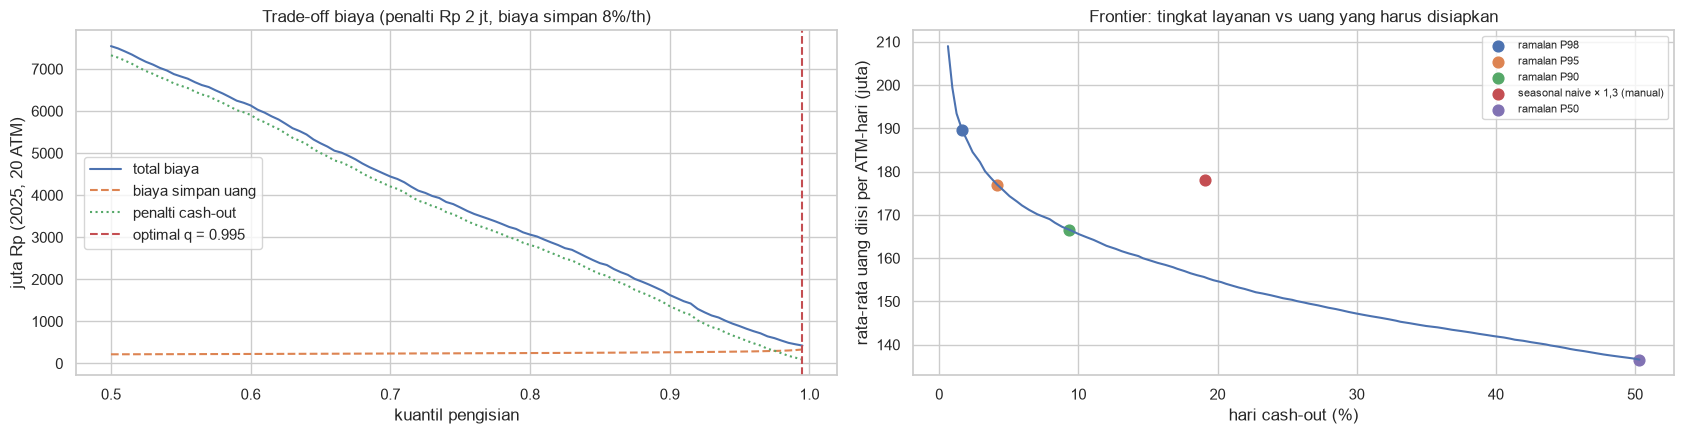

Kuantil optimal = 0.995 → cash-out 0.63% hari, total biaya 425 jt vs manual 3,062 jt
Sensitivitas terhadap penalti cash-out:


,kuantil_optimal,cash_out_%,total_biaya_juta,biaya_manual_juta,hemat_vs_manual_%
penalti_juta,,,,,
0.5,0.990,0.948,352.613,978.633,63.969
1.0,0.995,0.632,379.485,1673.133,77.319
2.0,0.995,0.632,425.485,3062.133,86.105
5.0,0.995,0.632,563.485,7229.133,92.205


In [24]:
sim_base = best_bt[["origin", "atm_id", "date", "h", "y", "yhat_log"]].copy()
sim_base["capacity"] = sim_base["atm_id"].map(CAPACITY)
y_act, cap = sim_base["y"].to_numpy(), sim_base["capacity"].to_numpy()
naive_bt = bt_2025[bt_2025["model"] == "seasonal_naive"].set_index(["origin", "atm_id", "date"])["yhat"]
naive_load = naive_bt.loc[list(zip(sim_base["origin"], sim_base["atm_id"], sim_base["date"]))].to_numpy() * 1.3
resid_by_h = res_2024.groupby("h")["log_resid"]


def evaluate_policy(load_raw, penalty=CASHOUT_PENALTY):
    load = np.minimum(np.asarray(load_raw), cap)
    short = y_act > load
    carry = load.sum() * CARRY_COST / 365
    return {"cash_out_%": short.mean() * 100, "jumlah_cash_out": int(short.sum()), "rata2_isi_juta": load.mean(),
            "rata2_sisa_juta": np.clip(load - y_act, 0, None).mean(), "biaya_simpan_juta": carry,
            "penalti_juta": short.sum() * penalty, "total_biaya_juta": carry + short.sum() * penalty,
            "terkena_batas_kapasitas_%": (np.asarray(load_raw) > cap).mean() * 100}


def quantile_load(q):
    return np.expm1(sim_base["yhat_log"] + resid_by_h.quantile(q).loc[sim_base["h"]].to_numpy())


policies = {f"ramalan P{int(q * 100)}": quantile_load(q) for q in [0.50, 0.90, 0.95, 0.98]}
policies["seasonal naive × 1,3 (manual)"] = naive_load
sim = pd.DataFrame({k: evaluate_policy(v) for k, v in policies.items()}).T.sort_values("total_biaya_juta")
display(sim.round(2))

grid = np.round(np.arange(0.50, 0.9951, 0.005), 3)
loads = {q: quantile_load(q) for q in grid}
cost_curve = pd.DataFrame({q: evaluate_policy(l) for q, l in loads.items()}).T
LOAD_QUANTILE = float(cost_curve["total_biaya_juta"].idxmin())

sens = []
for pen in [0.5, 1.0, 2.0, 5.0]:
    c = pd.Series({q: evaluate_policy(l, pen)["total_biaya_juta"] for q, l in loads.items()})
    q_opt = c.idxmin()
    sens.append({"penalti_juta": pen, "kuantil_optimal": q_opt, "cash_out_%": cost_curve.loc[q_opt, "cash_out_%"],
                 "total_biaya_juta": c.min(), "biaya_manual_juta": evaluate_policy(naive_load, pen)["total_biaya_juta"]})
sensitivity = pd.DataFrame(sens).set_index("penalti_juta")
sensitivity["hemat_vs_manual_%"] = (1 - sensitivity["total_biaya_juta"] / sensitivity["biaya_manual_juta"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
axes[0].plot(cost_curve.index, cost_curve["total_biaya_juta"], "-", label="total biaya")
axes[0].plot(cost_curve.index, cost_curve["biaya_simpan_juta"], "--", label="biaya simpan uang")
axes[0].plot(cost_curve.index, cost_curve["penalti_juta"], ":", label="penalti cash-out")
axes[0].axvline(LOAD_QUANTILE, color="#C44E52", ls="--", label=f"optimal q = {LOAD_QUANTILE:.3f}")
axes[0].set_xlabel("kuantil pengisian")
axes[0].set_ylabel("juta Rp (2025, 20 ATM)")
axes[0].set_title(f"Trade-off biaya (penalti Rp {CASHOUT_PENALTY:g} jt, biaya simpan {CARRY_COST:.0%}/th)")
axes[0].legend()
axes[1].plot(cost_curve["cash_out_%"], cost_curve["rata2_isi_juta"], "-")
for name, row in sim.iterrows():
    axes[1].scatter(row["cash_out_%"], row["rata2_isi_juta"], s=60, label=name)
axes[1].set_xlabel("hari cash-out (%)")
axes[1].set_ylabel("rata-rata uang diisi per ATM-hari (juta)")
axes[1].set_title("Frontier: tingkat layanan vs uang yang harus disiapkan")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Kuantil optimal = {LOAD_QUANTILE:.3f} → cash-out {cost_curve.loc[LOAD_QUANTILE, 'cash_out_%']:.2f}% hari, "
      f"total biaya {cost_curve.loc[LOAD_QUANTILE, 'total_biaya_juta']:,.0f} jt vs manual {sim.loc['seasonal naive × 1,3 (manual)', 'total_biaya_juta']:,.0f} jt")
print("Sensitivitas terhadap penalti cash-out:")
display(sensitivity.round(3))

## 14. Interpretasi Model

**Permutation importance per kelompok fitur**: semua kolom dalam satu kelompok (mis. seluruh one-hot fase Lebaran) diacak bersamaan, lalu dilihat kenaikan error ramalan 1 langkah di 2025. Cara ini lebih jujur daripada importance per kolom one-hot.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Bagian ini menjawab: ***informasi apa yang paling diandalkan model?*** Setiap kelompok informasi **diacak**, lalu dilihat seberapa besar kesalahan ramalan bertambah.

| Informasi yang diacak | Kenaikan kesalahan |
|---|---|
| **Penarikan hari-hari sebelumnya** | **+428%** (paling penting) |
| Periode gajian | +27% |
| Hari dalam seminggu | +21% |
| Fase Lebaran | +13% |
| Hari libur | +11% |
| Tipe lokasi | +10% |
| Bulan | +0,4% (hampir tidak terpakai) |

**Cara membaca grafik:** batang yang **lebih panjang** berarti informasi yang **lebih penting**.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

***"Model meramal berdasarkan apa?"*** Setiap kelompok petunjuk **diacak** (dirusak), lalu dilihat seberapa besar kesalahan model bertambah:
- **Penarikan hari-hari terakhir:** kesalahan naik **+428%** jika diacak. Ini petunjuk paling penting.
- **Periode gajian** +27%, **hari** +21%, **fase Lebaran** +13%, **libur** +11%, **tipe lokasi** +10%.
- **Bulan:** hampir tidak berguna (+0,4%), karena informasinya sudah tercakup oleh petunjuk lain.

**Cara membaca grafik:** batang yang **lebih panjang** = petunjuk yang **lebih penting**.

> **🔄 Alur data: Permutation Importance per Kelompok**
>
> - **Input:** Fitur 2025 (lag aktual), `diag_model`.
> - **Proses:**
>   1. 7 kelompok fitur diacak bersamaan (5 ulangan) → kenaikan MAE log.
> - **Output:** `group_imp`. Kenaikan MAE saat diacak: lag & rolling **+428%**, jendela gajian +27%, hari +21%, fase Lebaran +13%, libur & musim +11%, tipe lokasi +10%, bulan +0,4% (hampir tidak berguna setelah ada fitur lain).
> - **Berikutnya:** Rangkum semua bukti.

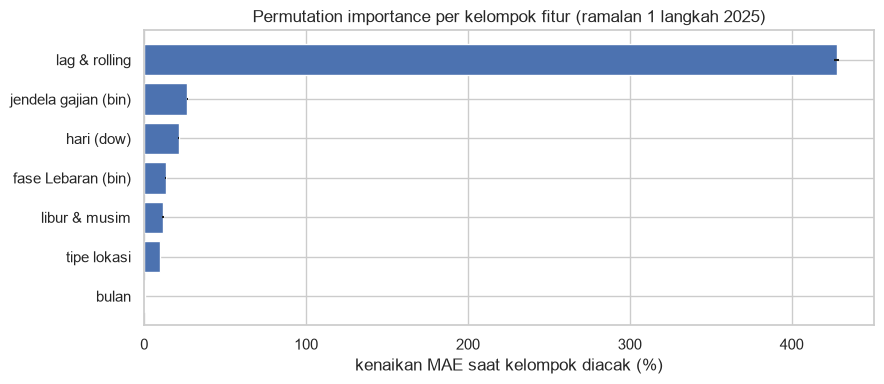

,n_kolom,kenaikan_MAE_log_%,std
kelompok,,,
lag & rolling,11,427.79,1.61
jendela gajian (bin),5,26.74,0.34
hari (dow),7,21.25,0.41
fase Lebaran (bin),7,13.31,0.32
libur & musim,5,11.47,0.70
tipe lokasi,6,9.84,0.23
bulan,12,0.40,0.07


In [25]:
if best_name == "gbr":
    X25m = X25[FEATURE_COLUMNS].to_numpy(float)
    base_err = np.abs(y25.to_numpy() - diag_model.predict_features(X25m)).mean()
    groups = {
        "lag & rolling": LAG_COLS,
        "hari (dow)": [c for c in FEATURE_COLUMNS if c.startswith("dow_")],
        "fase Lebaran (bin)": [c for c in FEATURE_COLUMNS if c.startswith("lebaran_bin_")],
        "jendela gajian (bin)": [c for c in FEATURE_COLUMNS if c.startswith("dom_bin_")],
        "bulan": [c for c in FEATURE_COLUMNS if c.startswith("month_")],
        "libur & musim": ["is_holiday", "is_pre_holiday", "is_post_holiday", "is_december_peak", "is_semester_break"],
        "tipe lokasi": [c for c in FEATURE_COLUMNS if c.startswith("location_type_")],
    }
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for gname, cols in groups.items():
        idx = [FEATURE_COLUMNS.index(c) for c in cols]
        incs = []
        for _ in range(5):
            Xp = X25m.copy()
            Xp[:, idx] = Xp[rng.permutation(len(Xp))][:, idx]
            incs.append(np.abs(y25.to_numpy() - diag_model.predict_features(Xp)).mean() / base_err - 1)
        rows.append({"kelompok": gname, "n_kolom": len(cols), "kenaikan_MAE_log_%": np.mean(incs) * 100, "std": np.std(incs) * 100})
    group_imp = pd.DataFrame(rows).set_index("kelompok").sort_values("kenaikan_MAE_log_%", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(group_imp.index, group_imp["kenaikan_MAE_log_%"], xerr=group_imp["std"], color="#4C72B0")
    ax.invert_yaxis()
    ax.set_xlabel("kenaikan MAE saat kelompok diacak (%)")
    ax.set_title("Permutation importance per kelompok fitur (ramalan 1 langkah 2025)")
    plt.tight_layout()
    plt.show()
    display(group_imp.round(2))
else:
    group_imp = pd.DataFrame()
    print("Model terpilih ETS: komponen = level, tren teredam, musiman 7 hari (lihat parameter di model.json)")

## 15. Ringkasan Evaluasi Statistik & Kesimpulan

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Rangkuman seluruh pengujian:**
- ✅ **10** lolos
- ⚠️ **3** catatan
- ❌ **0** gagal

**Tiga catatan (tidak menghalangi pemakaian):**
1. **Rentang ramalan sedikit terlalu lebar**: aman untuk kas, dan cukup dikalibrasi ulang setiap tahun.
2. **Kesalahan masih sedikit berpola** di 5 ATM: menjadi bahan pengembangan berikutnya.
3. **Kuantil pengisian optimal sangat tinggi** (P99,5): di lapangan, batasnya ditentukan oleh kapasitas kaset dan jadwal pengisian.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Rapor akhir:** semua pemeriksaan dirangkum dengan tanda ✅/⚠️/❌. Hasilnya **10 lolos, 3 catatan, 0 gagal**.

**Tiga catatan ⚠️ (tidak menghalangi pemakaian):**
1. **Rentang ramalan sedikit terlalu lebar.** Ini aman untuk kas, dan cukup disetel ulang setiap tahun.
2. **Masih ada sedikit pola** di kesalahan ramalan pada 5 ATM. Ini bahan perbaikan berikutnya.
3. **Jumlah isi optimal sangat tinggi** (P99,5). Di lapangan, batasnya ditentukan kapasitas kaset dan jadwal kunjungan mobil pengisi uang, bukan oleh rumus.

**Rekomendasi:** pakai rekomendasi isi dari API, kirim data penarikan harian agar ramalan selalu segar, latih ulang setiap bulan, dan **perbarui kalender setiap tahun** (tanggal Lebaran, libur, cuti bersama).

> **🔄 Alur data: Ringkasan Evaluasi**
>
> - **Input:** Hasil Bagian 4–14.
> - **Proses:**
>   1. 15 pengujian vs patokan → ✅/⚠️/❌/ℹ️ (`evaluation_summary`), dan angka kunci → `EVALUATION_FOR_METADATA`.
> - **Output:** `evaluation_summary` (15 baris): **10 ✅, 3 ⚠️** (cakupan 2 interval, autokorelasi residual), 2 ℹ️, 0 ❌.
> - **Berikutnya:** Model produksi.

In [26]:
def verdict(ok: bool, warn: bool = False) -> str:
    return "✅" if ok else ("⚠️" if warn else "❌")


bm = test_metrics.loc[MODEL_LABELS[best_name]]
t_other = test_tests.iloc[0]
t_naive = test_tests.iloc[1]
c80, c90 = coverage.loc["Q10–Q90"], coverage.loc["Q05–Q95"]
n_seg_bias = int((seg_all["status"] == "bias material (>2%)").sum())
n_seg_small = int((seg_all["status"] == "signifikan tapi kecil (≤2%)").sum())
n_lb = int((lb_table["p_14_holm"] < 0.05).sum())
rows = [
    ("Data", "ATM dengan tren turun signifikan", f"{((ts_tests['tren_p_holm'] < 0.05) & (ts_tests['tren_per_tahun'] < 0)).sum()} dari 20 (median {ts_tests['tren_per_tahun'].median():+.1%}/th)", "informasi", "ℹ️"),
    ("Data", "Efek gajian & pra-Lebaran signifikan", f"{(cal_tests['gajian_p_holm'] < 0.05).sum()}/6 & {(cal_tests['lebaran_p_holm'] < 0.05).sum()}/6 tipe lokasi", "informasi", "ℹ️"),
    ("Validasi", "Kebocoran fitur", "tidak ada (uji otomatis)", "lulus", verdict(True)),
    ("Pemilihan (2024)", f"{MODEL_LABELS[best_name]} vs {MODEL_LABELS[other_name]}", f"WAPE {sel.loc[MODEL_LABELS[best_name], 'wape']:.2%} vs {sel.loc[MODEL_LABELS[other_name], 'wape']:.2%}; DM p = {sel_tests.iloc[0]['DM_p']:.2g}", "p < 0,05", verdict(sel_tests.iloc[0]["DM_p"] < 0.05, True)),
    ("Uji akhir 2025", "WAPE", f"{final_ci.loc['wape', 'estimate']:.2%} (CI {final_ci.loc['wape', 'ci_lower']:.2%}–{final_ci.loc['wape', 'ci_upper']:.2%})", "≤ 15%", verdict(final_ci.loc["wape", "ci_upper"] <= 0.15, final_ci.loc["wape", "estimate"] <= 0.15)),
    ("Uji akhir 2025", "MASE", f"{bm['mase']:.3f}", "< 1 (lebih baik dari naive)", verdict(bm["mase"] < 1)),
    ("Uji akhir 2025", "Bias", f"{final_ci.loc['bias', 'estimate']:+.2%} (CI {final_ci.loc['bias', 'ci_lower']:+.2%}…{final_ci.loc['bias', 'ci_upper']:+.2%})", "|bias| < 3%", verdict(abs(final_ci.loc["bias", "estimate"]) < 0.03)),
    ("Uji akhir 2025", f"vs {MODEL_LABELS[other_name]} (Diebold-Mariano)", f"DM = {t_other['DM_HLN']:.2f}, p = {t_other['DM_p']:.2g}", "p < 0,05", verdict(t_other["DM_p"] < 0.05, True)),
    ("Uji akhir 2025", "vs seasonal naive (Diebold-Mariano)", f"DM = {t_naive['DM_HLN']:.2f}, p = {t_naive['DM_p']:.2g}; FVA {fva.iloc[0]:.0%}", "p < 0,05", verdict(t_naive["DM_p"] < 0.05)),
    ("Uji akhir 2025", "Stabilitas antar origin", f"WAPE {ow.min():.1%}–{ow.max():.1%}, tren p = {p_trend:.2f}", "tanpa tren memburuk", verdict(not (rho > 0 and p_trend < 0.05))),
    ("Interval", "Cakupan P10–P90 (target 80%)", f"{c80['coverage']:.1%} (p = {c80['p_value']:.3f})", "≈ 80% (± 3 poin)", verdict(c80["p_value"] > 0.05, abs(c80["coverage"] - 0.8) <= 0.03)),
    ("Interval", "Cakupan P05–P95 (target 90%)", f"{c90['coverage']:.1%} (p = {c90['p_value']:.3f})", "≈ 90% (± 3 poin)", verdict(c90["p_value"] > 0.05, abs(c90["coverage"] - 0.9) <= 0.03)),
    ("Residual", "Autokorelasi residual (Ljung-Box lag 14, Holm)", f"{n_lb} dari 20 ATM; median ACF lag-1 {lb_table['acf_1'].median():.2f}", "0 ATM, atau ACF kecil (< 0,2)",
     verdict(n_lb == 0, lb_table["acf_1"].median() < 0.2)),
    ("Residual", "Segmen dengan bias material (>2%, signifikan)", f"{n_seg_bias} dari {len(seg_all)} (+{n_seg_small} signifikan tapi ≤2%)", "0", verdict(n_seg_bias == 0, n_seg_bias <= 2)),
    ("Bisnis", f"Pengisian kuantil {LOAD_QUANTILE:.3f} vs manual (naive × 1,3)",
     f"biaya {cost_curve.loc[LOAD_QUANTILE, 'total_biaya_juta']:,.0f} vs {sim.loc['seasonal naive × 1,3 (manual)', 'total_biaya_juta']:,.0f} jt; cash-out {cost_curve.loc[LOAD_QUANTILE, 'cash_out_%']:.1f}% vs {sim.loc['seasonal naive × 1,3 (manual)', 'cash_out_%']:.1f}%",
     "lebih murah di semua skenario penalti", verdict((sensitivity["hemat_vs_manual_%"] > 0).all())),
]
evaluation_summary = pd.DataFrame(rows, columns=["aspek", "pengujian", "nilai", "patokan", "status"])
pd.set_option("display.max_colwidth", 130)
display(evaluation_summary.set_index(["aspek", "pengujian"]))
print("Rekap status:", evaluation_summary["status"].value_counts().to_dict())

EVALUATION_FOR_METADATA = {
    "selection_2024": {MODEL_LABELS[m]: float(v) for m, v in metrics_by(bt_2024, "model")["wape"].items()},
    "test_2025": {k: {"estimate": float(final_ci.loc[k, "estimate"]), "ci95": [float(final_ci.loc[k, "ci_lower"]), float(final_ci.loc[k, "ci_upper"])]}
                  for k in ["wape", "bias", "mase", "mae", "rmse"]},
    "test_2025_all_models_wape": {k: float(v) for k, v in test_metrics["wape"].items()},
    "diebold_mariano_p": {"vs_" + other_name: float(t_other["DM_p"]), "vs_seasonal_naive": float(t_naive["DM_p"])},
    "interval_coverage_2025": {"p10_p90": float(c80["coverage"]), "p05_p95": float(c90["coverage"])},
    "ljung_box_significant_atms": n_lb,
    "load_quantile": LOAD_QUANTILE,
    "cost_assumptions": {"carry_cost_per_year": CARRY_COST, "cashout_penalty_juta": CASHOUT_PENALTY},
    "load_quantile_sensitivity": {str(k): float(v) for k, v in sensitivity["kuantil_optimal"].items()},
}

nilai                                patokan status
aspek            pengujian                                                                                                                                   
Data             ATM dengan tren turun signifikan                                  12 dari 20 (median -3.4%/th)                              informasi     ℹ️
                 Efek gajian & pra-Lebaran signifikan                                     6/6 & 6/6 tipe lokasi                              informasi     ℹ️
Validasi         Kebocoran fitur                                                       tidak ada (uji otomatis)                                  lulus      ✅
Pemilihan (2024) Gradient Boosting vs Holt-Winters (ETS)                  WAPE 12.26% vs 21.85%; DM p = 1.5e-07                               p < 0,05      ✅
Uji akhir 2025   WAPE                                                                 11.57% (CI 11.27%–11.85%)                                  ≤ 15%      ✅
                 MASE                                                                                     0.528            < 1 (lebih baik dari naive)      ✅
                 Bias                                                                 -0.15% (CI -0.78%…+0.56%)                            |bias| < 3%      ✅
                 vs Holt-Winters (ETS) (Diebold-Mariano)                                DM = -8.65, p = 1.6e-16                               p < 0,05      ✅
                 vs seasonal naive (Diebold-Mariano)                          DM = -12.86, p = 1.9e-31; FVA 48%                               p < 0,05      ✅
                 Stabilitas antar origin                                         WAPE 9.9%–14.7%, tren p = 0.12                    tanpa tren memburuk      ✅
Interval         Cakupan P10–P90 (target 80%)                                                 82.0% (p = 0.000)                       ≈ 80% (± 3 poin)     ⚠️
                 Cakupan P05–P95 (target 90%)                                                 92.2% (p = 0.000)                       ≈ 90% (± 3 poin)     ⚠️
Residual         Autokorelasi residual (Ljung-Box lag 14, Holm)            5 dari 20 ATM; median ACF lag-1 0.10          0 ATM, atau ACF kecil (< 0,2)     ⚠️
                 Segmen dengan bias material (>2%, signifikan)               0 dari 25 (+4 signifikan tapi ≤2%)                                      0      ✅
Bisnis           Pengisian kuantil 0.995 vs manual (naive × 1,3)  biaya 425 vs 3,062 jt; cash-out 0.6% vs 19.1%  lebih murah di semua skenario penalti      ✅

Rekap status: {'✅': 10, '⚠️': 3, 'ℹ️': 2}


### Kesimpulan Akhir

**Hasil: 10 ✅ · 3 ⚠️ · 0 ❌** (+2 baris informasi ℹ️)

**1. Gradient Boosting global layak dipakai untuk perencanaan kas ATM**

| Aspek | Bukti utama |
|---|---|
| **Akurasi** | WAPE 11,6% (CI 11,3–11,9%), MASE 0,53; error 48% lebih kecil dari naive dan 42% lebih kecil dari Holt-Winters |
| **Signifikansi** | Diebold-Mariano p < 10⁻¹⁵ (vs ETS) dan p < 10⁻³⁰ (vs naive), konsisten di tahun pemilihan (2024) dan uji akhir (2025) |
| **Tidak bias** | −0,15%, dan tidak ada segmen dengan bias material |
| **Stabil** | WAPE 9,9–14,7% di 26 origin, tanpa tren memburuk |
| **Saat kritis (Lebaran)** | WAPE 12–22% vs ETS 29–52% |
| **Nilai bisnis** | Pengisian kas berbasis ramalan menghemat **64–92%** biaya vs kebijakan manual, di **semua** skenario penalti |

**2. Tiga catatan ⚠️**
- **Interval sedikit konservatif** (cakupan 82% & 92%, target 80% & 90%). Ini aman untuk kas, tetapi perlu dikalibrasi ulang tahunan.
- **Autokorelasi residual** pada 5 dari 20 ATM (Ljung-Box). Besarnya kecil (median ACF lag-1 = 0,10), tetapi menunjukkan masih ada sedikit informasi waktu yang belum terpakai, misalnya kejutan (*shock*) beberapa hari terakhir. Pengembangan: tambah fitur residual/selisih lag, atau model *direct* per horizon.
- **Kuantil pengisian optimal mentok di 0,995** (batas atas yang masih bisa diestimasi andal dari 7.280 residual). Karena penalti ATM kosong jauh lebih mahal daripada biaya menyimpan uang, kebijakan optimal adalah **tingkat layanan sangat tinggi (±99–99,5%)**. Ini sejalan dengan target ketersediaan ATM di industri. Di praktik, batasnya ditentukan kapasitas kaset dan frekuensi kunjungan CIT, bukan rumus.

**3. Rekomendasi operasional**
1. Pakai **rekomendasi isi** dari API (kuantil optimal, dibatasi kapasitas). Untuk ATM yang sering mentok kapasitas, tambah frekuensi pengisian.
2. Kirim data aktual **harian** lewat `recent_actuals`, supaya lag selalu terbaru tanpa perlu retrain.
3. **Refit bulanan**, dan **rekalibrasi interval tahunan** dengan backtest rolling-origin seperti notebook ini.
4. **Perbarui kalender** (`src/calendar_id.py`) setiap tahun: tanggal Lebaran, Idul Adha, Imlek, dan cuti bersama. API memberi peringatan jika ramalan melewati batas kalender.
5. Ganti asumsi biaya (biaya simpan 8%/tahun, penalti Rp 2 jt) dengan angka internal bank, lalu jalankan ulang Bagian 13.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Kesimpulan:** model Gradient Boosting **layak dipakai** untuk perencanaan kas ATM. Ramalannya akurat, tidak bias, unggul saat Lebaran, dan **menghemat biaya secara signifikan**.

**Langkah selanjutnya:**
1. Gunakan **rekomendasi pengisian** dari API.
2. **Kirim data penarikan harian** ke API agar ramalan selalu memakai data terbaru.
3. **Latih ulang setiap bulan**, dan **kalibrasi ulang rentang** setiap tahun.
4. **Perbarui kalender setiap tahun** (Lebaran, libur nasional, cuti bersama), karena model tidak dapat mengetahui tanggal Lebaran tahun depan dengan sendirinya.
5. Ganti asumsi biaya dengan **angka internal bank**.
6. **Validasi dengan data riil.** Data proyek ini simulasi.

## 16. Model Produksi: Refit Semua Data, Export JSON & Ramalan Januari 2026

Konfigurasi terpilih dilatih ulang dengan **seluruh data s.d. 31 Des 2025**. Interval tetap memakai kuantil residual dari backtest 2024, yang sudah terbukti di 2025. Kuantil pengisian optimal dari Bagian 13 disimpan di metadata.

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

Untuk pemakaian sehari-hari, model **dilatih ulang dengan seluruh data sampai Desember 2025**, lalu disimpan ke **file JSON** yang berisi daftar fitur, ratusan pohon keputusan, dan lebar rentang ramalan.

Bagian ini juga menampilkan **contoh ramalan Januari 2026**. Perhatikan lonjakan di akhir bulan (gajian) dan pola di sekitar tahun baru.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

Untuk dipakai sehari-hari, model **dilatih ulang dengan semua data sampai Desember 2025**, lalu disimpan ke file **JSON**, yaitu file teks berisi "resep" lengkap: daftar petunjuk, ratusan pohon keputusan, dan lebar rentang ramalan.

Bagian ini juga menampilkan **ramalan Januari 2026** sebagai contoh pemakaian. Perhatikan pola gajian di akhir bulan dan libur tahun baru.

> **🔄 Alur data: Refit, Export JSON & Ramalan Jan 2026**
>
> - **Input:** Seluruh `W` (2022–2025).
> - **Proses:**
>   1. `final_model` dilatih di semua data; metadata (profil ATM, kuantil pengisian per horizon, evaluasi, batas validitas kalender).
>   2. `export_model`: pohon GBR (atau state ETS) + riwayat 35 hari terakhir + `INTERVALS` → `model.json`.
>   3. Ramalan 28 hari (1–28 Jan 2026) total 20 ATM.
> - **Output:** `final_model` (data s.d. 31 Des 2025), file **`models/model.json` (±1,4 MB)**, origin 31 Des 2025; grafik ramalan 1–28 Jan 2026.
> - **Berikutnya:** Validasi JSON.

Model JSON -> /Users/ikhsannur1996/Documents/data-science/forecasting/models/model.json (1417 KB), tipe gbr, origin 2025-12-31


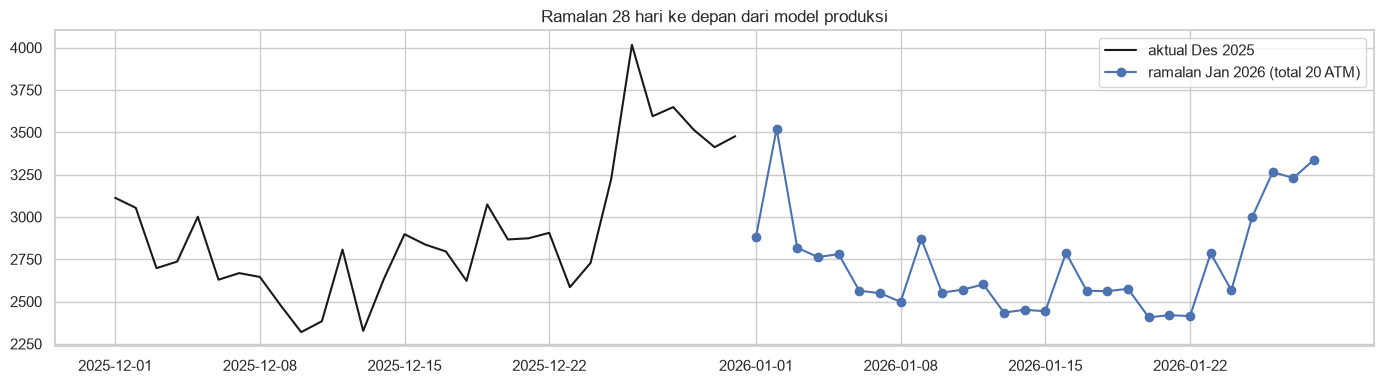

In [27]:
final_model = SELECT_FACTORIES[best_name]().fit(W)
now = datetime.now(timezone.utc)
metadata = {
    "model_name": best_name,
    "model_label": MODEL_LABELS[best_name],
    "model_version": now.strftime("%Y%m%d%H%M%S"),
    "trained_at": now.isoformat(timespec="seconds"),
    "training_period": f"{W.index.min().date()} – {W.index.max().date()}",
    "target": "log1p(penarikan harian), juta Rupiah",
    "validated_horizon_days": HORIZON,
    "max_horizon_days": 28,
    "calendar_valid_until": CALENDAR_VALID_UNTIL.strftime("%Y-%m-%d"),
    "params": GBR_GRID[BEST_GBR] if best_name == "gbr" else ETS_GRID[BEST_ETS],
    "atms": master.to_dict("records"),
    "load_quantile": LOAD_QUANTILE,
    "load_quantile_by_h": {int(h): float(v) for h, v in res_2024.groupby("h")["log_resid"].quantile(LOAD_QUANTILE).items()},
    "evaluation": EVALUATION_FOR_METADATA,
    "library_versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
model_json = export_model(final_model, W, metadata, INTERVALS)
model_path = MODEL_DIR / "model.json"
save_json(model_json, model_path)
print(f"Model JSON -> {model_path} ({model_path.stat().st_size / 1024:.0f} KB), tipe {model_json['model']['type']}, origin {model_json['origin']}")

jan = final_model.forecast(W, W.index.max(), 28)
jan_total = np.expm1(jan.pivot(index="date", columns="atm_id", values="yhat_log")).sum(axis=1)
last = np.expm1(W.loc["2025-12-01":]).sum(axis=1)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last.index, last, "k-", label="aktual Des 2025")
ax.plot(jan_total.index, jan_total, "o-", color="#4C72B0", label="ramalan Jan 2026 (total 20 ATM)")
ax.set_title("Ramalan 28 hari ke depan dari model produksi")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Validasi Model JSON & Contoh Request API

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**Pemeriksaan konsistensi:** model dari file JSON menghasilkan ramalan yang **identik** dengan model aslinya ✅.

**Contoh permintaan ke API:** sistem mengirim daftar ATM, jumlah hari yang ingin diramal (biasanya 14; sudah diuji sampai 14 hari), dan opsional data penarikan terbaru. **Jawaban API** berisi ramalan harian, rentang ramalan, dan **rekomendasi jumlah pengisian** yang sudah disesuaikan dengan kapasitas kaset.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**Pemeriksaan keamanan:** apakah file JSON menghasilkan ramalan yang **persis sama** dengan model aslinya? Hasilnya identik.

**Contoh permintaan ke API:** kirim daftar ID ATM, jumlah hari yang ingin diramal (biasanya 14; sudah diuji sampai 14 hari), dan (opsional) data penarikan terbaru. API menjawab dengan ramalan harian, rentang ramalan, dan **rekomendasi jumlah uang yang perlu diisi** (sudah dibatasi kapasitas kaset).

> **🔄 Alur data: Validasi JSON & Contoh Request**
>
> - **Input:** `model.json`, `final_model`, `W`.
> - **Proses:**
>   1. Ramalan 28 hari JSON vs model asli.
>   2. Simulasi data baru: 5 hari ramalan dianggap aktual → `recent_actuals` → ramalan 14 hari dari origin baru, dibandingkan dengan model asli.
>   3. Tulis `sample_request.json` & `sample_request_with_actuals.json`.
> - **Output:** Selisih maks JSON vs model asli **1,6×10⁻¹⁴**, baik untuk ramalan biasa maupun setelah update 5 hari data baru → identik. File contoh request ditulis.
> - **Berikutnya:** File contoh dipakai untuk API & unit test.

In [28]:
json_model = JsonForecaster.load(model_path)
a = final_model.forecast(W, W.index.max(), 28).sort_values(["atm_id", "h"])
b = json_model.forecast(28).sort_values(["atm_id", "h"])
diff = np.abs(a["yhat_log"].to_numpy() - b["yhat_log"].to_numpy()).max()
print(f"Selisih maks ramalan 28 hari (JSON vs {MODEL_LABELS[best_name]} asli): {diff:.2e}")
assert diff < 1e-8
if best_name == "gbr":
    # simulasi data baru: anggap 5 hari pertama ramalan adalah aktual, lalu ramal lagi dari origin baru
    W_ext = pd.concat([W, np.log1p(np.expm1(a.pivot(index="date", columns="atm_id", values="yhat_log")).iloc[:5])])
    recent = {atm: {d.strftime("%Y-%m-%d"): float(np.expm1(W_ext.loc[d, atm])) for d in W_ext.index[-5:]} for atm in W.columns}
    c = json_model.forecast(14, recent_actuals=recent).sort_values(["atm_id", "h"])
    d_ = final_model.forecast(W_ext, W_ext.index.max(), 14).sort_values(["atm_id", "h"])
    diff2 = np.abs(c["yhat_log"].to_numpy() - d_["yhat_log"].to_numpy()).max()
    print(f"Selisih maks setelah update 5 hari data baru: {diff2:.2e}")
    assert diff2 < 1e-8
print("✅ Model JSON identik dengan model asli")

sample = {"atm_ids": [example_atm, "ATM01"], "horizon": 14}
(PROJECT_DIR / "sample_request.json").write_text(json.dumps(sample, indent=2))
if best_name == "gbr":
    recent_one = {atm: dict(list(v.items())[:3]) for atm, v in recent.items()}
    (PROJECT_DIR / "sample_request_with_actuals.json").write_text(json.dumps({"horizon": 7, "recent_actuals": recent_one}, indent=2))
b[b["atm_id"] == example_atm].head(7).set_index("date").drop(columns="atm_id").round(2)

Selisih maks ramalan 28 hari (JSON vs Gradient Boosting asli): 1.60e-14


Selisih maks setelah update 5 hari data baru: 1.60e-14
✅ Model JSON identik dengan model asli


,h,yhat_log,forecast,q05,q10,q50,q90,q95
date,,,,,,,,
2026-01-01,1,4.95,139.53,110.22,116.71,136.13,165.82,175.43
2026-01-02,2,5.07,158.54,124.09,129.99,156.31,188.15,196.19
2026-01-03,3,4.95,140.29,105.25,113.66,138.57,170.26,180.06
2026-01-04,4,4.86,128.47,97.38,103.84,128.20,155.19,166.39
2026-01-05,5,4.85,126.57,95.82,101.01,127.61,154.22,163.81
2026-01-06,6,4.81,122.34,92.22,99.98,120.69,149.25,161.07
2026-01-07,7,4.77,116.82,89.47,95.36,115.39,140.38,148.70


## 18. Alur Data di API

```
POST /forecast  {atm_ids?, horizon (1–28, default 14), recent_actuals?}
   │ 1. Pydantic: ATM dikenal, horizon 1–28, recent_actuals berurutan mulai origin+1 untuk SEMUA ATM
   ▼
   │ 2. riwayat 35 hari di model.json (+ recent_actuals jika ada) → wide log1p
   │ 3. rekursif h = 1..horizon: build_features (lag, rolling, binning kalender → one-hot) → pohon GBR
   │    (atau rumus Holt-Winters jika model ETS) → log-ramalan
   │ 4. interval: ramalan × exp(kuantil residual per horizon)
   │ 5. rekomendasi isi = ramalan × exp(kuantil optimal per horizon), dibatasi kapasitas kaset
   ▼
Response per ATM: tanggal, ramalan, P10/P90, P05/P95, rekomendasi isi, penanda kalender,
                  total 14 hari, peringatan (horizon > 14, kalender, kapasitas)
```

**Siklus berikutnya:** setiap hari kirim data aktual terbaru lewat `recent_actuals` (atau refit model). Lakukan **refit bulanan** agar tren dan pola terbaru terserap, dan perbarui `src/calendar_id.py` setiap tahun (tanggal Lebaran, Idul Adha, Imlek, cuti bersama).

<!-- penjelasan-sederhana -->
#### 💡 Penjelasan sederhana

**API** adalah layanan yang dapat dipanggil sistem pengelolaan kas untuk mendapatkan ramalan dan rekomendasi pengisian setiap ATM.

**Docker** membungkus aplikasi beserta semua kebutuhannya, sehingga dapat dijalankan dengan cara yang sama di mana pun. Panduan teknisnya ada di **README**.

<!-- penjelasan-sederhana -->
#### 📘 Penjelasan lebih lengkap

**API** adalah "loket layanan": sistem pengelolaan kas mengirim permintaan dan langsung menerima ramalan serta rekomendasi pengisian untuk setiap ATM. **Docker** membungkus aplikasi agar bisa dijalankan dengan cara yang sama di mana saja. Petunjuk teknisnya ada di README.